In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import os
import json
import utils.saveload as sl
import models.snov.run_gabor_knov_complex as gknovc
import fitting_neural.grid_search_snov as gsc
import fitting_neural.simulate_data as sd
import models.snov.gabor_stimuli as gs
import fitting_neural.load_homann_data as load_homann
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

In [2]:
# Define the variations of component functions to be investigated
def k_triangle(x,loc,scale): 
    return 1/scale*(1-np.abs(x-loc)/scale)*np.heaviside(1-np.abs(x-loc)/scale,0)

def k_triangle2(x,loc,scale):  # here: loc is the maximum value, scale is the steepness of the triangle
    return scale*x*np.heaviside(x,0)*np.heaviside(loc/scale-x,1) + loc*np.heaviside(x-loc/scale,0)

def k_triangle3(x,loc,scale):  # here: loc is the maximum value, scale is the steepness of the triangle
    return (1-np.abs(x-loc)/scale)*np.heaviside(1-np.abs(x-loc)/scale,0)

In [3]:
def k_box(x,loc,scale): 
    return 1/(2*scale)*(np.heaviside(scale+loc-x,1)-np.heaviside(loc-scale-x,1))

def k_box2(x,loc,scale): 
    return 1/2*(np.heaviside(scale+loc-x,1)-np.heaviside(loc-scale-x,1))

In [4]:
def k_tanh1(s, scale, loc):
    return 0.5*(np.tanh(5/scale*(s-loc))+1)*np.heaviside(s-(loc-scale),0)

def k_tanh(s, scale, loc=1):
    # scale gives the range across which the function goes from 0 to 1 / loc is the center of the function (where it is 1). We translate this to the actual scaling factor in the tanh (scale = scaling factor) and the actual shift of the tanh (shift = loc-scale/2) i.e. where it is 0.5
    scale_tanh = scale
    loc_tanh = loc - scale/2  
    return 0.5*(np.tanh(5/scale_tanh*(s-loc_tanh))+1)*np.heaviside(s-(loc_tanh-scale_tanh),0)

In [5]:
def k_id(s, scale, loc):
    return s

Goal: Check the model behavior of flr for 

(i) component shape, varying between triangle and box (fixed width, where width= 1-min. sim. for which component is non-zero)

(ii) component width (triangle)

(iii) component width (box) 

### Different widths (triangle)

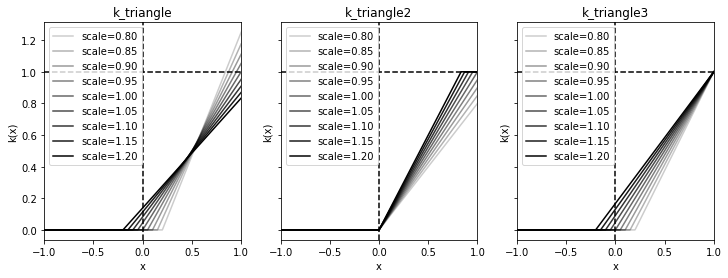

In [9]:
x = np.linspace(-1,1,1000)

loc = 1
scale = np.arange(0.8,1.25,0.05)
alphas = np.linspace(0.2,1,len(scale))

f, ax = plt.subplots(1,3,figsize=(12,4),sharey=True)
for i in range(len(scale)):
    ax[0].plot(x,k_triangle(x,loc,scale[i]),alpha=alphas[i],c='k',label=f'scale={scale[i]:.2f}')
    ax[1].plot(x,k_triangle2(x,loc,scale[i]),alpha=alphas[i],c='k',label=f'scale={scale[i]:.2f}')
    ax[2].plot(x,k_triangle3(x,loc,scale[i]),alpha=alphas[i],c='k',label=f'scale={scale[i]:.2f}')

ax[0].set_title('k_triangle')
ax[1].set_title('k_triangle2')
ax[2].set_title('k_triangle3')
ax[0].legend()
ax[1].legend()
ax[2].legend()

for i in range(len(ax)):
    ax[i].axvline(0, color='k', linestyle='--')
    ax[i].axhline(1, color='k', linestyle='--')
    ax[i].set_xlim(-1,1)
    ax[i].set_xlabel('x')
    ax[i].set_ylabel('k(x)')

### Different widths (box)

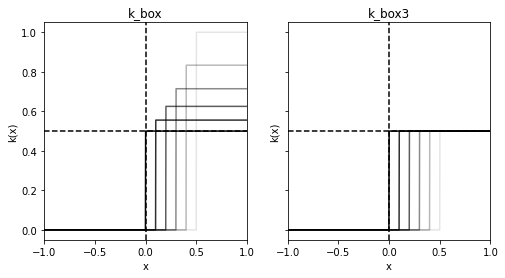

In [5]:
x = np.linspace(-1,1,1000)

loc = 1
scale = np.arange(0.5,1.01,0.1)
alphas = np.linspace(0.1,1,len(scale))

f, ax = plt.subplots(1,2,figsize=(8,4),sharey=True)
for i in range(len(scale)):
    ax[0].plot(x,k_box(x,loc,scale[i]),alpha=alphas[i],c='k',label=f'scale={scale[i]:.2f}')
    ax[1].plot(x,k_box2(x,loc,scale[i]),alpha=alphas[i],c='k',label=f'scale={scale[i]:.2f}')

ax[0].set_title('k_box')
ax[1].set_title('k_box3')

for i in range(len(ax)):
    ax[i].axvline(0, color='k', linestyle='--')
    ax[i].axhline(0.5, color='k', linestyle='--')
    ax[i].set_xlim(-1,1)
    ax[i].set_xlabel('x')
    ax[i].set_ylabel('k(x)')

### Sigmoidal / tanh shape

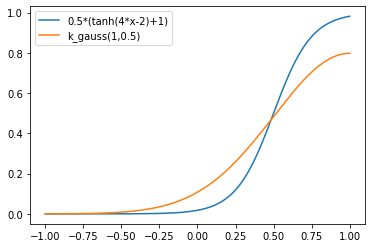

In [25]:
x = np.linspace(-1,1,1000)

def k_gauss(s, mu, sig): 
    return 1/(np.sqrt(2*np.pi)*sig)*np.exp(-1/2*((s-mu)/(sig))**2)


plt.plot(x,0.5*(np.tanh(4*(x-0.5))+1), label='0.5*(tanh(4*x-2)+1)')
plt.plot(x,k_gauss(x,1,0.5), label='k_gauss(1,0.5)')
plt.legend()

I think the tanh is easier to control than the Gaussian. It is also a common non-linearity used in neural networks. 

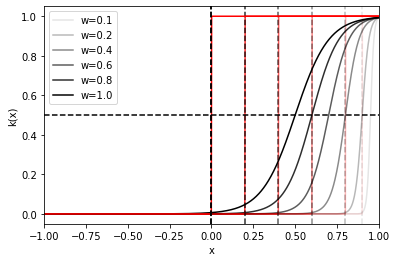

In [8]:
x = np.linspace(-1,1,1000)
scale_all = np.array([1, 0.8, 0.6, 0.4, 0.2, 0.1])[::-1]
alpha_all = np.linspace(0.1,1,len(scale_all))

for i,a in zip(scale_all, alpha_all):
    plt.plot(x,k_tanh(x,scale=i), label=f'w={np.round(i,1)}', c='k', alpha=a)
    plt.plot(x,np.heaviside(x-(1-i),0), c='r', alpha=a)
    plt.axvline(1-i, color='k', linestyle='--', alpha=a)
plt.axvline(0, color='k', linestyle='--')
plt.axhline(0.5, color='k', linestyle='--')
plt.xlim(-1,1)
plt.xlabel('x')
plt.ylabel('k(x)')
plt.legend()


### Component activation vector as a function of component width and shape

In [6]:
def gen_images(num_images, seed=98765):
    # Generate test images
    params_input = {'num_gabor': 40,
                    'adj_w':     True,
                    'adj_f':     False,
                    'alph_adj':  3,
                    'n_fam':     [1,3,8,18,38],
                    'n_im':      [3,6,9,12],
                    'dN':        list(np.array([0,22,44,66,88,110,143])/0.3), # number of recovery images presented, computed based read out from Homann graphs #[0,70,140,210,280,360,480]
                    'idx':       True
                    }

    rng = np.random.default_rng(seed)
    dim_ranges = gs.dim_ranges_rad.copy()

    im_params_all = []
    im_all = []
    for i in range(num_images):
        im_params = gs.generate_stim(dim_ranges,params_input['num_gabor'],rng,alph_adj=params_input['alph_adj'],adj_w=params_input['adj_w'],adj_f=params_input['adj_f'],sampling='basic')
        im,_ = gs.comp_gabor(dim_ranges[4],dim_ranges[5],im_params,resolution=100,magn=1)
        im_params_all.append(im_params)
        im_all.append(im)

    im_params_all = np.array(im_params_all)
    im_all = np.array(im_all)

    return im_params_all, im_all


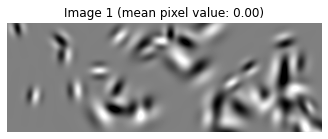

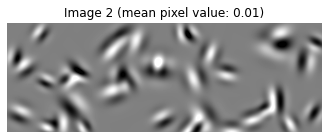

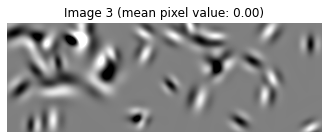

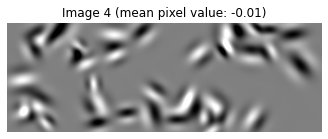

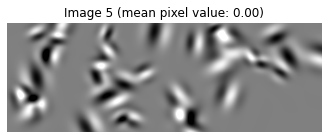

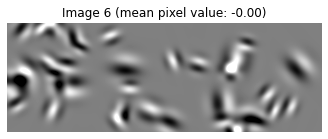

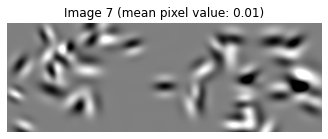

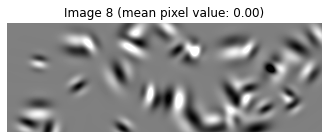

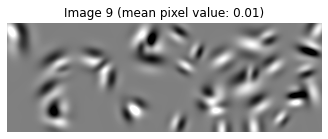

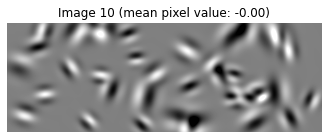

In [7]:
im_params_all, im_all = gen_images(10, seed=98765)

for i in range(im_all.shape[0]):
    plt.figure(figsize=(2* im_all.shape[2] / im_all.shape[1],2))
    plt.imshow(im_all[i,:,:], cmap='gray', vmin=-1, vmax=1)
    plt.title(f'Image {i+1} (mean pixel value: {np.mean(im_all[i,:,:]):.2f})')
    plt.axis('off')
    plt.show()  # Display each image one by one

In [7]:
# Compute component activation vectors for each model
def make_model(k_params_ext={}, kwargs_ext={}, input_params_ext={}, save_path_i=None):
    k_params = {'knum':             4,
                'type_complex':     8,
                'ratio_complex':    1/3,
                'num_complex':      8/3,
                'k_type':           'triangle',
                'cdens':            4,
                'k_alph':           0.1,
                'alph_leak':        0.1,
                'eps':              1e-6,
                'ksig':             1,
                'kcenter':          1,
                'conv':             True,
                'gabor_seed':       12345,
                'gabor_sampling':   'equidist_fixed'
                }
    
    kwargs = {'no_simple_cells':    False,
                'no_complex_cells': False,
                'mode_complex':     'sum', # 'sum' or 'mean'
                'debug':            False,
                'append_mode':      False,
                'start_id':         0,
                'savepath_sim_data': save_path_i,
                'savename_sim_data': 'sim_data_all',
                'record':           'all'
                }

    if 'type_complex' in k_params:
        kwargs['type_complex'] = [k_params['type_complex']]

    input_params = {'adj_w': True,
                    'adj_f': False,
                    'alph_adj': 3}

    # Update parameters
    k_params.update(k_params_ext)
    kwargs.update(kwargs_ext)
    input_params.update(input_params_ext)

    # Initialize Gabor kernel novelty model 
    k_params_components = gknovc.init_gabor_knov(gnum_complex=k_params['knum'],       # complex cells: number of different preferred orientations  
                                                    ctype=kwargs['type_complex'],       # complex cells: how many simple cells are pooled
                                                    dfreq=1.5,                           # complex cells: factor between simple cell frequencies (fixed at default)
                                                    cvar='frequency',                    # complex cells: feature of simple cells to be varied (fixed at default)
                                                    k_type=k_params['k_type'],           # simple cells: component shape
                                                    ksig=k_params['ksig'],               # simple cells: component width
                                                    kcenter=k_params['kcenter'],         # simple cells: component center (in similarity space)
                                                    seed=k_params['gabor_seed'],         # simple cells: seed for component generation 
                                                    rng=None,
                                                    mask=False,                          # simple cells: Gaussian mask if True (fixed at default False)
                                                    sampling=k_params['gabor_sampling'], # simple cells: sampling of preferred features (e.g. equidistant, random, ...)
                                                    adj_w=input_params['adj_w'],
                                                    adj_f=input_params['adj_f'],
                                                    alph_adj=input_params['alph_adj'],
                                                    conv=k_params['conv'],               # simple cells: convolutional simple cells if True
                                                    cdens=k_params['cdens'],             # simple cells: convolutional stride length 
                                                    parallel=False,                      # simple cells: parallel computation of activation matrix if True   
                                                    debug=kwargs['debug'] if 'debug' in kwargs else False
                                                )

    k_params.update(k_params_components)

    return k_params, kwargs

In [8]:
def get_model_activations(k_params, kwargs, stim_unique):

    # Initialize novelty model & extract kmat_seq
    k                   = k_params['k']
    kfun_idx            = k_params['kfun_idx']
    kfun_complex_idx    = k_params['kfun_complex_idx']
    ksig0               = k_params['ksig']
    cdens               = k_params['cdens'] if 'cdens' in k_params.keys() else None
    conv                = True if 'cdens' in k_params.keys() else False

    if conv:
        num_conv = stim_unique[0,::cdens,::cdens].size
        _, _, kmat_seq, _, klen = gknovc.init_nov_conv(k,kfun_idx,kfun_complex_idx,ksig0,num_conv,seq=stim_unique,kwargs=kwargs)
    else:
        _, _, kmat_seq, _, klen = gknovc.init_nov(k,kfun_idx,kfun_complex_idx,ksig0,seq=stim_unique,kwargs=kwargs)

    return kmat_seq, klen


#### Activations for single image (w between 0.5 and 1)

In [24]:
kmat_id_all = []
kmat_box_all = []
kmat_triangle_all = []
kmat_tanh_all = []

klen_id_all = []
klen_box_all = []
klen_triangle_all = []
klen_tanh_all = []

for i, scale in enumerate([0.5, 0.6, 0.7, 0.8, 0.9, 1.0]):
    model_id = make_model(k_params_ext={'k_type': 'id', 'ksig':scale}, kwargs_ext={}, input_params_ext={}, save_path_i=None)
    kmat_id, klen_id = get_model_activations(model_id[0], model_id[1], im_all[0,:,:][None,:,:])
    kmat_id_all.append(kmat_id)
    klen_id_all.append(klen_id)

    model_box = make_model(k_params_ext={'k_type': 'box', 'ksig':scale}, kwargs_ext={}, input_params_ext={}, save_path_i=None)
    kmat_box, klen_box = get_model_activations(model_box[0], model_box[1], im_all[0,:,:][None,:,:])
    kmat_box_all.append(kmat_box)
    klen_box_all.append(klen_box)

    model_triangle = make_model(k_params_ext={'k_type': 'triangle', 'ksig':scale}, kwargs_ext={}, input_params_ext={}, save_path_i=None)
    kmat_triangle, klen_triangle = get_model_activations(model_triangle[0], model_triangle[1], im_all[0,:,:][None,:,:])
    kmat_triangle_all.append(kmat_triangle)
    klen_triangle_all.append(klen_triangle)

    model_tanh = make_model(k_params_ext={'k_type': 'tanh', 'ksig':scale}, kwargs_ext={}, input_params_ext={}, save_path_i=None)
    kmat_tanh, klen_tanh = get_model_activations(model_tanh[0], model_tanh[1], im_all[0,:,:][None,:,:])
    kmat_tanh_all.append(kmat_tanh)
    klen_tanh_all.append(klen_tanh)

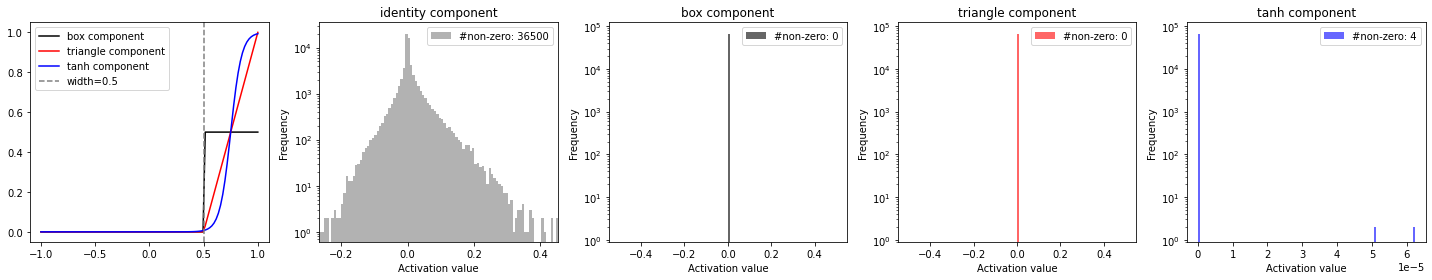

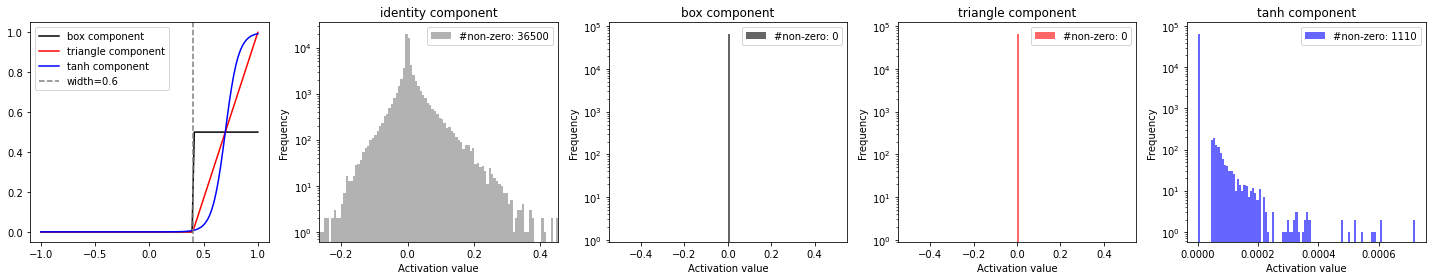

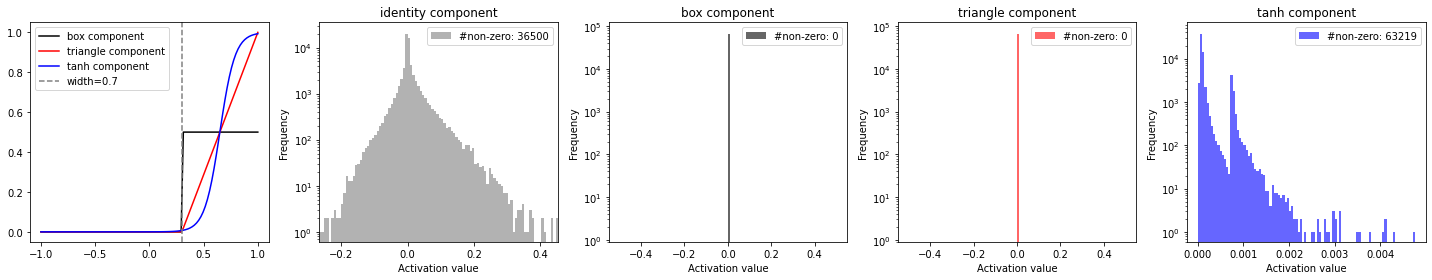

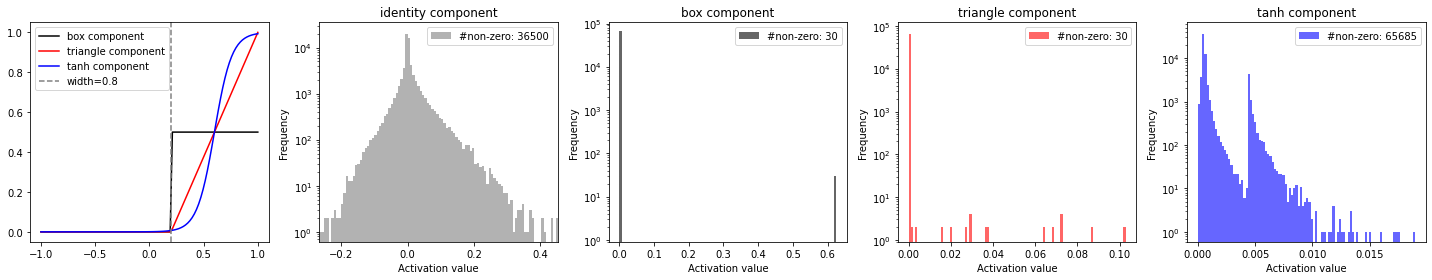

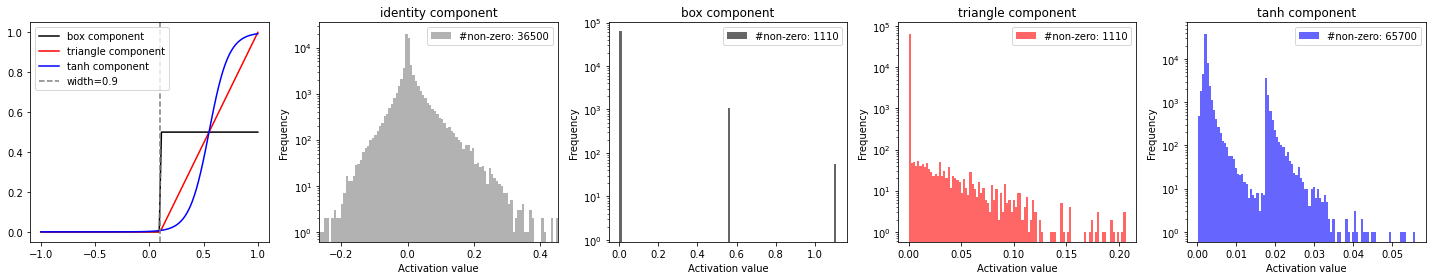

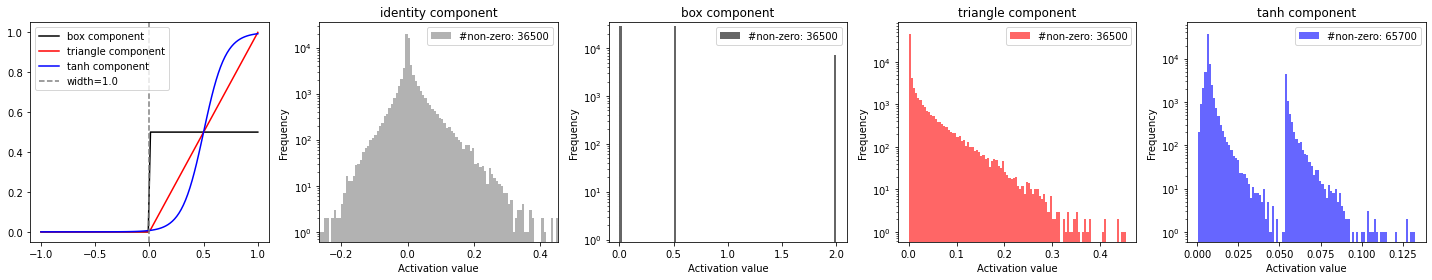

In [49]:
for i, scale in enumerate([0.5, 0.6, 0.7, 0.8, 0.9, 1.0]):
    kmat_id = kmat_id_all[i]
    kmat_box = kmat_box_all[i]
    kmat_triangle = kmat_triangle_all[i]
    kmat_tanh = kmat_tanh_all[i]

    f,ax = plt.subplots(1,5,figsize=(20,4))

    x = np.linspace(-1, 1, 100)
    ax[0].plot(x, k_box2(x, loc=1, scale=scale), 'k', label='box component')
    ax[0].plot(x, k_triangle3(x, loc=1, scale=scale), 'r', label='triangle component')
    ax[0].plot(x, k_tanh(x, scale=scale), 'b', label='tanh component')
    ax[0].axvline(1-scale, color='gray', linestyle='--', label=f'width={scale}')
    ax[0].legend()

    ax[1].hist(kmat_id[:,0], bins=100, alpha=0.6, color='grey', label=f'#non-zero: {np.sum(kmat_id[:,0]>0)}')
    ax[1].set_title('identity component')
    ax[1].set_xlim(np.min(kmat_id[:,0]), np.max(kmat_id[:,0]))

    ax[2].hist(kmat_box[:,0], bins=100, alpha=0.6, color='k', label=f'#non-zero: {np.sum(kmat_box[:,0]>0)}')
    ax[2].set_title('box component')
    # ax[2].set_xlim(np.min(kmat_box[:,0]), np.max(kmat_box[:,0]))

    ax[3].hist(kmat_triangle[:,0], bins=100, alpha=0.6, color='r', label=f'#non-zero: {np.sum(kmat_triangle[:,0]>0)}')
    ax[3].set_title('triangle component')
    # ax[3].set_xlim(np.min(kmat_triangle[:,0]), np.max(kmat_triangle[:,0]))

    ax[4].hist(kmat_tanh[:,0], bins=100, alpha=0.6, color='b', label=f'#non-zero: {np.sum(kmat_tanh[:,0]>0)}')
    ax[4].set_title('tanh component')
    # ax[4].set_xlim(np.min(kmat_tanh[:,0]), np.max(kmat_tanh[:,0]))

    for i in range(1,len(ax)):
        ax[i].set_xlabel('Activation value')
        ax[i].set_ylabel('Frequency')
        ax[i].set_yscale('log')
        ax[i].set_ylim([np.min([ax[i].get_ylim()[0],0.9]), 1.1* ax[i].get_ylim()[1]])
        # ax[i].axvline(1-scale, color='k', linestyle='--')
        ax[i].legend()
        # ax[i].ticklabel_format(axis='y', style='sci', scilimits=(0,0))

    f.tight_layout()
    ax[-1].get_ylim()

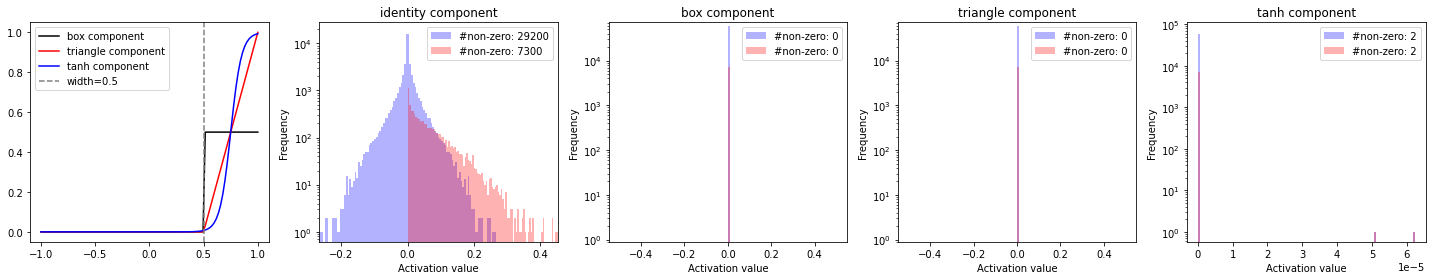

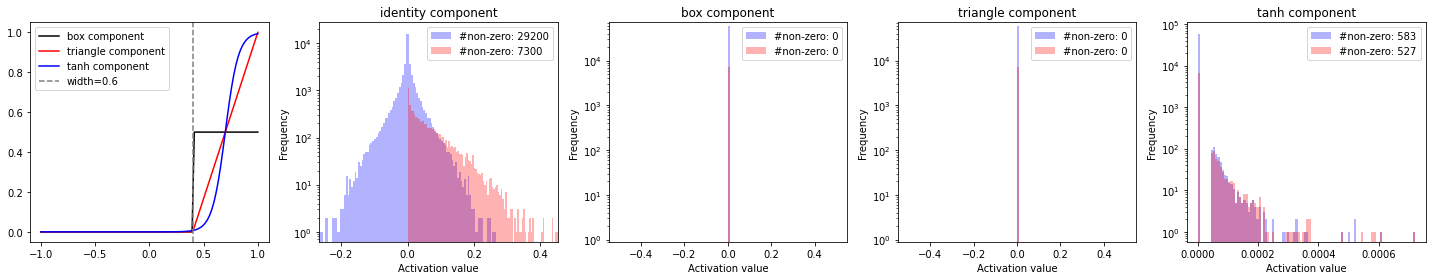

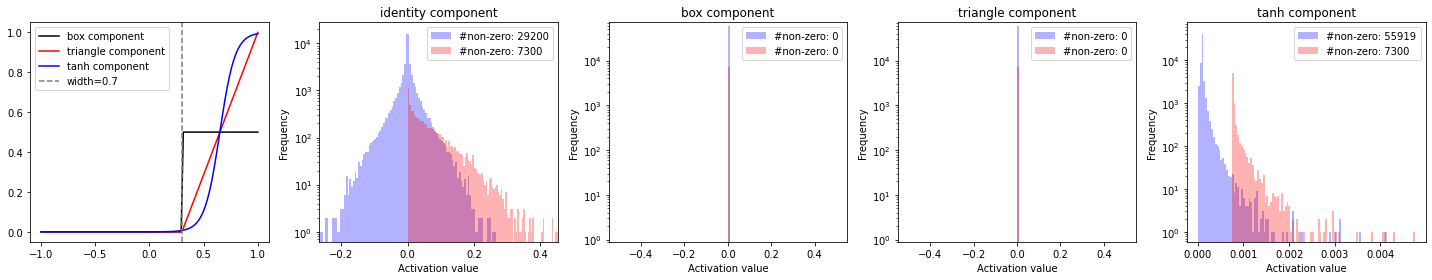

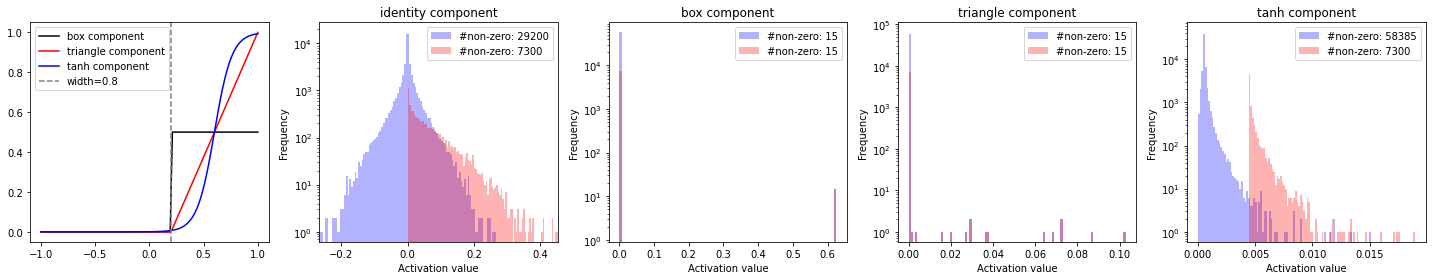

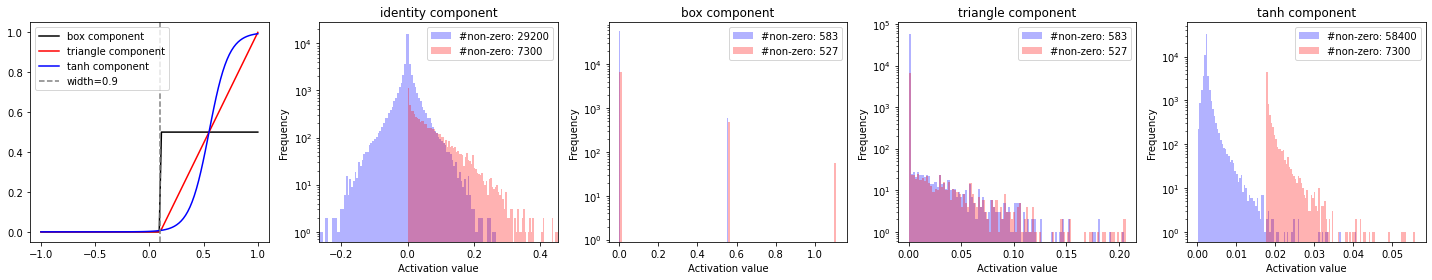

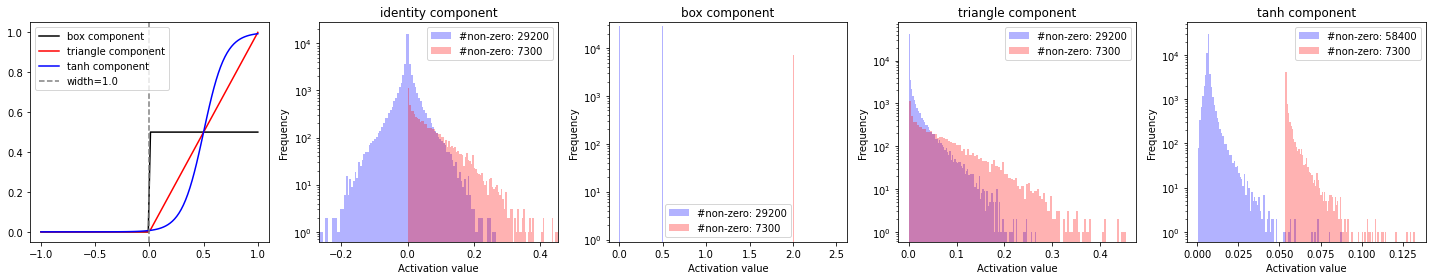

In [48]:
for i, scale in enumerate([0.5, 0.6, 0.7, 0.8, 0.9, 1.0]):
    kmat_id = kmat_id_all[i]
    kmat_box = kmat_box_all[i]
    kmat_triangle = kmat_triangle_all[i]
    kmat_tanh = kmat_tanh_all[i]

    nsimple_id, ncomplex_id, nconv_id = klen_id_all[i]
    nsimple_box, ncomplex_box, nconv_box = klen_box_all[i]
    nsimple_triangle, ncomplex_triangle, nconv_triangle = klen_triangle_all[i]
    nsimple_tanh, ncomplex_tanh, nconv_tanh = klen_tanh_all[i]

    f,ax = plt.subplots(1,5,figsize=(20,4))

    x = np.linspace(-1, 1, 100)
    ax[0].plot(x, k_box2(x, loc=1, scale=scale), 'k', label='box component')
    ax[0].plot(x, k_triangle3(x, loc=1, scale=scale), 'r', label='triangle component')
    ax[0].plot(x, k_tanh(x, scale=scale), 'b', label='tanh component')
    ax[0].axvline(1-scale, color='gray', linestyle='--', label=f'width={scale}')
    ax[0].legend()

    ax[1].hist(kmat_id[:nsimple_id*nconv_id,0], bins=100, alpha=0.3, color='b', label=f'#non-zero: {np.sum(kmat_id[:nsimple_id*nconv_id,0]>0)}')
    ax[1].hist(kmat_id[nsimple_id*nconv_id:,0], bins=100, alpha=0.3, color='r', label=f'#non-zero: {np.sum(kmat_id[nsimple_id*nconv_id:,0]>0)}')
    ax[1].set_title('identity component')
    ax[1].set_xlim(np.min(kmat_id[:,0]), np.max(kmat_id[:,0]))

    ax[2].hist(kmat_box[:nsimple_box*nconv_box,0], bins=100, alpha=0.3, color='b', label=f'#non-zero: {np.sum(kmat_box[:nsimple_box*nconv_box,0]>0)}')
    ax[2].hist(kmat_box[nsimple_box*nconv_box:,0], bins=100, alpha=0.3, color='r', label=f'#non-zero: {np.sum(kmat_box[nsimple_box*nconv_box:,0]>0)}')
    ax[2].set_title('box component')
    # ax[2].set_xlim(np.min(kmat_box[:,0]), np.max(kmat_box[:,0]))

    ax[3].hist(kmat_triangle[:nsimple_triangle*nconv_triangle,0], bins=100, alpha=0.3, color='b', label=f'#non-zero: {np.sum(kmat_triangle[:nsimple_triangle*nconv_triangle,0]>0)}')
    ax[3].hist(kmat_triangle[nsimple_triangle*nconv_triangle:,0], bins=100, alpha=0.3, color='r', label=f'#non-zero: {np.sum(kmat_triangle[nsimple_triangle*nconv_triangle:,0]>0)}')
    ax[3].set_title('triangle component')
    # ax[3].set_xlim(np.min(kmat_triangle[:,0]), np.max(kmat_triangle[:,0]))

    ax[4].hist(kmat_tanh[:nsimple_tanh*nconv_tanh,0], bins=100, alpha=0.3, color='b', label=f'#non-zero: {np.sum(kmat_tanh[:nsimple_tanh*nconv_tanh,0]>0)}')
    ax[4].hist(kmat_tanh[nsimple_tanh*nconv_tanh:,0], bins=100, alpha=0.3, color='r', label=f'#non-zero: {np.sum(kmat_tanh[nsimple_tanh*nconv_tanh:,0]>0)}')
    ax[4].set_title('tanh component')
    # ax[4].set_xlim(np.min(kmat_tanh[:,0]), np.max(kmat_tanh[:,0]))

    for i in range(1,len(ax)):
        ax[i].set_xlabel('Activation value')
        ax[i].set_ylabel('Frequency')
        ax[i].set_yscale('log')
        ax[i].set_ylim([np.min([ax[i].get_ylim()[0],0.9]), 1.1* ax[i].get_ylim()[1]])

        # ax[i].axvline(1-scale, color='k', linestyle='--')
        ax[i].legend()
        # ax[i].ticklabel_format(axis='y', style='sci', scilimits=(0,0))

    f.tight_layout()

Interesting - tanh is more robustly giving activations than triangle and box.

#### Activations across 10 images (widths between 0.5 and 1)

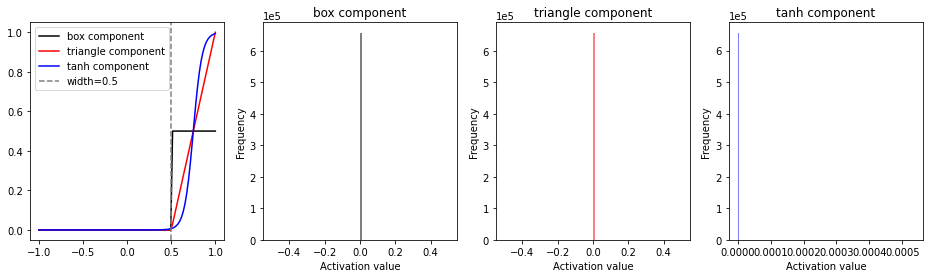

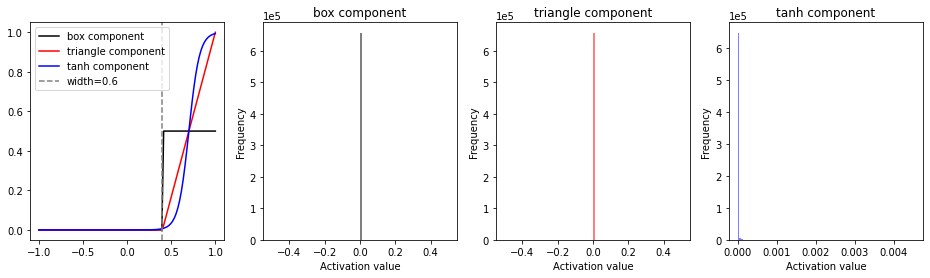

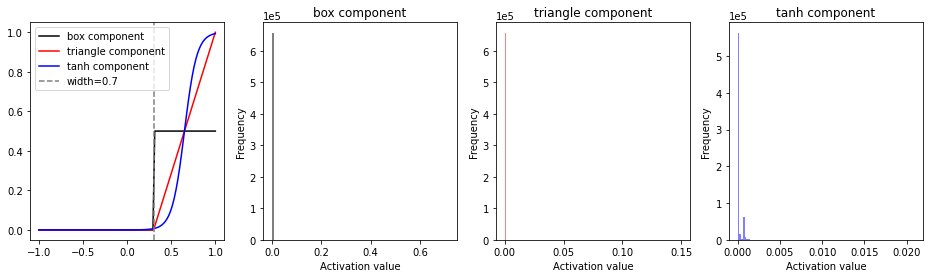

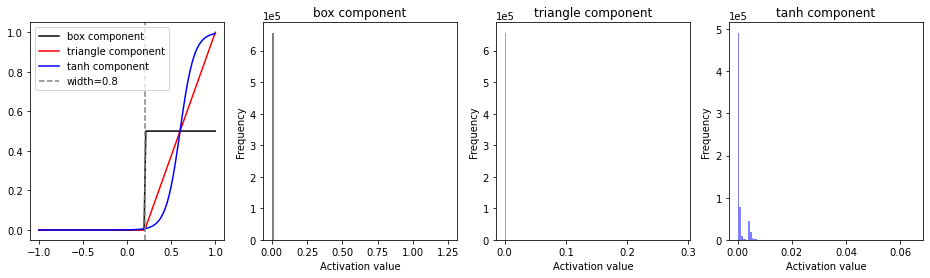

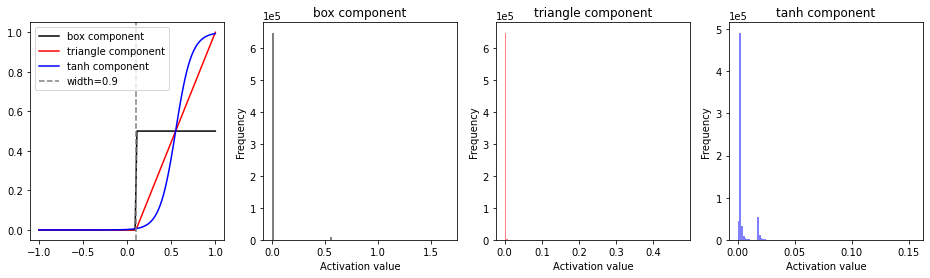

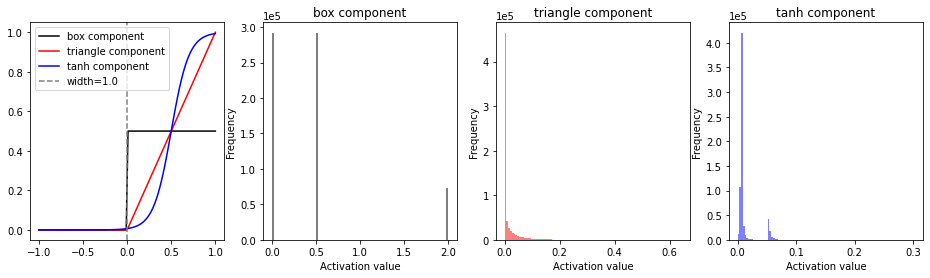

In [20]:
for i, scale in enumerate([0.5, 0.6, 0.7, 0.8, 0.9, 1.0]):
    model_box = make_model(k_params_ext={'k_type': 'box', 'ksig':scale}, kwargs_ext={}, input_params_ext={}, save_path_i=None)
    kmat_box = get_model_activations(model_box[0], model_box[1], im_all)

    model_triangle = make_model(k_params_ext={'k_type': 'triangle', 'ksig':scale}, kwargs_ext={}, input_params_ext={}, save_path_i=None)
    kmat_triangle = get_model_activations(model_triangle[0], model_triangle[1], im_all)

    model_tanh = make_model(k_params_ext={'k_type': 'tanh', 'ksig':scale}, kwargs_ext={}, input_params_ext={}, save_path_i=None)
    kmat_tanh = get_model_activations(model_tanh[0], model_tanh[1], im_all)

    f,ax = plt.subplots(1,4,figsize=(16,4))

    x = np.linspace(-1, 1, 100)
    ax[0].plot(x, k_box2(x, loc=1, scale=scale), 'k', label='box component')
    ax[0].plot(x, k_triangle3(x, loc=1, scale=scale), 'r', label='triangle component')
    ax[0].plot(x, k_tanh(x, scale=scale), 'b', label='tanh component')
    ax[0].axvline(1-scale, color='gray', linestyle='--', label=f'width={scale}')
    ax[0].legend()

    ax[1].hist(kmat_box.flatten(), bins=100, alpha=0.5, color='k')
    ax[1].set_title('box component')
    ax[2].hist(kmat_triangle.flatten(), bins=100, alpha=0.5, color='r')
    ax[2].set_title('triangle component')
    ax[3].hist(kmat_tanh.flatten(), bins=100, alpha=0.5, color='b')
    ax[3].set_title('tanh component')

    for i in range(1,len(ax)):
        ax[i].set_xlabel('Activation value')
        ax[i].set_ylabel('Frequency')
        ax[i].ticklabel_format(axis='y', style='sci', scilimits=(0,0))

If we cumulate activations over multiple images (N=10), that remains the same.

#### Activation for single image (widths between 0.95 and 1)

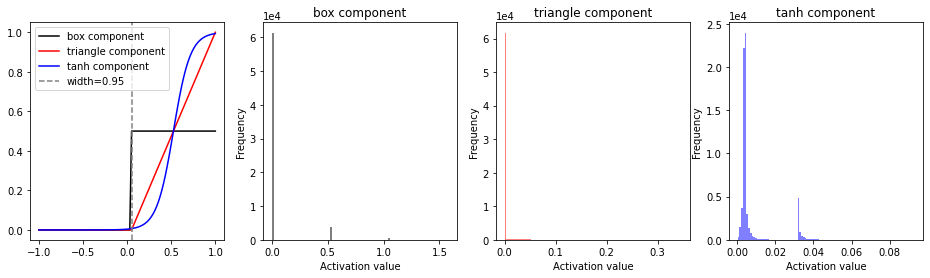

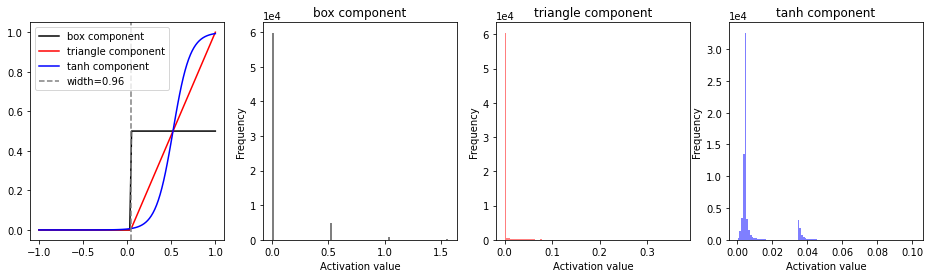

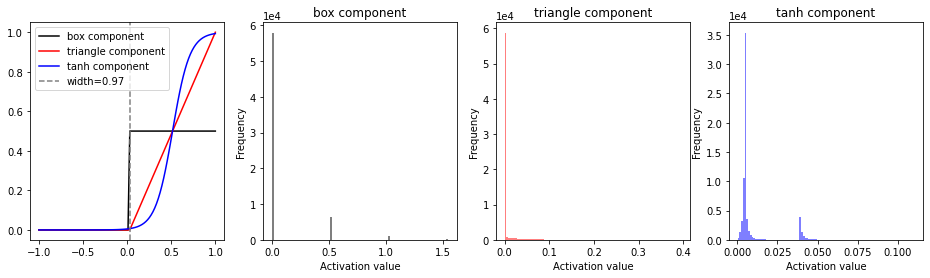

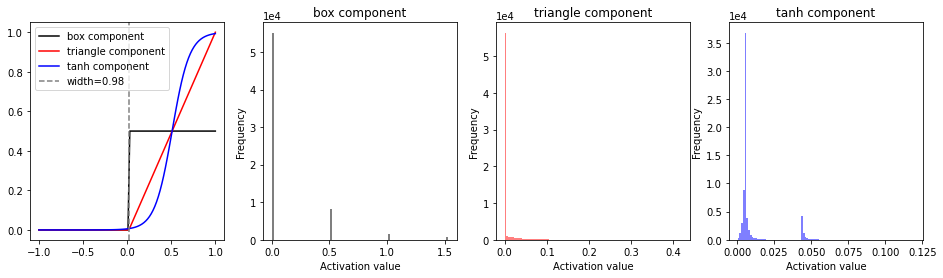

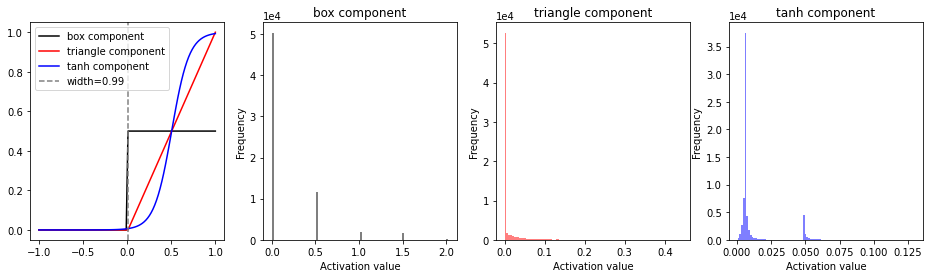

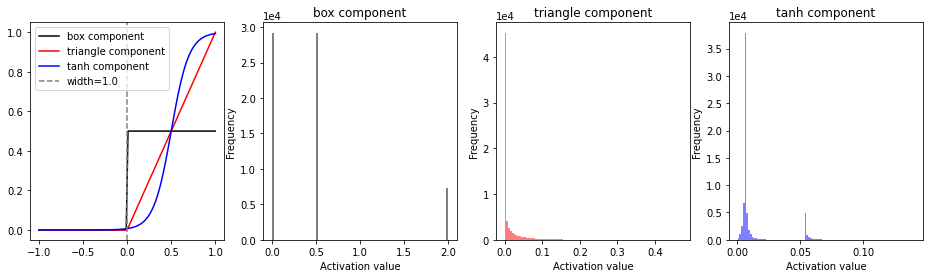

In [21]:
for i, scale in enumerate([0.95, 0.96, 0.97, 0.98, 0.99, 1.0]):
    model_box = make_model(k_params_ext={'k_type': 'box', 'ksig':scale}, kwargs_ext={}, input_params_ext={}, save_path_i=None)
    kmat_box = get_model_activations(model_box[0], model_box[1], im_all[0,:,:][None,:,:])

    model_triangle = make_model(k_params_ext={'k_type': 'triangle', 'ksig':scale}, kwargs_ext={}, input_params_ext={}, save_path_i=None)
    kmat_triangle = get_model_activations(model_triangle[0], model_triangle[1], im_all[0,:,:][None,:,:])

    model_tanh = make_model(k_params_ext={'k_type': 'tanh', 'ksig':scale}, kwargs_ext={}, input_params_ext={}, save_path_i=None)
    kmat_tanh = get_model_activations(model_tanh[0], model_tanh[1], im_all[0,:,:][None,:,:])

    f,ax = plt.subplots(1,4,figsize=(16,4))

    x = np.linspace(-1, 1, 100)
    ax[0].plot(x, k_box2(x, loc=1, scale=scale), 'k', label='box component')
    ax[0].plot(x, k_triangle3(x, loc=1, scale=scale), 'r', label='triangle component')
    ax[0].plot(x, k_tanh(x, scale=scale), 'b', label='tanh component')
    ax[0].axvline(1-scale, color='gray', linestyle='--', label=f'width={scale}')
    ax[0].legend()

    for i in range(1):
        ax[1].hist(kmat_box[:,i], bins=100, alpha=0.5, color='k', label=f'Image {i+1}')
        ax[1].set_title('box component')
        ax[2].hist(kmat_triangle[:,i], bins=100, alpha=0.5, color='r', label=f'Image {i+1}')
        ax[2].set_title('triangle component')
        ax[3].hist(kmat_tanh[:,i], bins=100, alpha=0.5, color='b', label=f'Image {i+1}')
        ax[3].set_title('tanh component')

    for i in range(1,len(ax)):
        ax[i].set_xlabel('Activation value')
        ax[i].set_ylabel('Frequency')
        ax[i].ticklabel_format(axis='y', style='sci', scilimits=(0,0))

In a smaller range around width = 1, we find a more graded picture -- this is the range we should be looking at, probably (at least for triangle and box).

### Activations for widths larger than 1

In [31]:
kmat_id_all = []
kmat_box_all = []
kmat_triangle_all = []
kmat_tanh_all = []

klen_id_all = []
klen_box_all = []
klen_triangle_all = []
klen_tanh_all = []

for i, scale in enumerate([1.0, 1.05, 1.1, 1.2]):
    model_id = make_model(k_params_ext={'k_type': 'id', 'ksig':scale}, kwargs_ext={}, input_params_ext={}, save_path_i=None)
    kmat_id, klen_id = get_model_activations(model_id[0], model_id[1], im_all[0,:,:][None,:,:])
    kmat_id_all.append(kmat_id)
    klen_id_all.append(klen_id)

    model_box = make_model(k_params_ext={'k_type': 'box', 'ksig':scale}, kwargs_ext={}, input_params_ext={}, save_path_i=None)
    kmat_box, klen_box = get_model_activations(model_box[0], model_box[1], im_all[0,:,:][None,:,:])
    kmat_box_all.append(kmat_box)
    klen_box_all.append(klen_box)

    model_triangle = make_model(k_params_ext={'k_type': 'triangle', 'ksig':scale}, kwargs_ext={}, input_params_ext={}, save_path_i=None)
    kmat_triangle, klen_triangle = get_model_activations(model_triangle[0], model_triangle[1], im_all[0,:,:][None,:,:])
    kmat_triangle_all.append(kmat_triangle)
    klen_triangle_all.append(klen_triangle)

    model_tanh = make_model(k_params_ext={'k_type': 'tanh', 'ksig':scale}, kwargs_ext={}, input_params_ext={}, save_path_i=None)
    kmat_tanh, klen_tanh = get_model_activations(model_tanh[0], model_tanh[1], im_all[0,:,:][None,:,:])
    kmat_tanh_all.append(kmat_tanh)
    klen_tanh_all.append(klen_tanh)

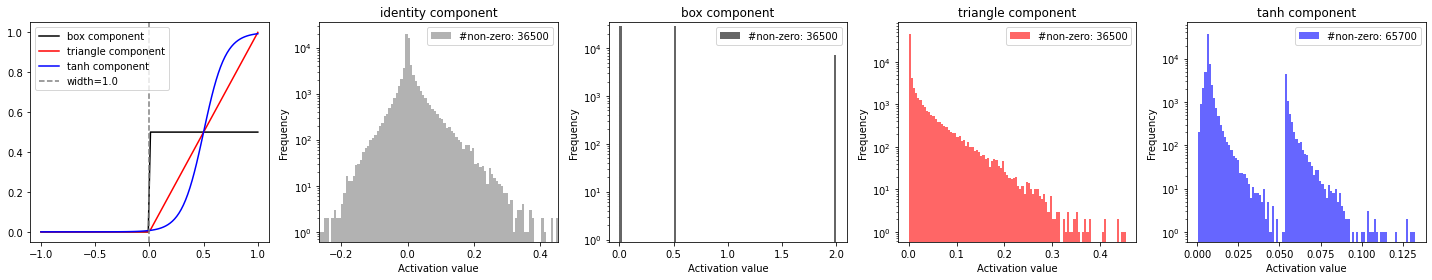

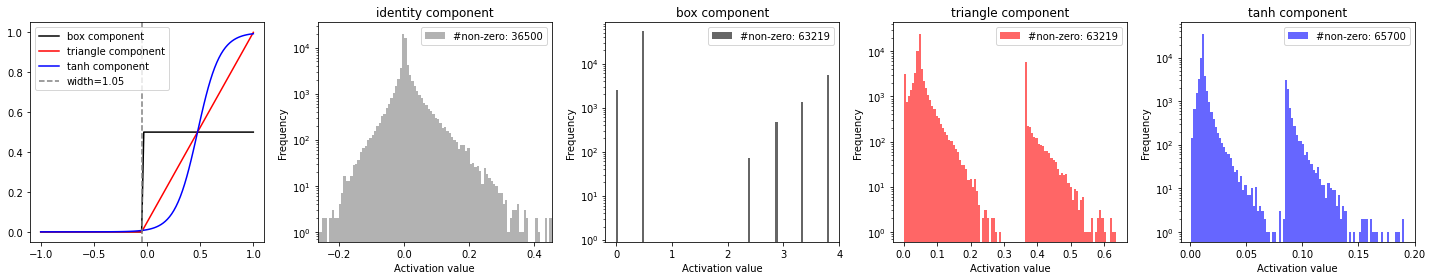

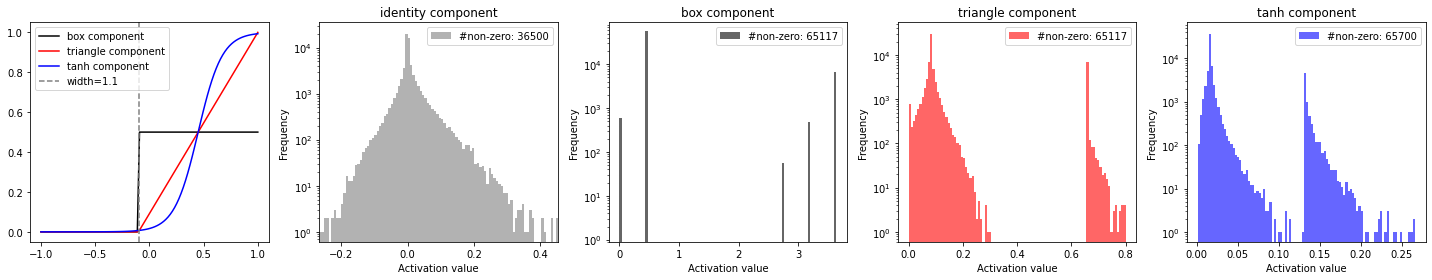

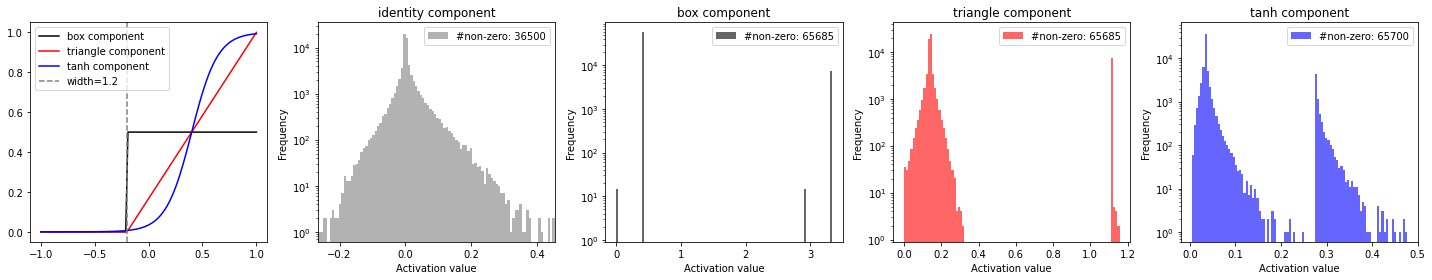

In [32]:
for i, scale in enumerate([1.0, 1.05, 1.1, 1.2]):
    kmat_id = kmat_id_all[i]
    kmat_box = kmat_box_all[i]
    kmat_triangle = kmat_triangle_all[i]
    kmat_tanh = kmat_tanh_all[i]

    f,ax = plt.subplots(1,5,figsize=(20,4))

    x = np.linspace(-1, 1, 100)
    ax[0].plot(x, k_box2(x, loc=1, scale=scale), 'k', label='box component')
    ax[0].plot(x, k_triangle3(x, loc=1, scale=scale), 'r', label='triangle component')
    ax[0].plot(x, k_tanh(x, scale=scale), 'b', label='tanh component')
    ax[0].axvline(1-scale, color='gray', linestyle='--', label=f'width={scale}')
    ax[0].legend()

    ax[1].hist(kmat_id[:,0], bins=100, alpha=0.6, color='grey', label=f'#non-zero: {np.sum(kmat_id[:,0]>0)}')
    ax[1].set_title('identity component')
    ax[1].set_xlim(np.min(kmat_id[:,0]), np.max(kmat_id[:,0]))

    ax[2].hist(kmat_box[:,0], bins=100, alpha=0.6, color='k', label=f'#non-zero: {np.sum(kmat_box[:,0]>0)}')
    ax[2].set_title('box component')
    # ax[2].set_xlim(np.min(kmat_box[:,0]), np.max(kmat_box[:,0]))

    ax[3].hist(kmat_triangle[:,0], bins=100, alpha=0.6, color='r', label=f'#non-zero: {np.sum(kmat_triangle[:,0]>0)}')
    ax[3].set_title('triangle component')
    # ax[3].set_xlim(np.min(kmat_triangle[:,0]), np.max(kmat_triangle[:,0]))

    ax[4].hist(kmat_tanh[:,0], bins=100, alpha=0.6, color='b', label=f'#non-zero: {np.sum(kmat_tanh[:,0]>0)}')
    ax[4].set_title('tanh component')
    # ax[4].set_xlim(np.min(kmat_tanh[:,0]), np.max(kmat_tanh[:,0]))

    for i in range(1,len(ax)):
        ax[i].set_xlabel('Activation value')
        ax[i].set_ylabel('Frequency')
        ax[i].set_yscale('log')
        ax[i].set_ylim([np.min([ax[i].get_ylim()[0],0.9]), 1.1* ax[i].get_ylim()[1]])
        # ax[i].axvline(1-scale, color='k', linestyle='--')
        ax[i].legend()
        # ax[i].ticklabel_format(axis='y', style='sci', scilimits=(0,0))

    f.tight_layout()
    ax[-1].get_ylim()

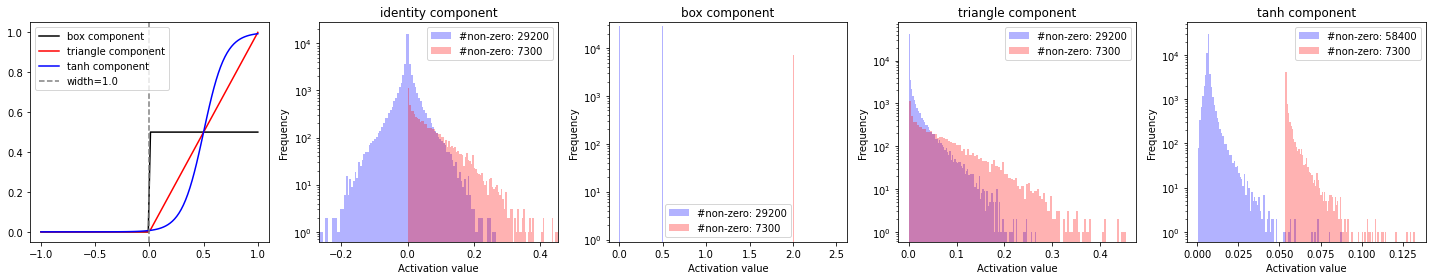

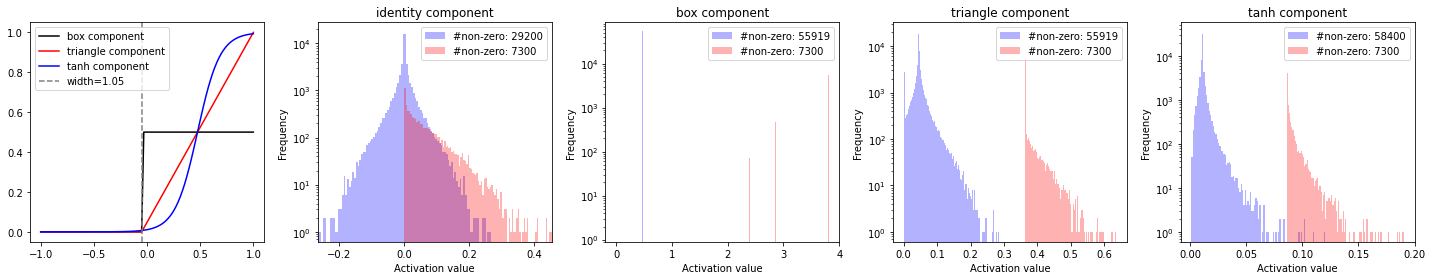

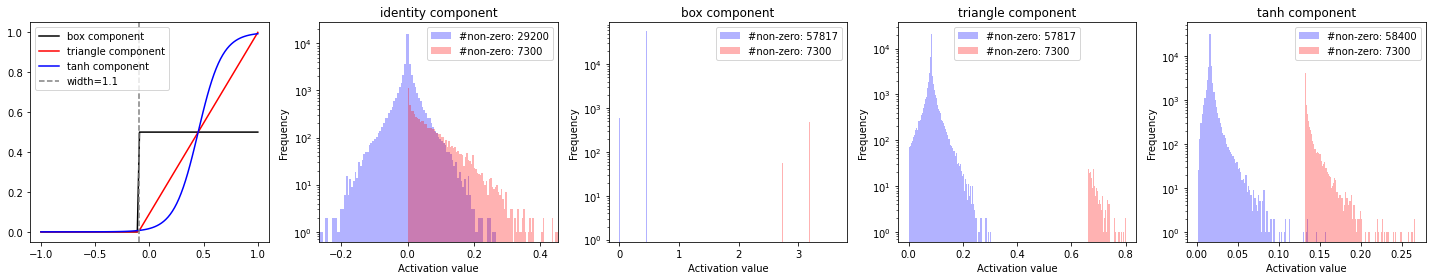

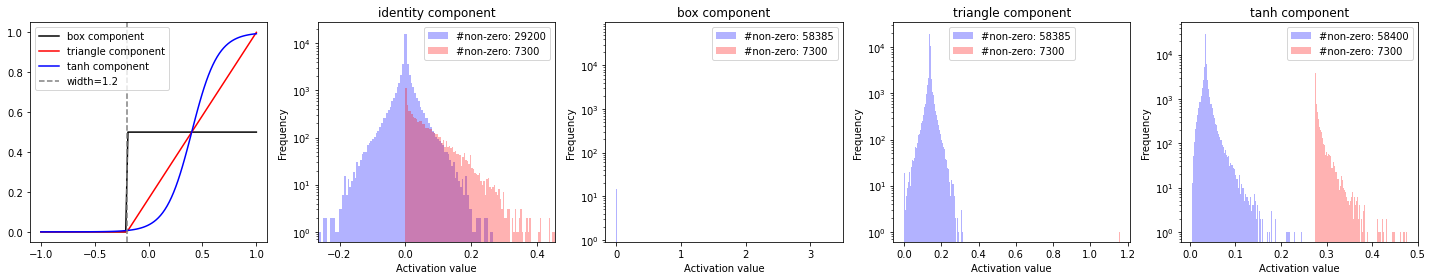

In [34]:
for i, scale in enumerate([1.0, 1.05, 1.1, 1.2]):
    kmat_id = kmat_id_all[i]
    kmat_box = kmat_box_all[i]
    kmat_triangle = kmat_triangle_all[i]
    kmat_tanh = kmat_tanh_all[i]

    nsimple_id, ncomplex_id, nconv_id = klen_id_all[i]
    nsimple_box, ncomplex_box, nconv_box = klen_box_all[i]
    nsimple_triangle, ncomplex_triangle, nconv_triangle = klen_triangle_all[i]
    nsimple_tanh, ncomplex_tanh, nconv_tanh = klen_tanh_all[i]

    f,ax = plt.subplots(1,5,figsize=(20,4))

    x = np.linspace(-1, 1, 100)
    ax[0].plot(x, k_box2(x, loc=1, scale=scale), 'k', label='box component')
    ax[0].plot(x, k_triangle3(x, loc=1, scale=scale), 'r', label='triangle component')
    ax[0].plot(x, k_tanh(x, scale=scale), 'b', label='tanh component')
    ax[0].axvline(1-scale, color='gray', linestyle='--', label=f'width={scale}')
    ax[0].legend()

    ax[1].hist(kmat_id[:nsimple_id*nconv_id,0], bins=100, alpha=0.3, color='b', label=f'#non-zero: {np.sum(kmat_id[:nsimple_id*nconv_id,0]>0)}')
    ax[1].hist(kmat_id[nsimple_id*nconv_id:,0], bins=100, alpha=0.3, color='r', label=f'#non-zero: {np.sum(kmat_id[nsimple_id*nconv_id:,0]>0)}')
    ax[1].set_title('identity component')
    ax[1].set_xlim(np.min(kmat_id[:,0]), np.max(kmat_id[:,0]))

    ax[2].hist(kmat_box[:nsimple_box*nconv_box,0], bins=100, alpha=0.3, color='b', label=f'#non-zero: {np.sum(kmat_box[:nsimple_box*nconv_box,0]>0)}')
    ax[2].hist(kmat_box[nsimple_box*nconv_box:,0], bins=100, alpha=0.3, color='r', label=f'#non-zero: {np.sum(kmat_box[nsimple_box*nconv_box:,0]>0)}')
    ax[2].set_title('box component')
    # ax[2].set_xlim(np.min(kmat_box[:,0]), np.max(kmat_box[:,0]))

    ax[3].hist(kmat_triangle[:nsimple_triangle*nconv_triangle,0], bins=100, alpha=0.3, color='b', label=f'#non-zero: {np.sum(kmat_triangle[:nsimple_triangle*nconv_triangle,0]>0)}')
    ax[3].hist(kmat_triangle[nsimple_triangle*nconv_triangle:,0], bins=100, alpha=0.3, color='r', label=f'#non-zero: {np.sum(kmat_triangle[nsimple_triangle*nconv_triangle:,0]>0)}')
    ax[3].set_title('triangle component')
    # ax[3].set_xlim(np.min(kmat_triangle[:,0]), np.max(kmat_triangle[:,0]))

    ax[4].hist(kmat_tanh[:nsimple_tanh*nconv_tanh,0], bins=100, alpha=0.3, color='b', label=f'#non-zero: {np.sum(kmat_tanh[:nsimple_tanh*nconv_tanh,0]>0)}')
    ax[4].hist(kmat_tanh[nsimple_tanh*nconv_tanh:,0], bins=100, alpha=0.3, color='r', label=f'#non-zero: {np.sum(kmat_tanh[nsimple_tanh*nconv_tanh:,0]>0)}')
    ax[4].set_title('tanh component')
    # ax[4].set_xlim(np.min(kmat_tanh[:,0]), np.max(kmat_tanh[:,0]))

    for i in range(1,len(ax)):
        ax[i].set_xlabel('Activation value')
        ax[i].set_ylabel('Frequency')
        ax[i].set_yscale('log')
        ax[i].set_ylim([np.min([ax[i].get_ylim()[0],0.9]), 1.1* ax[i].get_ylim()[1]])

        # ax[i].axvline(1-scale, color='k', linestyle='--')
        ax[i].legend()
        # ax[i].ticklabel_format(axis='y', style='sci', scilimits=(0,0))

    f.tight_layout()

In [43]:
len(kmat_id_all[0])

65700

### Behavior in Homann experiments as a function of component width and shape

In [16]:
def run_exp(exp_type,model_name,k_type,ksig,num_sim=1,inputs=None,params_input=None,k_params=None):
    
    path_load = f'/Users/sbecker/Projects/RL_reward_novelty/data/2025_06_test-shape_{model_name}/'

    # Set path
    save_path_i = os.path.join(path_load,f'{k_type}_{ksig}/'.replace(".","-"))
    sl.make_long_dir(save_path_i)

    if inputs is None or params_input is None:
        # Set input parameters
        parallel_exp = False
        init_seed = 98765
        input_corrected = True
        input_sequence_mode = 'sep'

        params_input = {'num_gabor':     40,
                            'adj_w':     True,
                            'adj_f':     False,
                            'alph_adj':  3,
                            'n_fam':     [1,3,8,18,38],
                            'n_im':      [3,6,9,12],
                            'dN':        list(np.array([0,22,44,66,88,110,143])/0.3), #[0,70,140,210,280,360,480],
                            'idx':       True
                            }

        # Generate inputs
        seed_input, inputs, params_input = gsc.generate_input(params_input,num_sim,init_seed,input_corrected=input_corrected,input_sequence_mode=input_sequence_mode)

    k_params_ext = k_params if k_params is not None else {}
    k_params_ext.update({'k_type': k_type, 'ksig': ksig})
    k_params, kwargs = make_model(k_params_ext=k_params_ext, save_path_i=save_path_i)

    # Set experiment
    if exp_type=='l':
        idx_input = 0
        var_input = 'n_fam'
    elif exp_type=='lp':
        idx_input = 1
        var_input = 'dN'
    elif exp_type=='m':
        idx_input = 2
        var_input = 'n_im'

    n_fam = params_input[var_input]
    idx   = True

    # Set leakiness type
    flr   = True if 'fr' in model_name else False
    k_params['flr'] = flr

    all_data = []
    all_components = []
    all_weights = []
    all_resp = []
    all_temp = []
    for i in range(len(inputs)):
        ivec  = inputs[i][idx_input][0]
        iseed = inputs[i][idx_input][1]
        itype = inputs[i][idx_input][2]
        
        # Simulate experiment
        data_i = []
        components_i = []
        weights_i = []
        resp_i = []
        temp_i = []
        for j in range(len(ivec)):
            print(f'cond: {j}/{len(ivec)}. sim: {i}/{len(inputs)}. model: {k_type}-{ksig}.\n')
            stim_type = itype[j] if kwargs['debug'] else None
            if flr:
                idata,icomponents,_,iweights = gknovc.run_gabor_knov_withparams_flr2(ivec[j],k_params,idx=idx,stim_type=stim_type,kwargs=kwargs)
                components_i.append(icomponents)
                weights_i.append(iweights)
            else:
                idata,icomponents,_,iweights,iresp,itemp = gknovc.run_gabor_knov_withparams_leaky2(ivec[j],k_params,idx=idx,stim_type=stim_type,kwargs=kwargs)
                components_i.append(icomponents)
                weights_i.append(iweights)
                resp_i.append(iresp)  
                temp_i.append(itemp)
            idata['sim_id'] = i
            idata[var_input] = [n_fam[j]]*len(idata) 
            idata['seed']  = [iseed]*len(idata)  
            idata['stim_type'] = itype[j] 
            data_i.append(idata)
        data_i = pd.concat(data_i)
        all_data.append(data_i)
        if i==0:
            all_components = components_i
            all_weights = weights_i
            all_resp = resp_i
            all_temp = temp_i
    
    data = pd.concat(all_data)
    
    if save_path_i is not None:
        data.to_csv(os.path.join(save_path_i, f'sim_data_{exp_type}.csv'))        
    
    return data, all_components, all_weights, all_resp, all_temp

In [17]:
def run_and_plot_exp(all_model, all_ksig, exp_name, var_input, var_output, num_sim=1):
    model_name = 'flr_snov'
    
    cm = plt.get_cmap('viridis')
    col_all = [cm(i) for i in np.linspace(0, 1, len(all_model))]

    all_data = []
    # all_components = []
    # all_weights = []
    # all_resp = []
    # all_temp = []
    for gid, (k_type, ksig) in enumerate(zip(all_model, all_ksig)):

        data, _,_,_,_ = run_exp(exp_name,model_name,k_type=k_type,ksig=ksig,num_sim=num_sim,inputs=None,params_input=None,k_params=None)
        all_data.append(data)
        # all_components.append(components)
        # all_weights.append(weights)
        # all_resp.append(resp)
        # all_temp.append(temp)

    # Plot stats
    f,ax = plt.subplots(1,1, figsize=(4,4))

    for i, (model_i, ksig_i, col_i) in enumerate(zip(all_model, all_ksig, col_all)):
        if exp_name=='l':
            data_nov, _ = sd.get_nov_response(all_data[i],var_input,get_stats=False) 
        elif exp_name=='lp':
            data_nov, _ = sd.get_trans_response(all_data[i],var_input,get_stats=False)
        elif exp_name=='m':
            data_nov, _ = sd.get_nov_response(all_data[i],var_input,get_stats=False,vary_with_m=True,cycle_m=5)

        ax.plot(data_nov[var_input], data_nov[var_output], marker='o', ls='-', c=col_i, lw=1,label=f'{model_i} (ksig={ksig_i})')

    ax.set_xlabel(var_input)
    ax.set_ylabel(var_output)
    ax.legend()

    # Plot details
    conds = all_data[0][var_input].unique()
    f, axl = plt.subplots(1,len(conds),figsize=(len(conds)*4,4))
    for j, cond_j in enumerate(conds):
        for i, (model_i, ksig_i, col_i) in enumerate(zip(all_model, all_ksig, col_all)):
            data_ij = all_data[i].loc[all_data[i][var_input]==cond_j]
            axl[j].plot(data_ij['nt'], alpha=0.5, c=col_i, label=f'{model_i} (w={ksig_i})')
    axl[-1].legend()

In [21]:
def load_and_plot_exp(all_model, all_ksig, exp_name, var_input, var_output, num_sim=1):
    model_name = 'flr_snov'
    
    cm = plt.get_cmap('viridis')
    col_all = [cm(i) for i in np.linspace(0, 1, len(all_model))]

    all_data = []
    # all_components = []
    # all_weights = []
    # all_resp = []
    # all_temp = []
    for gid, (k_type, ksig) in enumerate(zip(all_model, all_ksig)):

        data = pd.read_csv(os.path.join(f'/Users/sbecker/Projects/RL_reward_novelty/data/2025_06_test-shape_{model_name}/', f'{k_type}_{ksig}/'.replace(".","-"), f'sim_data_{exp_name}.csv'))
        all_data.append(data)
        # all_components.append(components)
        # all_weights.append(weights)
        # all_resp.append(resp)
        # all_temp.append(temp)

    # Plot stats
    f,ax = plt.subplots(1,1, figsize=(4,4))

    for i, (model_i, ksig_i, col_i) in enumerate(zip(all_model, all_ksig, col_all)):
        if exp_name=='l':
            data_nov, _ = sd.get_nov_response(all_data[i],var_input,get_stats=False) 
        elif exp_name=='lp':
            data_nov, _ = sd.get_trans_response(all_data[i],var_input,get_stats=False)
        elif exp_name=='m':
            data_nov, _ = sd.get_nov_response(all_data[i],var_input,get_stats=False,vary_with_m=True,cycle_m=5)

        data_stats = data_nov.groupby(var_input).agg({var_output: ['mean', 'std']}).reset_index()
        ax.plot(data_stats[var_input], data_stats[(var_output, 'mean')], marker='o', ls='-', c=col_i, lw=2,label=f'{model_i} (ksig={ksig_i})')
        ax.errorbar(data_stats[var_input], data_stats[(var_output, 'mean')], yerr=data_stats[(var_output, 'std')], fmt='none', ecolor=col_i, elinewidth=1, capsize=3)
        ax.plot(data_nov[var_input], data_nov[var_output], ls='-', c=col_i, alpha=0.2, lw=1)

    ax.set_xlabel(var_input)
    ax.set_ylabel(var_output)
    ax.legend()

    # Plot details
    conds = all_data[0][var_input].unique()
    f, axl = plt.subplots(1,len(conds),figsize=(len(conds)*4,4))
    for j, cond_j in enumerate(conds):
        for i, (model_i, ksig_i, col_i) in enumerate(zip(all_model, all_ksig, col_all)):
            data_ij = all_data[i].loc[all_data[i][var_input]==cond_j]
            axl[j].plot(data_ij['nt'], alpha=0.5, c=col_i, label=f'{model_i} (w={ksig_i})')
    axl[-1].legend()

#### L experiment (tanh)

0
1
2
3
4
0
1
2
3
4
0
1
2
3
4
0
1
2
3
4
0
1
2
3
4
0
1
2
3
4
0
1
2
3
4


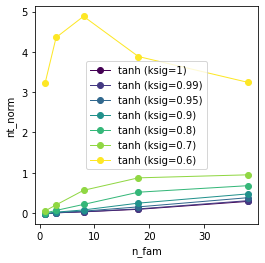

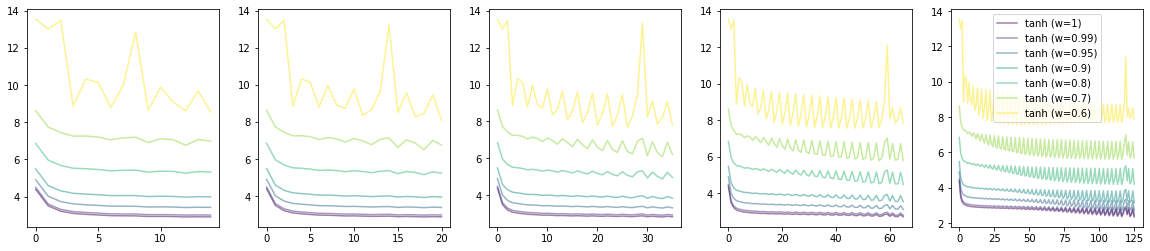

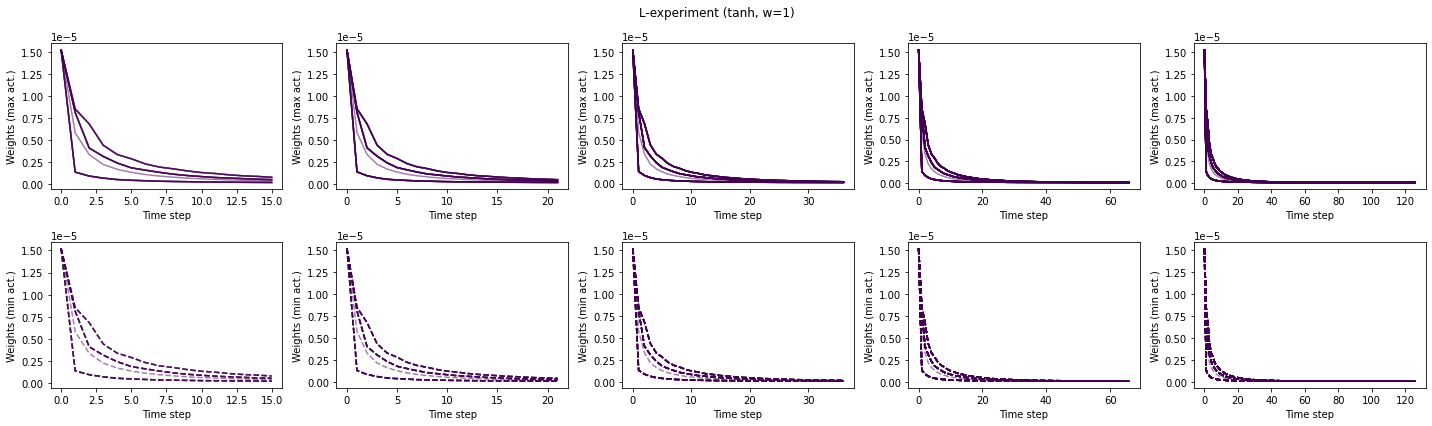

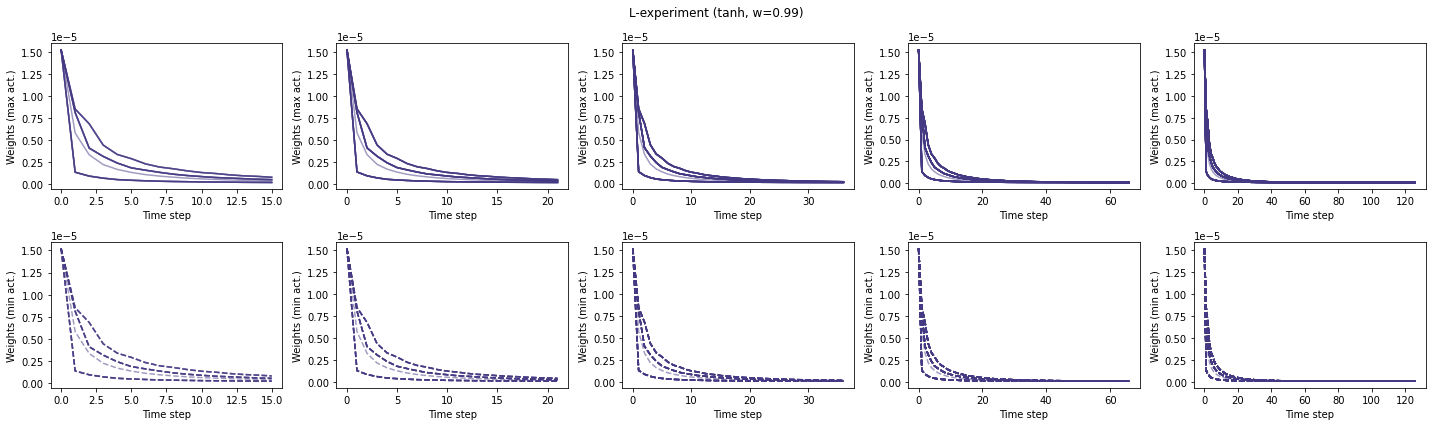

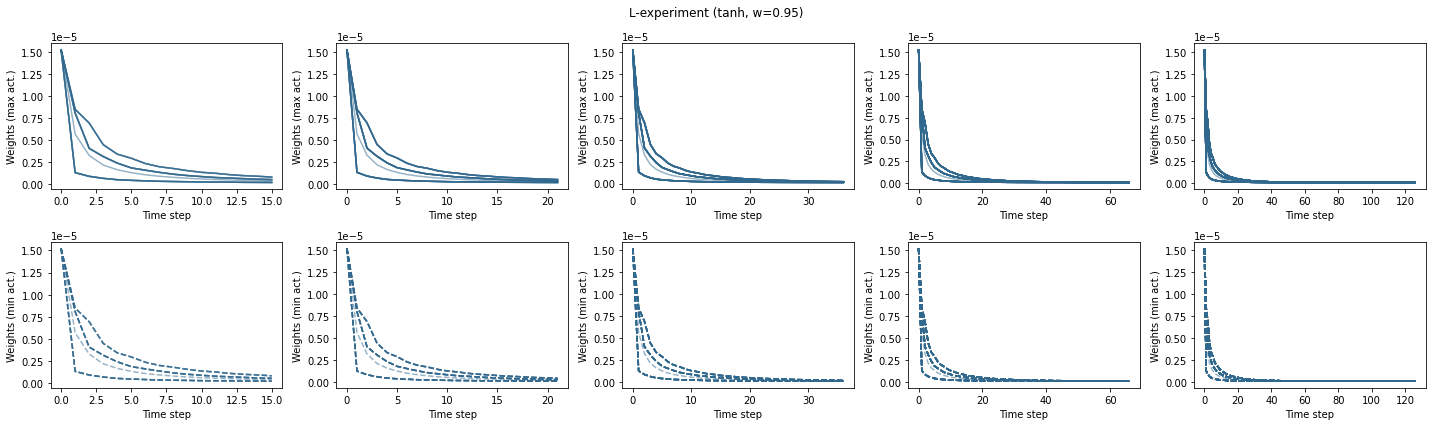

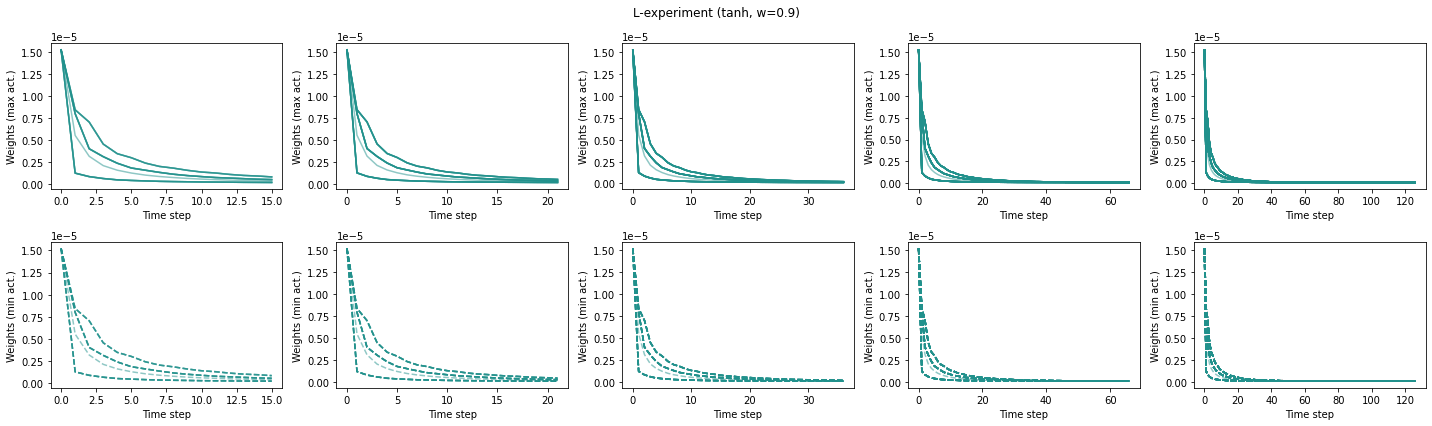

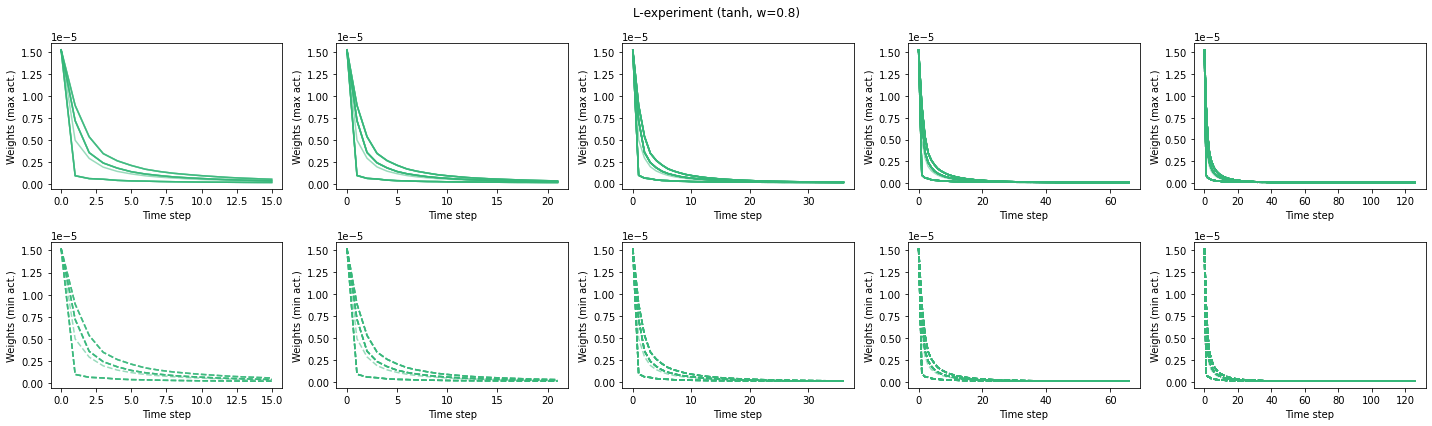

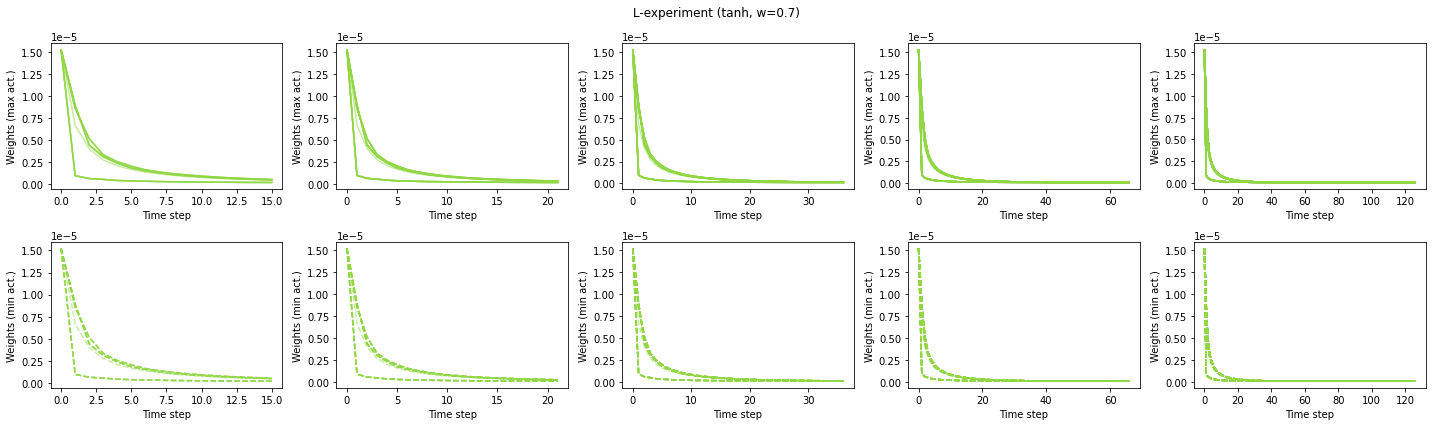

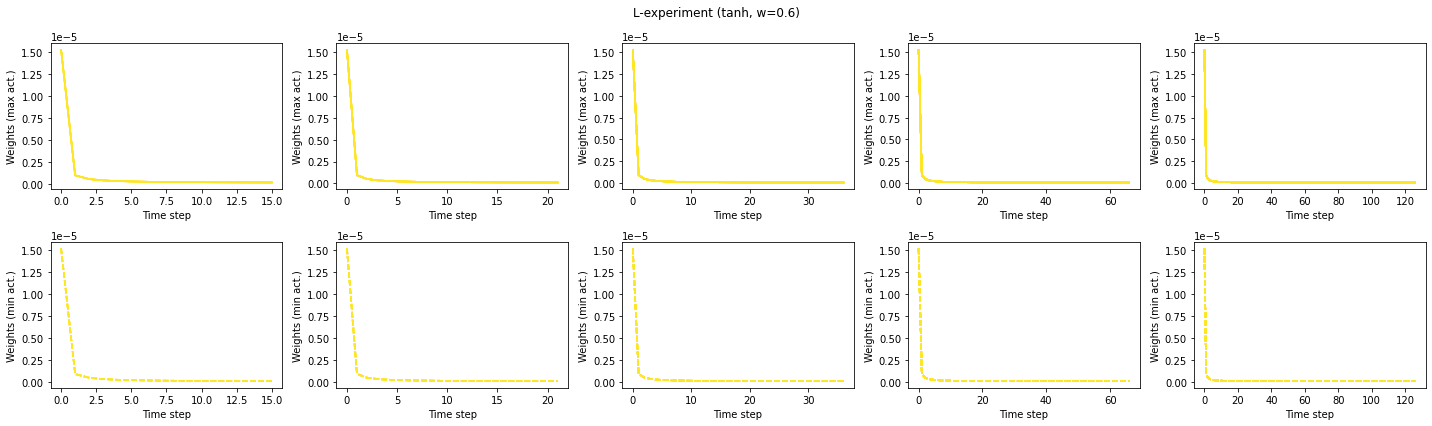

In [18]:
model_name = 'flr_snov'
var_input = 'n_fam'
var_output = 'nt_norm'

all_model = ['tanh', 'tanh', 'tanh', 'tanh', 'tanh','tanh','tanh']
all_ksig =[1, 0.99, 0.95, 0.9, 0.8, 0.7, 0.6]
cm = plt.get_cmap('viridis')
col_all = [cm(i) for i in np.linspace(0, 1, len(all_model))]

all_data = []
all_components = []
all_weights = []
all_resp = []
all_temp = []
for gid, (k_type, ksig) in enumerate(zip(all_model, all_ksig)):

    data, components, weights, resp, temp = run_exp('l',model_name,gid=0,k_type=k_type,ksig=ksig,inputs=None,params_input=None,k_params=None)
    all_data.append(data)
    all_components.append(components)
    all_weights.append(weights)
    all_resp.append(resp)
    all_temp.append(temp)

# Plot stats
f,ax = plt.subplots(1,1, figsize=(4,4))

for i, (model_i, ksig_i, col_i) in enumerate(zip(all_model, all_ksig, col_all)):
    data_nov, _ = sd.get_nov_response(all_data[i],var_input,get_stats=False) 

    ax.plot(data_nov[var_input], data_nov[var_output], marker='o', ls='-', c=col_i, lw=1,label=f'{model_i} (ksig={ksig_i})')

ax.set_xlabel(var_input)
ax.set_ylabel(var_output)
ax.legend()

# Plot details
conds = all_data[0][var_input].unique()
f, axl = plt.subplots(1,len(conds),figsize=(len(conds)*4,4))
for j, cond_j in enumerate(conds):
    for i, (model_i, ksig_i, col_i) in enumerate(zip(all_model, all_ksig, col_all)):
        data_ij = all_data[i].loc[all_data[i][var_input]==cond_j]
        axl[j].plot(data_ij['nt'], alpha=0.5, c=col_i, label=f'{model_i} (w={ksig_i})')
axl[-1].legend()

# Plot cumulative time steps + responsibilities
knum_all = all_components[0][0].shape[1]

for i, (model_i, ksig_i, col_i) in enumerate(zip(all_model, all_ksig, col_all)):

    f, axl = plt.subplots(2,len(conds),figsize=(len(conds)*4,3*2))

    for j in range(len(conds)): 
        min_act = np.argmin(all_components[i][j],axis=1)
        max_act = np.argmin(all_components[i][j],axis=1)

        for ma in max_act:
            axl[0,j].plot(all_weights[i][j][:,ma], ls='-', alpha=0.5, c=col_i)
        for mi in min_act:
            axl[1,j].plot(all_weights[i][j][:,mi], ls='--', alpha=0.5, c=col_i)
        axl[0,j].set_xlabel('Time step')
        axl[0,j].set_ylabel('Weights (max act.)')
        axl[1,j].set_xlabel('Time step')
        axl[1,j].set_ylabel('Weights (min act.)')

    f.suptitle(f'L-experiment ({model_i}, w={ksig_i})')
    f.tight_layout()

#### L-experiment (triangle)

0
1
2
3
4
0
1
2
3
4
0
1
2
3
4
0
1
2
3
4
0
1
2
3
4


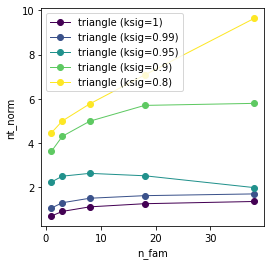

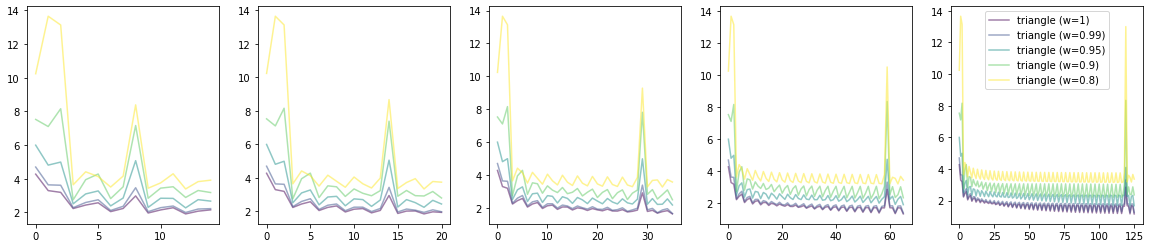

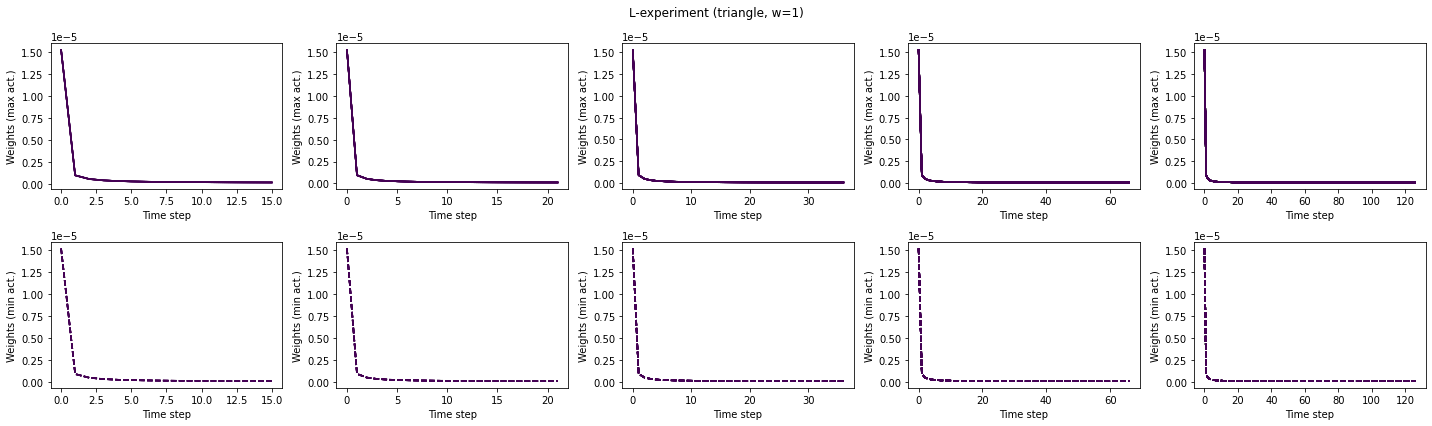

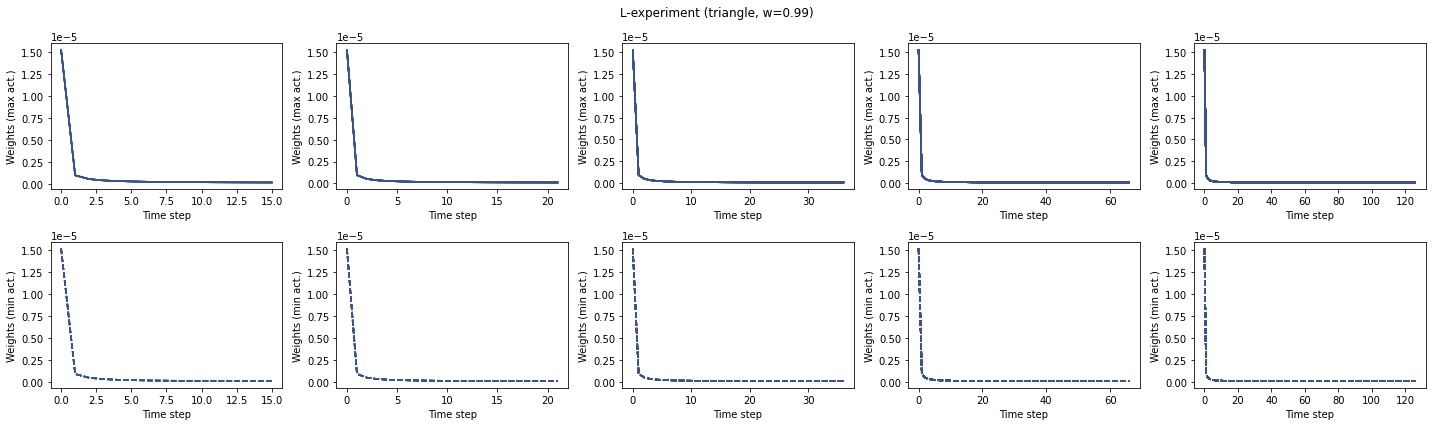

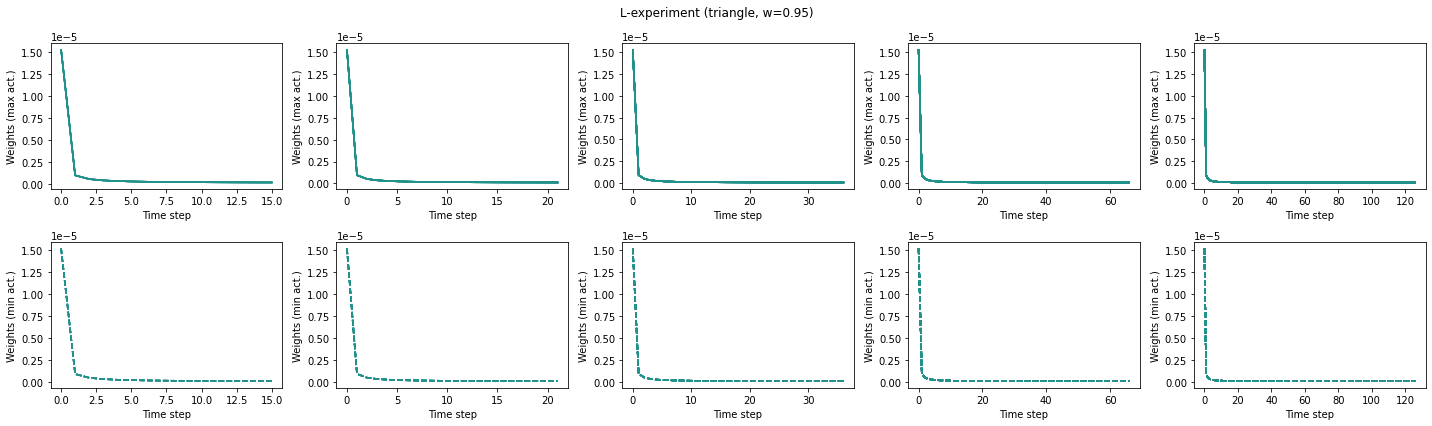

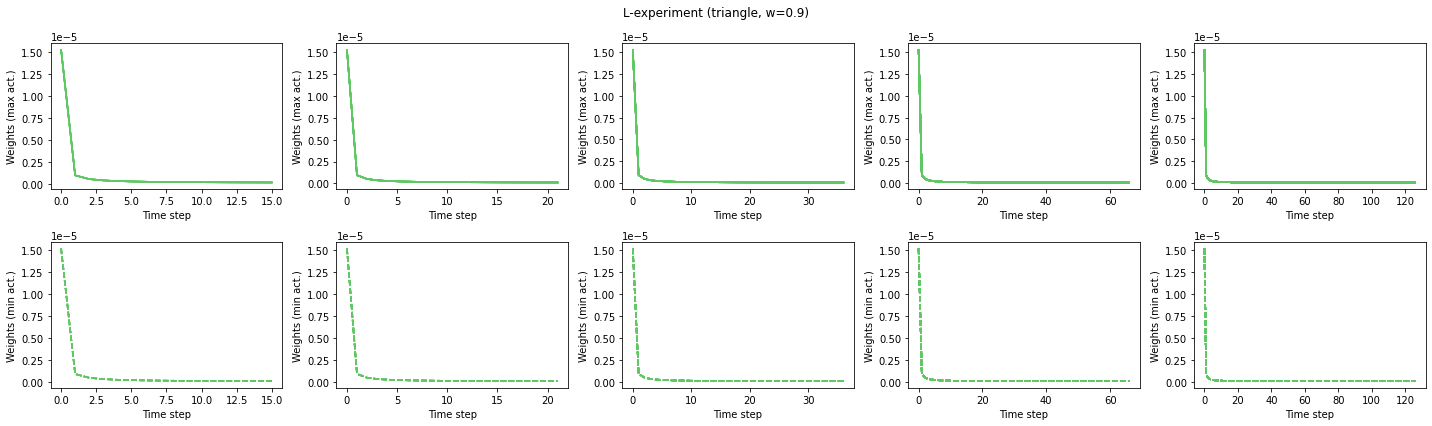

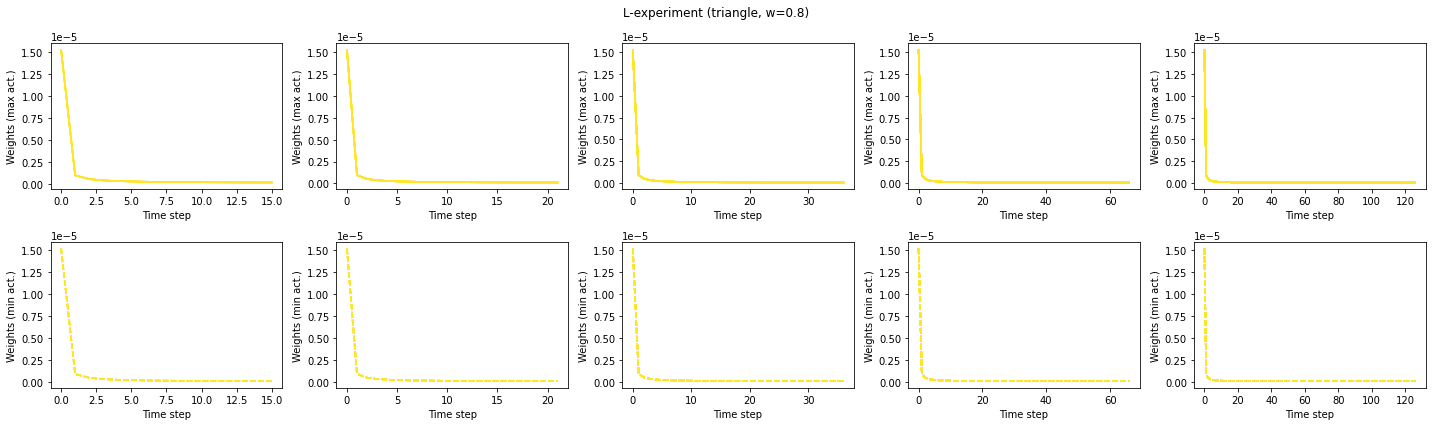

In [19]:
model_name = 'flr_snov'
var_input = 'n_fam'
var_output = 'nt_norm'

all_model = ['triangle', 'triangle', 'triangle','triangle', 'triangle']
all_ksig = [1, 0.99, 0.95, 0.9, 0.8]
cm = plt.get_cmap('viridis')
col_all = [cm(i) for i in np.linspace(0, 1, len(all_model))]

all_data = []
all_components = []
all_weights = []
all_resp = []
all_temp = []
for gid, (k_type, ksig) in enumerate(zip(all_model, all_ksig)):

    data, components, weights, resp, temp = run_exp('l',model_name,gid=0,k_type=k_type,ksig=ksig,inputs=None,params_input=None,k_params=None)
    all_data.append(data)
    all_components.append(components)
    all_weights.append(weights)
    all_resp.append(resp)
    all_temp.append(temp)

# Plot stats
f,ax = plt.subplots(1,1, figsize=(4,4))

for i, (model_i, ksig_i, col_i) in enumerate(zip(all_model, all_ksig, col_all)):
    data_nov, _ = sd.get_nov_response(all_data[i],var_input,get_stats=False) 

    ax.plot(data_nov[var_input], data_nov[var_output], marker='o', ls='-', c=col_i, lw=1,label=f'{model_i} (ksig={ksig_i})')

ax.set_xlabel(var_input)
ax.set_ylabel(var_output)
ax.legend()

# Plot details
conds = all_data[0][var_input].unique()
f, axl = plt.subplots(1,len(conds),figsize=(len(conds)*4,4))
for j, cond_j in enumerate(conds):
    for i, (model_i, ksig_i, col_i) in enumerate(zip(all_model, all_ksig, col_all)):
        data_ij = all_data[i].loc[all_data[i][var_input]==cond_j]
        axl[j].plot(data_ij['nt'], alpha=0.5, c=col_i, label=f'{model_i} (w={ksig_i})')
axl[-1].legend()

# Plot cumulative time steps + responsibilities
knum_all = all_components[0][0].shape[1]

for i, (model_i, ksig_i, col_i) in enumerate(zip(all_model, all_ksig, col_all)):

    f, axl = plt.subplots(2,len(conds),figsize=(len(conds)*4,3*2))

    for j in range(len(conds)): 
        min_act = np.argmin(all_components[i][j],axis=1)
        max_act = np.argmin(all_components[i][j],axis=1)

        for ma in max_act:
            axl[0,j].plot(all_weights[i][j][:,ma], ls='-', alpha=0.5, c=col_i)
        for mi in min_act:
            axl[1,j].plot(all_weights[i][j][:,mi], ls='--', alpha=0.5, c=col_i)
        axl[0,j].set_xlabel('Time step')
        axl[0,j].set_ylabel('Weights (max act.)')
        axl[1,j].set_xlabel('Time step')
        axl[1,j].set_ylabel('Weights (min act.)')

    f.suptitle(f'L-experiment ({model_i}, w={ksig_i})')
    f.tight_layout()


#### L-experiment (box)

0
1
2
3
4
0
1
2
3
4
0
1
2
3
4
0
1
2
3
4
0
1
2
3
4


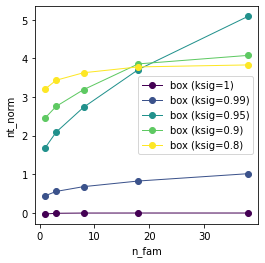

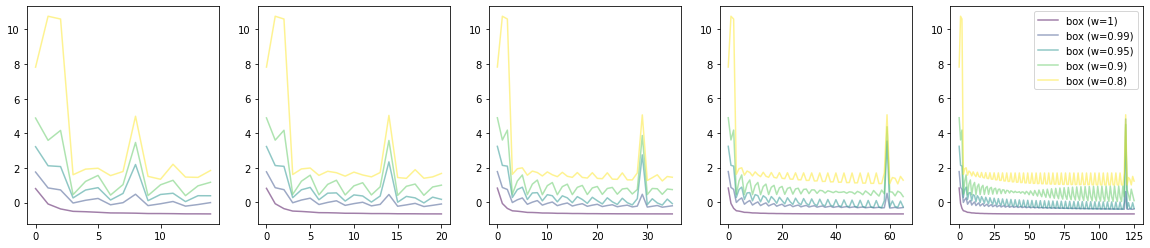

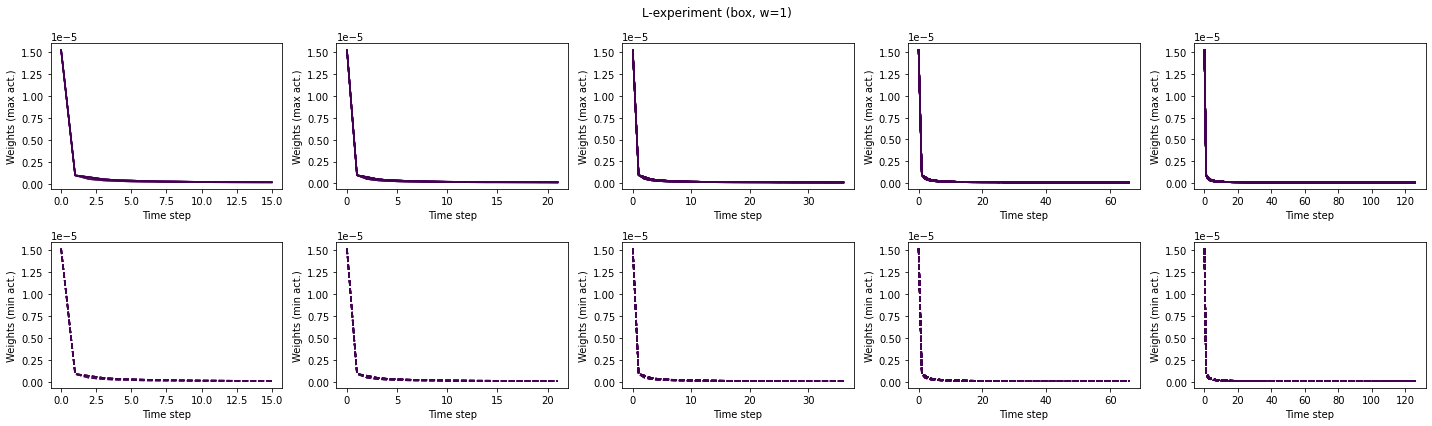

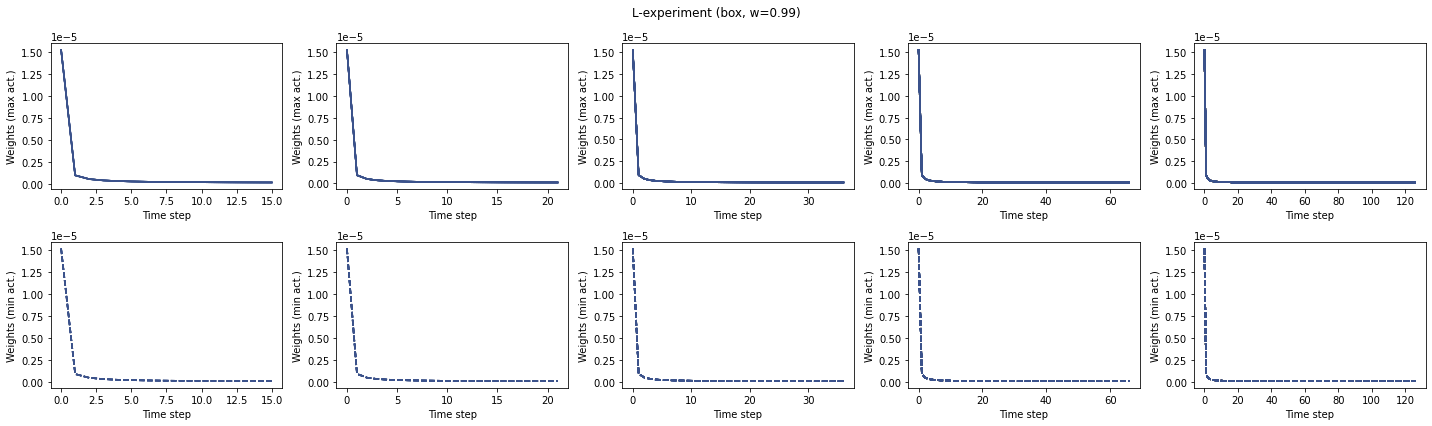

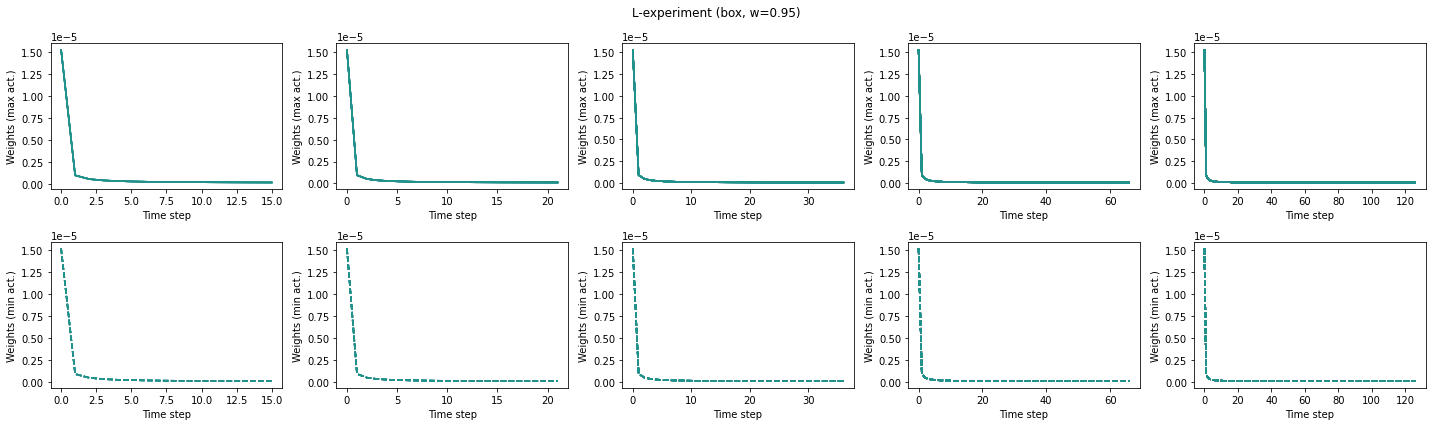

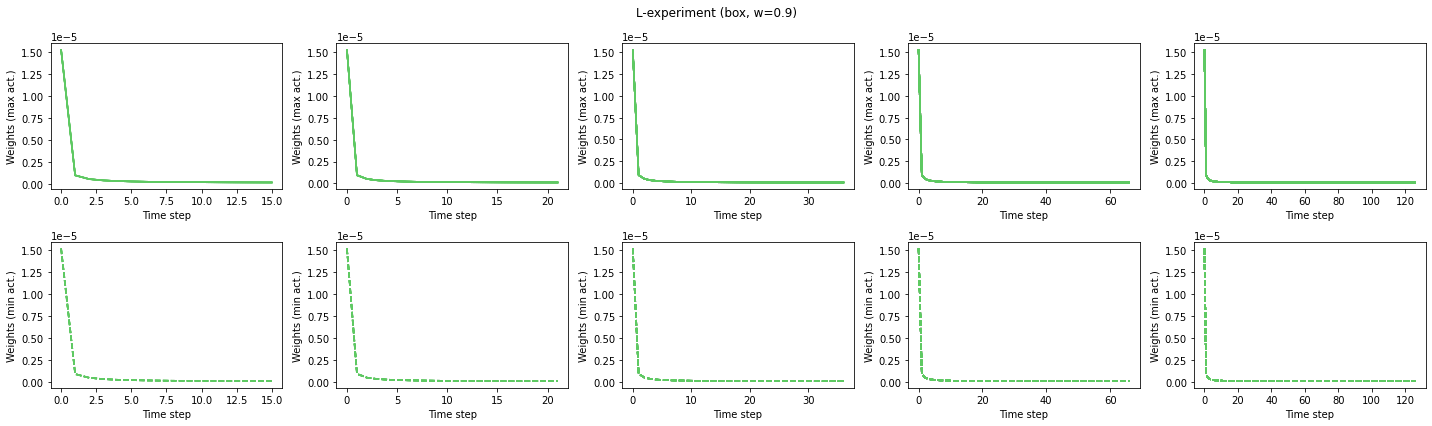

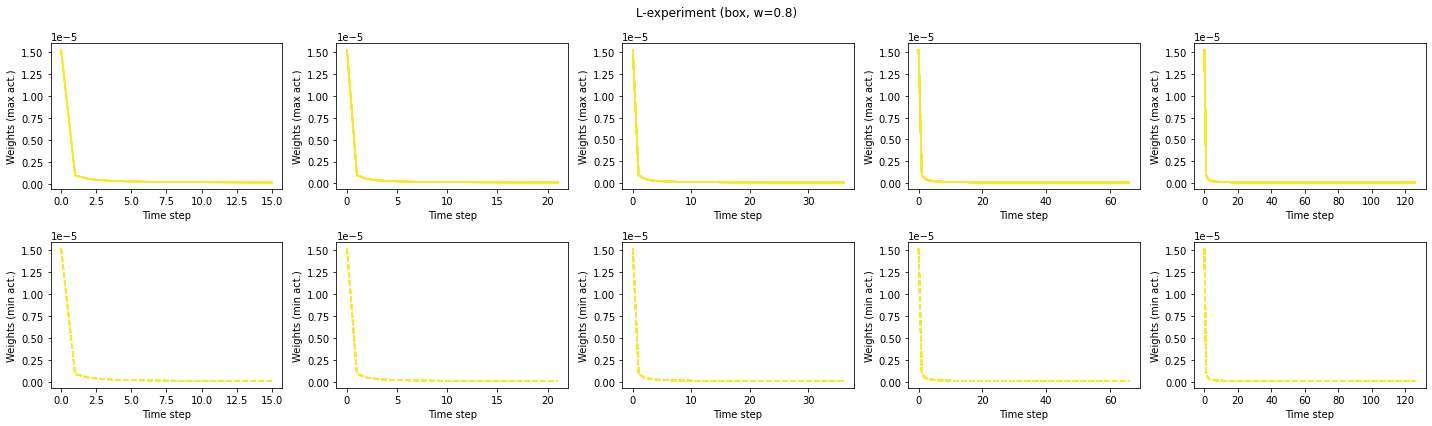

In [21]:
model_name = 'flr_snov'
var_input = 'n_fam'
var_output = 'nt_norm'

all_model = ['box', 'box', 'box', 'box', 'box']
all_ksig = [1, 0.99, 0.95, 0.9, 0.8]
cm = plt.get_cmap('viridis')
col_all = [cm(i) for i in np.linspace(0, 1, len(all_model))]

all_data = []
all_components = []
all_weights = []
all_resp = []
all_temp = []
for gid, (k_type, ksig) in enumerate(zip(all_model, all_ksig)):

    data, components, weights, resp, temp = run_exp('l',model_name,gid=0,k_type=k_type,ksig=ksig,inputs=None,params_input=None,k_params=None)
    all_data.append(data)
    all_components.append(components)
    all_weights.append(weights)
    all_resp.append(resp)
    all_temp.append(temp)

# Plot stats
f,ax = plt.subplots(1,1, figsize=(4,4))

for i, (model_i, ksig_i, col_i) in enumerate(zip(all_model, all_ksig, col_all)):
    data_nov, _ = sd.get_nov_response(all_data[i],var_input,get_stats=False) 

    ax.plot(data_nov[var_input], data_nov[var_output], marker='o', ls='-', c=col_i, lw=1,label=f'{model_i} (ksig={ksig_i})')

ax.set_xlabel(var_input)
ax.set_ylabel(var_output)
ax.legend()

# Plot details
conds = all_data[0][var_input].unique()
f, axl = plt.subplots(1,len(conds),figsize=(len(conds)*4,4))
for j, cond_j in enumerate(conds):
    for i, (model_i, ksig_i, col_i) in enumerate(zip(all_model, all_ksig, col_all)):
        data_ij = all_data[i].loc[all_data[i][var_input]==cond_j]
        axl[j].plot(data_ij['nt'], alpha=0.5, c=col_i, label=f'{model_i} (w={ksig_i})')
axl[-1].legend()

# Plot cumulative time steps + responsibilities
knum_all = all_components[0][0].shape[1]

for i, (model_i, ksig_i, col_i) in enumerate(zip(all_model, all_ksig, col_all)):

    f, axl = plt.subplots(2,len(conds),figsize=(len(conds)*4,3*2))

    for j in range(len(conds)): 
        min_act = np.argmin(all_components[i][j],axis=1)
        max_act = np.argmin(all_components[i][j],axis=1)

        for ma in max_act:
            axl[0,j].plot(all_weights[i][j][:,ma], ls='-', alpha=0.5, c=col_i)
        for mi in min_act:
            axl[1,j].plot(all_weights[i][j][:,mi], ls='--', alpha=0.5, c=col_i)
        axl[0,j].set_xlabel('Time step')
        axl[0,j].set_ylabel('Weights (max act.)')
        axl[1,j].set_xlabel('Time step')
        axl[1,j].set_ylabel('Weights (min act.)')

    f.suptitle(f'L-experiment ({model_i}, w={ksig_i})')
    f.tight_layout()


#### L'-experiment (all models)

0
1
2
3
4
5
6
0
1
2
3
4
5
6
0
1
2
3
4
5
6
0
1
2
3
4
5
6
0
1
2
3
4
5
6
0
1
2
3
4
5
6
0
1
2
3
4
5
6


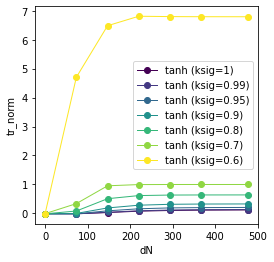

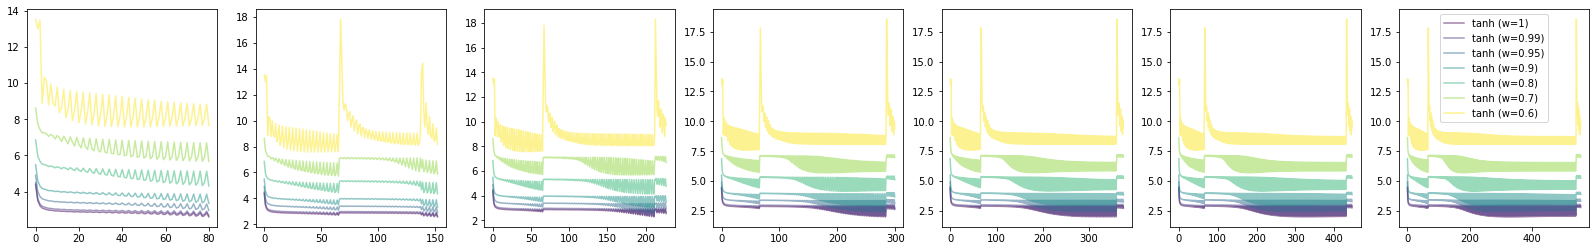

In [11]:
exp_name = 'lp'
var_input = 'dN'
var_output = 'tr_norm'

all_model = ['tanh', 'tanh', 'tanh', 'tanh', 'tanh','tanh','tanh']
all_ksig =[1, 0.99, 0.95, 0.9, 0.8, 0.7, 0.6]
run_and_plot_exp(all_model, all_ksig, exp_name, var_input, var_output)

0
1
2
3
4
5
6
0
1
2
3
4
5
6
0
1
2
3
4
5
6
0
1
2
3
4
5
6
0
1
2
3
4
5
6


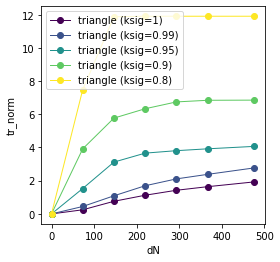

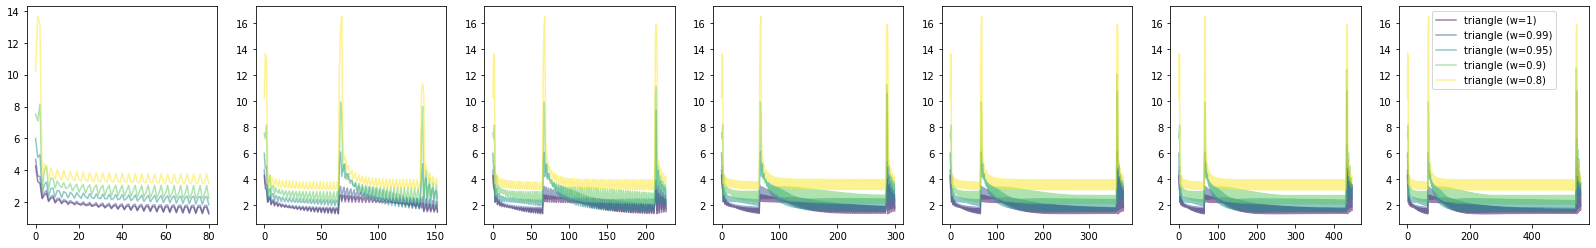

In [14]:
exp_name = 'lp'
var_input = 'dN'
var_output = 'tr_norm'

all_model = ['triangle', 'triangle', 'triangle','triangle', 'triangle']
all_ksig = [1, 0.99, 0.95, 0.9, 0.8]
run_and_plot_exp(all_model, all_ksig, exp_name, var_input, var_output)

0
1
2
3
4
5
6
0
1
2
3
4
5
6
0
1
2
3
4
5
6
0
1
2
3
4
5
6
0
1
2
3
4
5
6


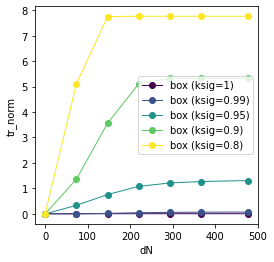

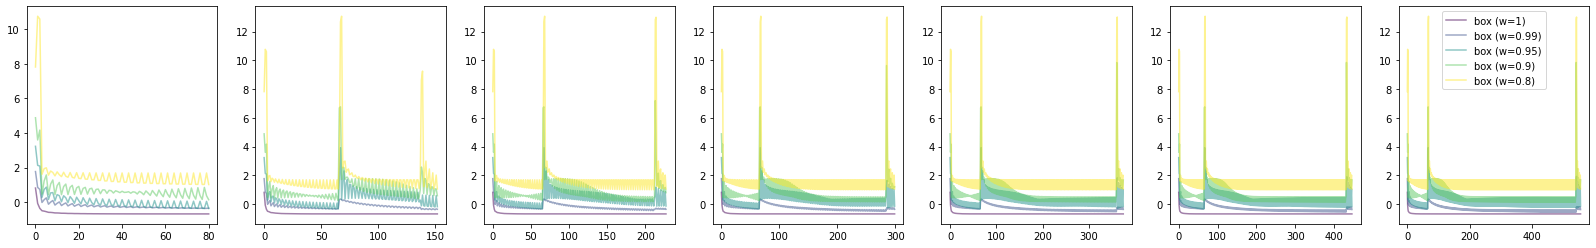

In [15]:
all_model = ['box', 'box', 'box', 'box', 'box']
all_ksig = [1, 0.99, 0.95, 0.9, 0.8]
run_and_plot_exp(all_model, all_ksig, exp_name, var_input, var_output)

#### M-experiment (all models)

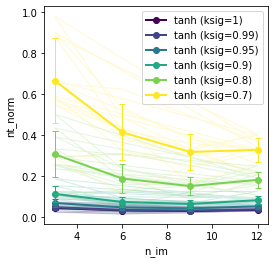

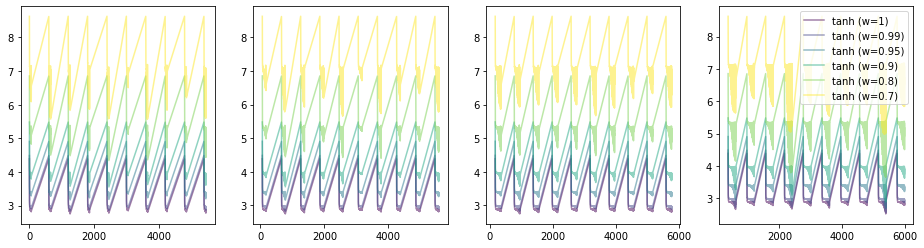

In [26]:
exp_name = 'm'
var_input = 'n_im'
var_output = 'nt_norm'

# all_model = ['tanh', 'tanh', 'tanh', 'tanh', 'tanh','tanh','tanh']
# all_ksig =[1, 0.99, 0.95, 0.9, 0.8, 0.7, 0.6]
all_model = ['tanh', 'tanh', 'tanh','tanh','tanh','tanh']
all_ksig =[1, 0.99, 0.95, 0.9, 0.8, 0.7]
# all_model = ['tanh', 'tanh', 'tanh','tanh']
# all_ksig =[1, 0.99, 0.95, 0.9]
# run_and_plot_exp(all_model, all_ksig, exp_name, var_input, var_output, num_sim=10)
load_and_plot_exp(all_model, all_ksig, exp_name, var_input, var_output, num_sim=10)




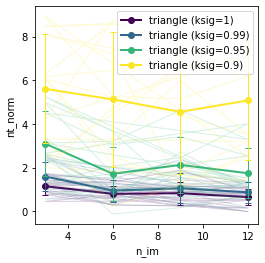

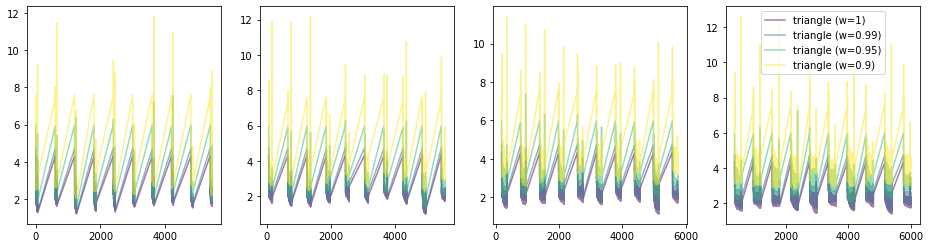

In [30]:
exp_name = 'm'
var_input = 'n_im'
var_output = 'nt_norm'

# all_model = ['triangle', 'triangle', 'triangle','triangle', 'triangle']
# all_ksig = [1, 0.99, 0.95, 0.9, 0.8]
# run_and_plot_exp(all_model, all_ksig, exp_name, var_input, var_output, num_sim=10)

all_model = ['triangle', 'triangle', 'triangle', 'triangle']
all_ksig = [1, 0.99, 0.95, 0.9]
load_and_plot_exp(all_model, all_ksig, exp_name, var_input, var_output, num_sim=10)

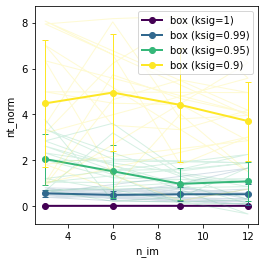

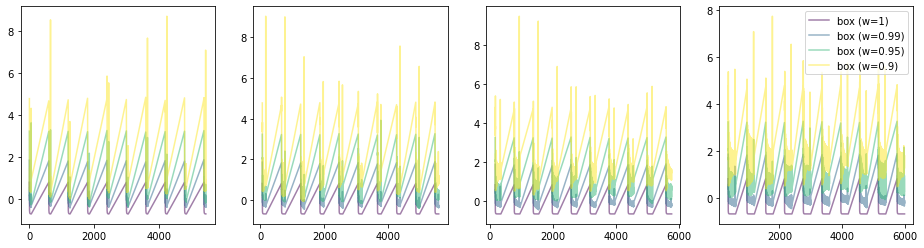

In [32]:
exp_name = 'm'
var_input = 'n_im'
var_output = 'nt_norm'

# all_model = ['box', 'box', 'box', 'box', 'box']
# all_ksig = [1, 0.99, 0.95, 0.9, 0.8]
# run_and_plot_exp(all_model, all_ksig, exp_name, var_input, var_output, num_sim=10)

all_model = ['box', 'box', 'box', 'box']
all_ksig = [1, 0.99, 0.95, 0.9]
load_and_plot_exp(all_model, all_ksig, exp_name, var_input, var_output, num_sim=10)

# Robustness without refitting of novelty model

### Get width of 'id' component distribution

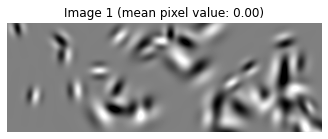

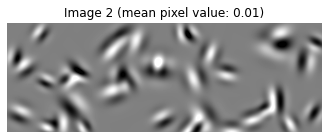

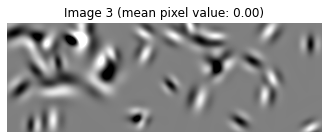

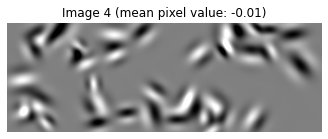

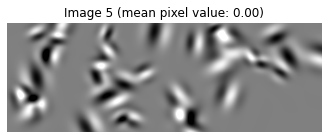

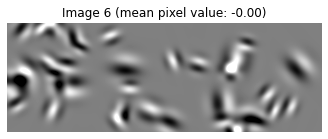

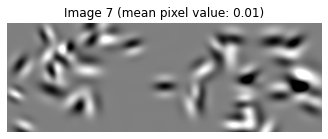

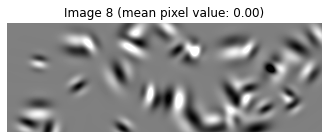

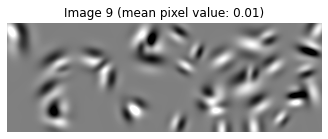

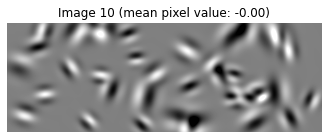

In [10]:
im_params_all, im_all = gen_images(10, seed=98765)

for i in range(im_all.shape[0]):
    plt.figure(figsize=(2* im_all.shape[2] / im_all.shape[1],2))
    plt.imshow(im_all[i,:,:], cmap='gray', vmin=-1, vmax=1)
    plt.title(f'Image {i+1} (mean pixel value: {np.mean(im_all[i,:,:]):.2f})')
    plt.axis('off')
    plt.show()  # Display each image one by one

In [11]:
kmat_id_all = []
klen_id_all = []
klim_id_all = []
klim_simple_id_all = []
for i in range(im_all.shape[0]):
    model_id = make_model(k_params_ext={'k_type': 'id', 'ksig':1}, kwargs_ext={}, input_params_ext={}, save_path_i=None)
    kmat_id, klen_id = get_model_activations(model_id[0], model_id[1], im_all[i,:,:][None,:,:])
    klim_id = [np.min(kmat_id), np.max(kmat_id)]
    klim_simple_id = [np.min(kmat_id[:klen_id[0]*klen_id[2]]), np.max(kmat_id[:klen_id[0]*klen_id[2]])]
    kmat_id_all.append(kmat_id)
    klen_id_all.append(klen_id)
    klim_id_all.append(klim_id)
    klim_simple_id_all.append(klim_simple_id)

klim_id_all = np.array(klim_id_all)
klim_simple_id_all = np.array(klim_simple_id_all)

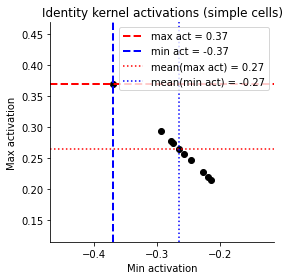

In [12]:
f,ax = plt.subplots(1,1, figsize=(4,4))
ax.axhline(y=np.max(klim_simple_id_all[:,1]), color='r', linestyle='--', lw=2, label=f'max act = {np.max(klim_simple_id_all[:,1]):.2f}')
ax.axvline(x=np.min(klim_simple_id_all[:,0]), color='b', linestyle='--', lw=2, label=f'min act = {np.min(klim_simple_id_all[:,0]):.2f}')

ax.axhline(y=np.mean(klim_simple_id_all[:,1]), color='r', linestyle=':', lw=1.5, label=f'mean(max act) = {np.mean(klim_simple_id_all[:,1]):.2f}')
ax.axvline(x=np.mean(klim_simple_id_all[:,0]), color='b', linestyle=':', lw=1.5, label=f'mean(min act) = {np.mean(klim_simple_id_all[:,0]):.2f}')
ax.scatter(klim_simple_id_all[:,0],klim_simple_id_all[:,1], c='k')
ax.set_xlabel('Min activation')
ax.set_ylabel('Max activation')
ax.set_title('Identity kernel activations (simple cells)')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim([klim_simple_id_all[:,0].min()-0.1, klim_simple_id_all[:,0].max()+0.1])
ax.set_ylim([klim_simple_id_all[:,1].min()-0.1, klim_simple_id_all[:,1].max()+0.1])
f.tight_layout()

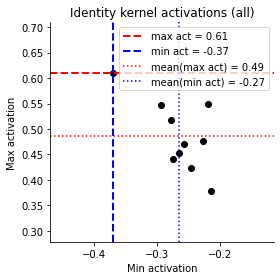

In [13]:
f,ax = plt.subplots(1,1, figsize=(4,4))
ax.axhline(y=np.max(klim_id_all[:,1]), color='r', linestyle='--', lw=2, label=f'max act = {np.max(klim_id_all[:,1]):.2f}')
ax.axvline(x=np.min(klim_id_all[:,0]), color='b', linestyle='--', lw=2, label=f'min act = {np.min(klim_id_all[:,0]):.2f}')

ax.axhline(y=np.mean(klim_id_all[:,1]), color='r', linestyle=':', lw=1.5, label=f'mean(max act) = {np.mean(klim_id_all[:,1]):.2f}')
ax.axvline(x=np.mean(klim_id_all[:,0]), color='b', linestyle=':', lw=1.5, label=f'mean(min act) = {np.mean(klim_id_all[:,0]):.2f}')
ax.scatter(klim_id_all[:,0],klim_id_all[:,1], c='k')
ax.set_xlabel('Min activation')
ax.set_ylabel('Max activation')
ax.set_title('Identity kernel activations (all)')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim([klim_id_all[:,0].min()-0.1, klim_id_all[:,0].max()+0.1])
ax.set_ylim([klim_id_all[:,1].min()-0.1, klim_id_all[:,1].max()+0.1])
f.tight_layout()

### Robustness plot (flr)

In [6]:
# Specify models 
model_name    = 'snov-complex-fr' # model whose robustness is tested
set_testmodel = 7 if 'fr' in model_name else 5 # set of the model whose robustness is tested
type_update   = model_name.split('-')[-1]
compare_model = ['cnov_leaky', 'cnov_fr'] # model to compare with

# Set plot labels
label_test_model    = 'Sim.-based (flr)'
label_compare_model = ['Count-based (leaky)', 'Count-based (fr)'] # labels for the models to compare with
label_opt_meas      = 'Train MSE' # label for the optimality measure used in the grid search

# Load fitted model parameters
path_opt = '/Volumes/lcncluster/becker/RL_reward_novelty/data/2025_05_grid_search_new/'

measure_fit       = 'train_mse'
sampling_type_fit = 'normal'
drop_type_fit     = 'none' 
weighting_fit     = 'equal-samples' # 'equal-samples', 'equal-exp', 'none' (not available for bootstrap)

file_opt = f'best_params_{measure_fit}_{sampling_type_fit}'
if 'jackknife' in sampling_type_fit or 'loo' in sampling_type_fit:
    file_opt += f'-drop-{drop_type_fit}'
if weighting_fit!='none':
    file_opt += f'-{weighting_fit}'

best_params_fr      = json.load(open(os.path.join(path_opt, f'data_for_figures/{file_opt}-fr.json')))
best_params_leaky   = json.load(open(os.path.join(path_opt, f'data_for_figures/{file_opt}-leaky.json')))
best_params_raw = best_params_fr + best_params_leaky
best_params     = [bp for bp in best_params_raw if bp[0]==model_name][0][1]
compare_params  = [[bp for bp in best_params_raw if bp[0]==compare_model[i]][0][1] for i in range(len(compare_model))]

# For each component shape, load robustness grid
set_name    = 7
k_types     = ['box','tanh','triangle']
color_comps = ['C0','C1','C2']
sampling_type   = 'normal'
weighting       = 'equal-samples'

pred = []

path_robustness = f'/Volumes/lcncluster/becker/RL_reward_novelty/data/2025_07_robustness_shape_width/snov-complex-fr_set{set_name}_sep/combined_data/'

grid_file = os.path.join(path_robustness, f'grid_{sampling_type}-{weighting}.csv')

grid = pd.read_csv(grid_file)
grid = grid.sort_values(by=['k_type', 'ksig'])


In [20]:
grid.loc[grid['k_type']=='triangle']

,Unnamed: 0.1,ksig,cdens,knum,type_complex,k_alph,num_complex,grid_id,save_path,grid_id_old,grid_id_old2,k_type,Unnamed: 0,coef,shift,train_rss,train_mse,train_nmse
16,16,0.700,8.0,2.0,8,0.4,2.666667,16,NaN,0,0,triangle,NaN,NaN,NaN,NaN,NaN,NaN
17,17,0.750,8.0,2.0,8,0.4,2.666667,17,NaN,1,1,triangle,NaN,NaN,NaN,NaN,NaN,NaN
77,5,0.775,8.0,2.0,8,0.4,2.666667,77,NaN,5,5,triangle,5.0,NaN,NaN,NaN,NaN,NaN
18,18,0.800,8.0,2.0,8,0.4,2.666667,18,NaN,2,2,triangle,NaN,0.000264,0.071121,0.000223,0.000011,0.025487
76,4,0.825,8.0,2.0,8,0.4,2.666667,76,NaN,4,4,triangle,4.0,0.000283,0.071127,0.000217,0.000011,0.024825
19,19,0.850,8.0,2.0,8,0.4,2.666667,19,NaN,3,3,triangle,NaN,0.000347,0.071015,0.000210,0.000011,0.024002
75,3,0.875,8.0,2.0,8,0.4,2.666667,75,NaN,3,3,triangle,3.0,0.000633,0.069893,0.000189,0.000009,0.021634
20,20,0.900,8.0,2.0,8,0.4,2.666667,20,NaN,4,4,triangle,NaN,0.000971,0.068913,0.000176,0.000009,0.020079
74,2,0.910,8.0,2.0,8,0.4,2.666667,74,NaN,2,2,triangle,2.0,0.001154,0.068427,0.000182,0.000009,0.020728
73,1,0.920,8.0,2.0,8,0.4,2.666667,73,NaN,1,1,triangle,1.0,0.001581,0.067103,0.000159,0.000008,0.018183


In [23]:
grid.loc[grid['k_type']=='triangle','ksig'].unique()

array([0.7  , 0.75 , 0.775, 0.8  , 0.825, 0.85 , 0.875, 0.9  , 0.91 ,
       0.92 , 0.93 , 0.95 , 0.97 , 0.99 , 1.05 , 1.1  , 1.15 , 1.2  ,
       1.25 , 1.3  , 1.35 , 1.4  , 1.45 , 1.5  ])

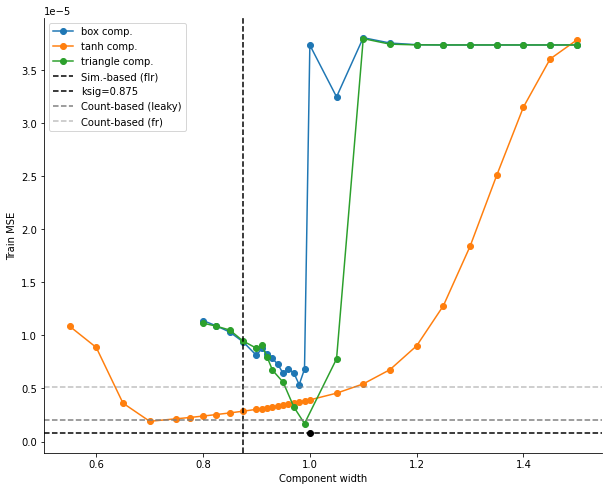

In [28]:
# Plot robustness grid
f, ax = plt.subplots(1, 1, figsize=(10, 8))
for i in range(len(k_types)):
    grid_i = grid.loc[grid['k_type']==k_types[i]]
    ax.plot(grid_i['ksig'], grid_i[measure_fit], marker='o', ls='-', c=color_comps[i], label=f'{k_types[i]} comp.')
ax.axhline(y=best_params[measure_fit], c='k', ls='--', label=label_test_model)
ax.axvline(x=0.875, c='k', ls='--', label='ksig=0.875')
ax.scatter(1,best_params[measure_fit], c='k', marker='o')

alph_compare = 1 if len(compare_params)==1 else np.linspace(0.5, 1, len(compare_params))[::-1]
for i in range(len(compare_params)):
    ax.axhline(y=compare_params[i][measure_fit], c='grey', ls='--', alpha=alph_compare[i], label=label_compare_model[i])
ax.set_xlabel('Component width')
ax.set_ylabel(label_opt_meas)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

In [ ]:
# Plot stats for different widths
ksig_cols = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5']
ksig_plot = [0.8, 0.9, 0.95, 1.05, 1.1, 1.2]

ylim = [[0,0.05],[0,0.05],[0,0.06],[0.04,0.1]]

# Load Homann data
homann_data = load_homann.load_exp_homann(cluster=False)
homann_lstd = load_homann.load_exp_homann(cluster=False,type='lowerstd')
homann_ustd = load_homann.load_exp_homann(cluster=False,type='upperstd')
# Set novelty response for L'=0 to zero
homann_data[1][1][0] = 0 #homann_data[1][1][0]-delta_homann
homann_lstd[1][1][0] = 0 #homann_lstd[1][1][0]-delta_homann
homann_ustd[1][1][0] = 0 #homann_ustd[1][1][0]-delta_homann

# Load best snov model 
gid_best = int(best_params['grid_id'])
path_best_sim = os.path.join(path_opt,f'{model_name}_set{set_testmodel}_sep/combined_data/grid_{gid_best}/')
pred_best = []
for i_exp, (exp_name, exp_var, exp_out) in enumerate(zip(['l', 'lp', 'm', 'm_steady'],['n_fam', 'dN', 'n_im', 'n_im'],['nt_norm', 'tr_norm', 'nt_norm', 'steady'])):
    pred_best_exp = pd.read_csv(os.path.join(path_best_sim,f'pred_{exp_name}_{weighting}.csv'))
    pred_best.append(pred_best_exp)

# Load control models (cnov_leaky, cnov_fr)
path_control = '/Users/sbecker/Projects/RL_reward_novelty/data/2025_05_grid_search_new/'
pred_ic_all = []
for ic in range(len(compare_model)):
    gid_ic = int(compare_params[ic]['grid_id'])
    path_compare_ic = os.path.join(path_control, f'{compare_model[ic]}/grid_{gid_ic}/')
    pred_ic = []
    for i_exp, (exp_name, exp_var, exp_out) in enumerate(zip(['l', 'lp', 'm', 'm_steady'],['n_fam', 'dN', 'n_im', 'n_im'],['nt_norm', 'tr_norm', 'nt_norm', 'steady'])):
        pred_ic_exp = pd.read_csv(os.path.join(path_compare_ic, f'pred_{exp_name}_{weighting}.csv'))
        pred_ic.append(pred_ic_exp)
    pred_ic_all.append(pred_ic)

for i in range(len(ksig_plot)):
    f, ax = plt.subplots(1, 4, figsize=(12, 4))

    # Load + plot simulation data of robustness simulation
    gid_i = []
    for j in range(len(k_types)):
        gid_ij = int(grid.loc[(grid['ksig']==ksig_plot[i]) & (grid['k_type']==k_types[j]),'grid_id'].values[0])
        gid_i.append(gid_ij)

        pred_ij = []
        for i_exp, (exp_name, exp_var, exp_out) in enumerate(zip(['l', 'lp', 'm', 'm_steady'],['n_fam', 'dN', 'n_im', 'n_im'],['nt_norm', 'tr_norm', 'nt_norm', 'steady'])):
            pred_ij_exp = pd.read_csv(os.path.join(path_robustness, f'grid_{gid_ij}/pred_{exp_name}_{weighting}.csv'))
            pred_ij.append(pred_ij_exp)
            ax[i_exp].plot(homann_data[i_exp][0], pred_ij_exp[exp_out], marker='o', ls='-', c=ksig_cols[i], label=f'{k_types[j]} comp.', alpha=0.5)
        
    # Plot Homann data + best snov model + control modesl
    for i_exp, (exp_name, exp_var, exp_out) in enumerate(zip(['l', 'lp', 'm', 'm_steady'],['n_fam', 'dN', 'n_im', 'n_im'],['nt_norm', 'tr_norm', 'nt_norm', 'steady'])):
        ax[i_exp].plot(homann_data[i_exp][0], homann_data[i_exp][1], 'o-', c='k', label='Homann data')
        ax[i_exp].errorbar(x=homann_data[i_exp][0], y=homann_data[i_exp][1], yerr=[homann_data[i_exp][1]-homann_lstd[i_exp][1],homann_ustd[i_exp][1]-homann_data[i_exp][1]], color='k')

        ax[i_exp].plot(homann_data[i_exp][0], pred_best[i_exp][exp_out], marker='o', ls='-', c='darkgreen', label=label_test_model)

        for ic in range(len(compare_model)):
            ax[i_exp].plot(homann_data[i_exp][0], pred_ic_all[ic][i_exp][exp_out], marker='o', ls='-', c='grey', label=label_compare_model[ic], alpha=alph_compare[ic] if len(compare_model)>1 else 1)
        
        # Set axis limits
        # ax[i_exp].set_ylim(ylim[i_exp])
    
    for i_exp, (xl_exp, yl_exp) in enumerate(zip(['$L$','$L\'$','$M$','$M$'], ['$\\Delta N$','$\\Delta N$','$\\Delta N$','$N_{\\infty}$'])):                    
        ax[i_exp].set_xlabel(xl_exp)
        ax[i_exp].set_ylabel(yl_exp)
        ax[i_exp].spines[['top', 'right']].set_visible(False)

    ax[0].legend(loc='lower right', fontsize=8)
    f.suptitle(f'Component width = {ksig_plot[i]}')
    f.tight_layout()

Current path:/Users/sbecker/Projects/RL_reward_novelty/src/scripts/gabor_kernels/grid_search_new
Current path:/Users/sbecker/Projects/RL_reward_novelty/src/scripts/gabor_kernels/grid_search_new
Current path:/Users/sbecker/Projects/RL_reward_novelty/src/scripts/gabor_kernels/grid_search_new
Current path:/Users/sbecker/Projects/RL_reward_novelty/src/scripts/gabor_kernels/grid_search_new
Current path:/Users/sbecker/Projects/RL_reward_novelty/src/scripts/gabor_kernels/grid_search_new
Current path:/Users/sbecker/Projects/RL_reward_novelty/src/scripts/gabor_kernels/grid_search_new
Current path:/Users/sbecker/Projects/RL_reward_novelty/src/scripts/gabor_kernels/grid_search_new
Current path:/Users/sbecker/Projects/RL_reward_novelty/src/scripts/gabor_kernels/grid_search_new
Current path:/Users/sbecker/Projects/RL_reward_novelty/src/scripts/gabor_kernels/grid_search_new


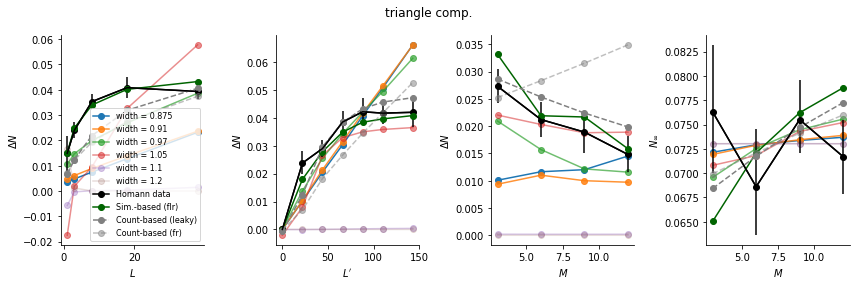

In [24]:
# Plot stats for different widths
ksig_cols = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5']
# ksig_plot = [0.8, 0.9, 0.95, 1.05, 1.1, 1.2]
ksig_plot = [0.875, 0.91, 0.97, 1.05, 1.1, 1.2]
ksig_alph = np.linspace(0.2, 1, len(ksig_plot))[::-1]

ylim = [[0,0.05],[0,0.05],[0,0.06],[0.04,0.1]]

# Load Homann data
homann_data = load_homann.load_exp_homann(cluster=False)
homann_lstd = load_homann.load_exp_homann(cluster=False,type='lowerstd')
homann_ustd = load_homann.load_exp_homann(cluster=False,type='upperstd')
# Set novelty response for L'=0 to zero
homann_data[1][1][0] = 0 #homann_data[1][1][0]-delta_homann
homann_lstd[1][1][0] = 0 #homann_lstd[1][1][0]-delta_homann
homann_ustd[1][1][0] = 0 #homann_ustd[1][1][0]-delta_homann

# Load best snov model 
gid_best = int(best_params['grid_id'])
path_best_sim = os.path.join(path_opt,f'{model_name}_set{set_testmodel}_sep/combined_data/grid_{gid_best}/')
pred_best = []
for i_exp, (exp_name, exp_var, exp_out) in enumerate(zip(['l', 'lp', 'm', 'm_steady'],['n_fam', 'dN', 'n_im', 'n_im'],['nt_norm', 'tr_norm', 'nt_norm', 'steady'])):
    pred_best_exp = pd.read_csv(os.path.join(path_best_sim,f'pred_{exp_name}_{weighting}.csv'))
    pred_best.append(pred_best_exp)

# Load control models (cnov_leaky, cnov_fr)
path_control = '/Users/sbecker/Projects/RL_reward_novelty/data/2025_05_grid_search_new/'
pred_ic_all = []
for ic in range(len(compare_model)):
    gid_ic = int(compare_params[ic]['grid_id'])
    path_compare_ic = os.path.join(path_control, f'{compare_model[ic]}/grid_{gid_ic}/')
    pred_ic = []
    for i_exp, (exp_name, exp_var, exp_out) in enumerate(zip(['l', 'lp', 'm', 'm_steady'],['n_fam', 'dN', 'n_im', 'n_im'],['nt_norm', 'tr_norm', 'nt_norm', 'steady'])):
        pred_ic_exp = pd.read_csv(os.path.join(path_compare_ic, f'pred_{exp_name}_{weighting}.csv'))
        pred_ic.append(pred_ic_exp)
    pred_ic_all.append(pred_ic)

for j in range(2,len(k_types)):
    f, ax = plt.subplots(1, 4, figsize=(12, 4))

    # Load + plot simulation data of robustness simulation
    gid_j = []
    for i in range(len(ksig_plot)):
        gid_ij = int(grid.loc[(grid['ksig']==ksig_plot[i]) & (grid['k_type']==k_types[j]),'grid_id'].values[0])
        gid_j.append(gid_ij)

        pred_ij = []
        for i_exp, (exp_name, exp_var, exp_out) in enumerate(zip(['l', 'lp', 'm', 'm_steady'],['n_fam', 'dN', 'n_im', 'n_im'],['nt_norm', 'tr_norm', 'nt_norm', 'steady'])):
            pred_ij_exp = pd.read_csv(os.path.join(path_robustness, f'grid_{gid_ij}/pred_{exp_name}_{weighting}.csv'))
            pred_ij.append(pred_ij_exp)
            ax[i_exp].plot(homann_data[i_exp][0], pred_ij_exp[exp_out], marker='o', ls='-', c=ksig_cols[i], alpha=ksig_alph[i], label=f'width = {ksig_plot[i]}')
        
    # Plot Homann data + best snov model + control modesl
    for i_exp, (exp_name, exp_var, exp_out) in enumerate(zip(['l', 'lp', 'm', 'm_steady'],['n_fam', 'dN', 'n_im', 'n_im'],['nt_norm', 'tr_norm', 'nt_norm', 'steady'])):
        ax[i_exp].plot(homann_data[i_exp][0], homann_data[i_exp][1], 'o-', c='k', label='Homann data')
        ax[i_exp].errorbar(x=homann_data[i_exp][0], y=homann_data[i_exp][1], yerr=[homann_data[i_exp][1]-homann_lstd[i_exp][1],homann_ustd[i_exp][1]-homann_data[i_exp][1]], color='k')

        ax[i_exp].plot(homann_data[i_exp][0], pred_best[i_exp][exp_out], marker='o', ls='-', c='darkgreen', label=label_test_model)

        for ic in range(len(compare_model)):
            ax[i_exp].plot(homann_data[i_exp][0], pred_ic_all[ic][i_exp][exp_out], marker='o', ls='--', c='grey', label=label_compare_model[ic], alpha=alph_compare[ic] if len(compare_model)>1 else 1)
        
        # Set axis limits
        # ax[i_exp].set_ylim(ylim[i_exp])
    
    for i_exp, (xl_exp, yl_exp) in enumerate(zip(['$L$','$L\'$','$M$','$M$'], ['$\\Delta N$','$\\Delta N$','$\\Delta N$','$N_{\\infty}$'])):                    
        ax[i_exp].set_xlabel(xl_exp)
        ax[i_exp].set_ylabel(yl_exp)
        ax[i_exp].spines[['top', 'right']].set_visible(False)

    ax[0].legend(loc='lower right', fontsize=8)
    f.suptitle(f'{k_types[j]} comp.')
    f.tight_layout()

### Robustness plot (leaky)

In [25]:
# Specify models 
model_name    = 'snov-complex-leaky' # model whose robustness is tested
set_testmodel = 7 if 'fr' in model_name else 5 # set of the model whose robustness is tested
type_update   = model_name.split('-')[-1]
compare_model = ['cnov_leaky', 'cnov_fr'] # model to compare with

# Set plot labels
label_test_model    = 'Sim.-based (flr)'
label_compare_model = ['Count-based (leaky)', 'Count-based (fr)'] # labels for the models to compare with
label_opt_meas      = 'Train MSE' # label for the optimality measure used in the grid search

# Load fitted model parameters
path_opt = '/Volumes/lcncluster/becker/RL_reward_novelty/data/2025_05_grid_search_new/'

measure_fit       = 'train_mse'
sampling_type_fit = 'normal'
drop_type_fit     = 'none' 
weighting_fit     = 'equal-samples' # 'equal-samples', 'equal-exp', 'none' (not available for bootstrap)

file_opt = f'best_params_{measure_fit}_{sampling_type_fit}'
if 'jackknife' in sampling_type_fit or 'loo' in sampling_type_fit:
    file_opt += f'-drop-{drop_type_fit}'
if weighting_fit!='none':
    file_opt += f'-{weighting_fit}'

best_params_fr      = json.load(open(os.path.join(path_opt, f'data_for_figures/{file_opt}-fr.json')))
best_params_leaky   = json.load(open(os.path.join(path_opt, f'data_for_figures/{file_opt}-leaky.json')))
best_params_raw = best_params_fr + best_params_leaky
best_params     = [bp for bp in best_params_raw if bp[0]==model_name][0][1]
compare_params  = [[bp for bp in best_params_raw if bp[0]==compare_model[i]][0][1] for i in range(len(compare_model))]

# For each component shape, load robustness grid
set_name    = 7
k_types     = ['box','tanh','triangle']
color_comps = ['C0','C1','C2']
sampling_type   = 'normal'
weighting       = 'equal-samples'

pred = []

path_robustness = f'/Volumes/lcncluster/becker/RL_reward_novelty/data/2025_07_robustness_shape_width/{model_name}_set{set_name}_sep/combined_data/'

grid_file = os.path.join(path_robustness, f'grid_{sampling_type}-{weighting}.csv')

grid = pd.read_csv(grid_file)
grid = grid.sort_values(by=['k_type', 'ksig'])


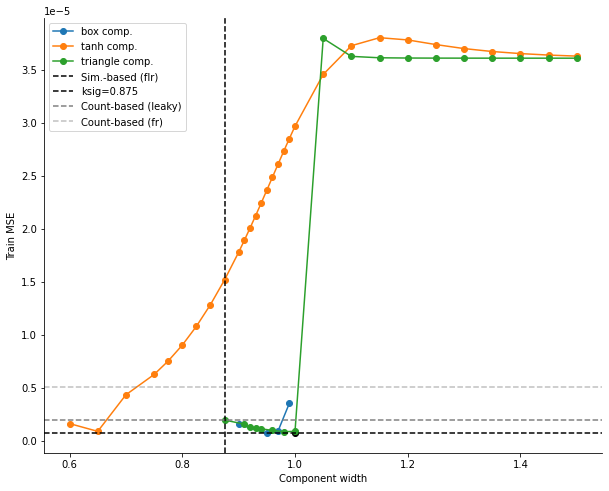

In [26]:
# Plot robustness grid
f, ax = plt.subplots(1, 1, figsize=(10, 8))
for i in range(len(k_types)):
    grid_i = grid.loc[grid['k_type']==k_types[i]]
    ax.plot(grid_i['ksig'], grid_i[measure_fit], marker='o', ls='-', c=color_comps[i], label=f'{k_types[i]} comp.')
ax.axhline(y=best_params[measure_fit], c='k', ls='--', label=label_test_model)
ax.axvline(x=0.875, c='k', ls='--', label='ksig=0.875')
ax.scatter(1,best_params[measure_fit], c='k', marker='o')

alph_compare = 1 if len(compare_params)==1 else np.linspace(0.5, 1, len(compare_params))[::-1]
for i in range(len(compare_params)):
    ax.axhline(y=compare_params[i][measure_fit], c='grey', ls='--', alpha=alph_compare[i], label=label_compare_model[i])
ax.set_xlabel('Component width')
ax.set_ylabel(label_opt_meas)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

In [17]:
grid.loc[(grid['k_type']=='triangle') & (grid['ksig']==0.875)]

,Unnamed: 0.1,Unnamed: 0,ksig,cdens,knum,type_complex,alph_leak,eps,num_complex,grid_id,save_path,grid_id_old,grid_id_old2,k_type,coef,shift,train_rss,train_mse,train_nmse
51,11,3,0.875,32.0,10.0,8,0.1,0.001,2.666667,51,NaN,3,11,triangle,0.005895,0.040815,0.000039,0.000002,0.004465


In [ ]:
for i in range(len(k_types)):
    grid_i = grid.loc[grid['k_type']==k_types[i]]
    print(f'{k_types[i]} components:')
    print(grid_i.ksig.unique())
    

box components:
[0.7  0.75 0.8  0.85 0.9  0.95 0.97 0.99]
tanh components:
[0.5   0.55  0.6   0.65  0.7   0.75  0.775 0.8   0.825 0.85  0.875 0.9
 0.91  0.92  0.93  0.94  0.95  0.96  0.97  0.98  0.99  1.    1.05  1.1
 1.15  1.2   1.25  1.3   1.35  1.4   1.45  1.5  ]
triangle components:
[0.5   0.55  0.6   0.65  0.775 0.825 0.875 0.91  0.92  0.93  0.94  0.96
 0.98  1.    1.05  1.1   1.15  1.2   1.25  1.3   1.35  1.4   1.45  1.5  ]


Current path:/Users/sbecker/Projects/RL_reward_novelty/src/scripts/gabor_kernels/grid_search_new
Current path:/Users/sbecker/Projects/RL_reward_novelty/src/scripts/gabor_kernels/grid_search_new
Current path:/Users/sbecker/Projects/RL_reward_novelty/src/scripts/gabor_kernels/grid_search_new
Current path:/Users/sbecker/Projects/RL_reward_novelty/src/scripts/gabor_kernels/grid_search_new
Current path:/Users/sbecker/Projects/RL_reward_novelty/src/scripts/gabor_kernels/grid_search_new
Current path:/Users/sbecker/Projects/RL_reward_novelty/src/scripts/gabor_kernels/grid_search_new
Current path:/Users/sbecker/Projects/RL_reward_novelty/src/scripts/gabor_kernels/grid_search_new
Current path:/Users/sbecker/Projects/RL_reward_novelty/src/scripts/gabor_kernels/grid_search_new
Current path:/Users/sbecker/Projects/RL_reward_novelty/src/scripts/gabor_kernels/grid_search_new


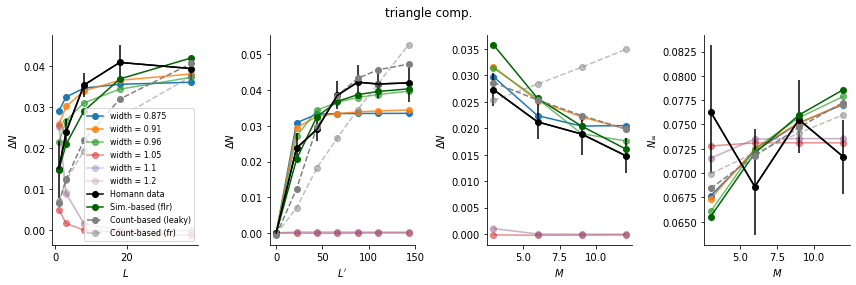

In [18]:
# Plot stats for different widths
ksig_cols = ['C0','C1','C2','C3','C4','C5']
ksig_plot = [0.875, 0.91, 0.96, 1.05, 1.1, 1.2]
ksig_alph = np.linspace(0.2, 1, len(ksig_plot))[::-1]

ylim = [[0,0.05],[0,0.05],[0,0.06],[0.04,0.1]]

# Load Homann data
homann_data = load_homann.load_exp_homann(cluster=False)
homann_lstd = load_homann.load_exp_homann(cluster=False,type='lowerstd')
homann_ustd = load_homann.load_exp_homann(cluster=False,type='upperstd')
# Set novelty response for L'=0 to zero
homann_data[1][1][0] = 0 #homann_data[1][1][0]-delta_homann
homann_lstd[1][1][0] = 0 #homann_lstd[1][1][0]-delta_homann
homann_ustd[1][1][0] = 0 #homann_ustd[1][1][0]-delta_homann

# Load best snov model 
gid_best = int(best_params['grid_id'])
path_best_sim = os.path.join(path_opt,f'{model_name}_set{set_testmodel}_sep/combined_data/grid_{gid_best}/')
pred_best = []
for i_exp, (exp_name, exp_var, exp_out) in enumerate(zip(['l', 'lp', 'm', 'm_steady'],['n_fam', 'dN', 'n_im', 'n_im'],['nt_norm', 'tr_norm', 'nt_norm', 'steady'])):
    pred_best_exp = pd.read_csv(os.path.join(path_best_sim,f'pred_{exp_name}_{weighting}.csv'))
    pred_best.append(pred_best_exp)

# Load control models (cnov_leaky, cnov_fr)
path_control = '/Users/sbecker/Projects/RL_reward_novelty/data/2025_05_grid_search_new/'
pred_ic_all = []
for ic in range(len(compare_model)):
    gid_ic = int(compare_params[ic]['grid_id'])
    path_compare_ic = os.path.join(path_control, f'{compare_model[ic]}/grid_{gid_ic}/')
    pred_ic = []
    for i_exp, (exp_name, exp_var, exp_out) in enumerate(zip(['l', 'lp', 'm', 'm_steady'],['n_fam', 'dN', 'n_im', 'n_im'],['nt_norm', 'tr_norm', 'nt_norm', 'steady'])):
        pred_ic_exp = pd.read_csv(os.path.join(path_compare_ic, f'pred_{exp_name}_{weighting}.csv'))
        pred_ic.append(pred_ic_exp)
    pred_ic_all.append(pred_ic)

for j in range(2,len(k_types)):
    f, ax = plt.subplots(1, 4, figsize=(12, 4))

    # Load + plot simulation data of robustness simulation
    gid_j = []
    for i in range(len(ksig_plot)):
        gid_ij = int(grid.loc[(grid['ksig']==ksig_plot[i]) & (grid['k_type']==k_types[j]),'grid_id'].values[0])
        gid_j.append(gid_ij)


        pred_ij = []
        for i_exp, (exp_name, exp_var, exp_out) in enumerate(zip(['l', 'lp', 'm', 'm_steady'],['n_fam', 'dN', 'n_im', 'n_im'],['nt_norm', 'tr_norm', 'nt_norm', 'steady'])):
            pred_ij_exp = pd.read_csv(os.path.join(path_robustness, f'grid_{gid_ij}/pred_{exp_name}_{weighting}.csv'))
            pred_ij.append(pred_ij_exp)
            ax[i_exp].plot(homann_data[i_exp][0], pred_ij_exp[exp_out], marker='o', ls='-', c=ksig_cols[i], alpha=ksig_alph[i], label=f'width = {ksig_plot[i]}')
        
    # Plot Homann data + best snov model + control modesl
    for i_exp, (exp_name, exp_var, exp_out) in enumerate(zip(['l', 'lp', 'm', 'm_steady'],['n_fam', 'dN', 'n_im', 'n_im'],['nt_norm', 'tr_norm', 'nt_norm', 'steady'])):
        ax[i_exp].plot(homann_data[i_exp][0], homann_data[i_exp][1], 'o-', c='k', label='Homann data')
        ax[i_exp].errorbar(x=homann_data[i_exp][0], y=homann_data[i_exp][1], yerr=[homann_data[i_exp][1]-homann_lstd[i_exp][1],homann_ustd[i_exp][1]-homann_data[i_exp][1]], color='k')

        ax[i_exp].plot(homann_data[i_exp][0], pred_best[i_exp][exp_out], marker='o', ls='-', c='darkgreen', label=label_test_model)

        for ic in range(len(compare_model)):
            ax[i_exp].plot(homann_data[i_exp][0], pred_ic_all[ic][i_exp][exp_out], marker='o', ls='--', c='grey', label=label_compare_model[ic], alpha=alph_compare[ic] if len(compare_model)>1 else 1)
        
        # Set axis limits
        # ax[i_exp].set_ylim(ylim[i_exp])
    
    for i_exp, (xl_exp, yl_exp) in enumerate(zip(['$L$','$L\'$','$M$','$M$'], ['$\\Delta N$','$\\Delta N$','$\\Delta N$','$N_{\\infty}$'])):                    
        ax[i_exp].set_xlabel(xl_exp)
        ax[i_exp].set_ylabel(yl_exp)
        ax[i_exp].spines[['top', 'right']].set_visible(False)

    ax[0].legend(loc='lower right', fontsize=8)
    f.suptitle(f'{k_types[j]} comp.')
    f.tight_layout()

### Robustness (triangle) leaky vs. flr - refitting only linear regression model

In [14]:
# Specify models 
model_names    = ['snov-complex-fr', 'snov-complex-leaky'] # model whose robustness is tested
set_testmodel = [7 if 'fr' in mn else 5 for mn in model_names] # set of the model whose robustness is tested
type_update   = [mn.split('-')[-1] for mn in model_names]
compare_model = ['cnov_leaky', 'cnov_fr'] # model to compare with

# Set plot labels
label_test_model    = ['Sim.-based (flr)','Sim.-based (leaky)']
label_compare_model = ['Count-based (leaky)', 'Count-based (fr)'] # labels for the models to compare with
label_opt_meas      = 'Train MSE' # label for the optimality measure used in the grid search

# Load fitted model parameters
path_opt = '/Volumes/lcncluster/becker/RL_reward_novelty/data/2025_05_grid_search_new/'

measure_fit       = 'train_mse'
sampling_type_fit = 'normal'
drop_type_fit     = 'none' 
weighting_fit     = 'equal-samples' # 'equal-samples', 'equal-exp', 'none' (not available for bootstrap)

file_opt = f'best_params_{measure_fit}_{sampling_type_fit}'
if 'jackknife' in sampling_type_fit or 'loo' in sampling_type_fit:
    file_opt += f'-drop-{drop_type_fit}'
if weighting_fit!='none':
    file_opt += f'-{weighting_fit}'

best_params_fr      = json.load(open(os.path.join(path_opt, f'data_for_figures/{file_opt}-fr.json')))
best_params_leaky   = json.load(open(os.path.join(path_opt, f'data_for_figures/{file_opt}-leaky.json')))
best_params_raw     = best_params_fr + best_params_leaky
best_params         = [[bp for bp in best_params_raw if bp[0]==mn][0][1] for mn in model_names]
compare_params      = [[bp for bp in best_params_raw if bp[0]==compare_model[i]][0][1] for i in range(len(compare_model))]

# For each component shape, load robustness grid
set_names    = [8, 8]
k_types     = ['box','tanh','triangle']
color_comps = ['C0','C1','C2']
sampling_type   = 'normal'
weighting       = 'equal-samples'

pred = []

path_robustness = [f'/Volumes/lcncluster/becker/RL_reward_novelty/data/2025_07_robustness_shape_width/{mn}_set{sn}_sep/combined_data/'
                   for mn, sn in zip(model_names, set_names)]

grid_files = [os.path.join(pr, f'grid_{sampling_type}-{weighting}.csv') for pr in path_robustness]

grid = [pd.read_csv(gf) for gf in grid_files]

for i in range(len(grid)):
    if not 'k_type' in grid[i].columns:
        grid[i]['k_type'] = 'triangle'
    grid[i] = grid[i].sort_values(by=['k_type', 'ksig'])


In [21]:
best_params

[{'k_alph': 0.4,
  'cdens': 8.0,
  'knum': 2.0,
  'train_mse': 7.997003733313102e-07,
  'grid_id': 70.0},
 {'alph_leak': 0.2,
  'eps': 1e-06,
  'cdens': 8.0,
  'knum': 2.0,
  'train_mse': 7.294218269199548e-07,
  'grid_id': 233.0}]

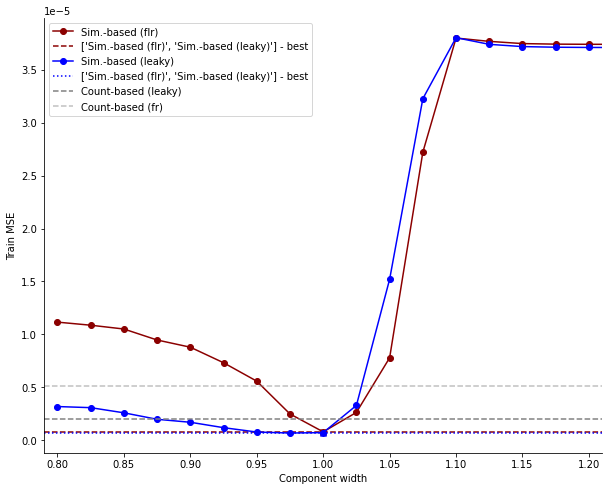

In [20]:
# Plot robustness grid
k_type_plot = 'triangle'
model_cols = ['darkred', 'blue']
models_dash = ['--',':']

f, ax = plt.subplots(1, 1, figsize=(10, 8))
for i in range(len(grid)):
    grid_i = grid[i].loc[grid[i]['k_type']==k_type_plot]
    ax.plot(grid_i['ksig'], grid_i[measure_fit], marker='o', ls='-', c=model_cols[i], label=label_test_model[i])
    ax.axhline(y=best_params[i][measure_fit], c=model_cols[i], ls=models_dash[i], label=f'{label_test_model} - best')
    ax.scatter(1,best_params[i][measure_fit], c=model_cols[i], marker='x')

# ax.axvline(x=0.875, c='k', ls='--', label='ksig=0.875')

alph_compare = 1 if len(compare_params)==1 else np.linspace(0.5, 1, len(compare_params))[::-1]
for i in range(len(compare_params)):
    ax.axhline(y=compare_params[i][measure_fit], c='grey', ls='--', alpha=alph_compare[i], label=label_compare_model[i])
ax.set_xlabel('Component width')
eps_xx= 0.01
ax.set_xlim([0.8-eps_xx,1.2+eps_xx])
ax.set_ylabel(label_opt_meas)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

### Find best flr / leaky model given certain constraints on the number of components

In [ ]:
# Load grids from full grid search (width = 1)
path_opt = '/Volumes/lcncluster/becker/RL_reward_novelty/data/2025_05_grid_search_new/'
path_flr_opt = os.path.join(path_opt,'snov-complex-fr_set7_sep/combined_data/')
path_leaky_opt = os.path.join(path_opt,'snov-complex-leaky_set9_sep/combined_data/')
grid_name = 'grid_normal-equal-samples.csv'

grid_flr = pd.read_csv(os.path.join(path_flr_opt,grid_name))
grid_leaky = pd.read_csv(os.path.join(path_leaky_opt,grid_name))


# Best leaky model with c=32, K=10 [optimal]
grid_leaky1 = grid_leaky.loc[(grid_leaky['cdens']==32) & (grid_leaky['knum']==8.0)]
best_leaky1 = grid_leaky1.loc[grid_leaky1['train_mse']==np.min(grid_leaky1['train_mse'])]

# Best leaky model with c=8, K=2
grid_leaky2 = grid_leaky.loc[(grid_leaky['cdens']==8) & (grid_leaky['knum']==2.0)]
best_leaky2 = grid_leaky2.loc[grid_leaky2['train_mse']==np.min(grid_leaky2['train_mse'])]

# Best flr model with c=32, K=10
grid_flr1 = grid_flr.loc[(grid_flr['cdens']==32) & (grid_flr['knum']==8.0)]
best_flr1 = grid_flr1.loc[grid_flr1['train_mse']==np.min(grid_flr1['train_mse'])]

# Best flr model with c=8, K=2 [optimal]
grid_flr2 = grid_flr.loc[(grid_flr['cdens']==8) & (grid_flr['knum']==2.0)]
best_flr2 = grid_flr2.loc[grid_flr2['train_mse']==np.min(grid_flr2['train_mse'])]


Text(0, 0.5, 'Train MSE')

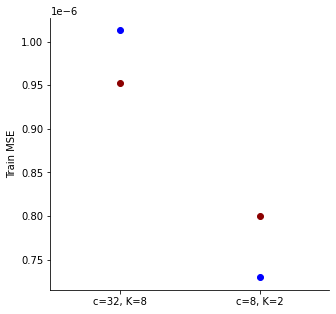

In [ ]:
f,ax = plt.subplots(1,1,figsize=(5,5))
ax.scatter([1,2],[best_flr1['train_mse'],best_flr2['train_mse']],color='darkred')
ax.scatter([1,2],[best_leaky1['train_mse'],best_leaky2['train_mse']],color='blue')
ax.
ax.set_xticks([1,2])
ax.set_xticklabels(['c=32, K=8', 'c=8, K=2'])
ax.set_xlim([0.5,2.5])
ax.spines[['top','right']].set_visible(False)
ax.set_ylabel('Train MSE')

In [ ]:
best_params[0] # flr

{'k_alph': 0.4,
 'cdens': 8.0,
 'knum': 2.0,
 'train_mse': 7.997003733313102e-07,
 'grid_id': 70.0}

In [ ]:
best_params[1] # leaky --> why is best now different? Because the previous 'best solution' only took partial grid into account...

{'alph_leak': 0.2,
 'eps': 1e-06,
 'cdens': 8.0,
 'knum': 2.0,
 'train_mse': 7.294218269199548e-07,
 'grid_id': 233.0}

In [55]:
ksig_flr = grid[0].loc[grid[0]['k_type']=='triangle','ksig'].unique()

In [54]:
ksig_leaky = grid[1].loc[grid[1]['k_type']=='triangle','ksig'].unique()

In [66]:
print(f'Shared ksig: {np.sort(list(set(ksig_flr).intersection(set(ksig_leaky))))}\n')

print(f'Leaky missing: {np.sort(list(set(ksig_flr).difference(set(ksig_leaky))))}\n')

print(f'Flr missing: {np.sort(list(set(ksig_leaky).difference(set(ksig_flr))))}\n')

Shared ksig: [0.775 0.825 0.875 0.91  0.92  0.93  1.05  1.1   1.15  1.2   1.25  1.3
 1.35  1.4   1.45  1.5  ]

Leaky missing: [0.7  0.75 0.8  0.85 0.9  0.95 0.97 0.99]

Flr missing: [0.5  0.55 0.6  0.65 0.94 0.96 0.98 1.  ]



In [67]:
ksig_flr

array([0.7  , 0.75 , 0.775, 0.8  , 0.825, 0.85 , 0.875, 0.9  , 0.91 ,
       0.92 , 0.93 , 0.95 , 0.97 , 0.99 , 1.05 , 1.1  , 1.15 , 1.2  ,
       1.25 , 1.3  , 1.35 , 1.4  , 1.45 , 1.5  ])

### Robustness of train error as cdens / knum vary

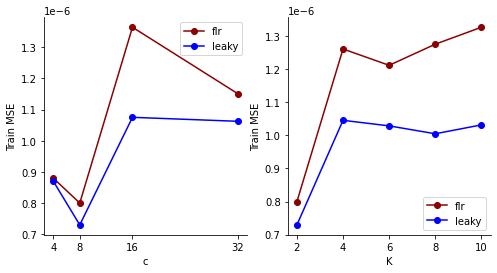

In [74]:
grid_cdens_flr = grid_flr.loc[(grid_flr['knum']==2) & (grid_flr['k_alph']==0.4)]
grid_cdens_leaky = grid_leaky.loc[(grid_leaky['knum']==2) & (grid_leaky['alph_leak']==0.2) & (grid_leaky['eps']==1e-06)]
grid_knum_flr = grid_flr.loc[(grid_flr['cdens']==8) & (grid_flr['k_alph']==0.4)]
grid_knum_leaky = grid_leaky.loc[(grid_leaky['cdens']==8) & (grid_leaky['alph_leak']==0.2) & (grid_leaky['eps']==1e-06)]

f, ax = plt.subplots(1,2,figsize=(8,4))
ax[0].plot(grid_cdens_flr['cdens'],grid_cdens_flr['train_mse'],'o-',color='darkred',label='flr')
ax[0].plot(grid_cdens_leaky['cdens'],grid_cdens_leaky['train_mse'],'o-',color='blue',label='leaky')
ax[0].set_xticks(grid_cdens_flr['cdens'].values)
ax[0].set_xlabel('c')
ax[0].set_ylabel('Train MSE')
ax[0].spines[['top','right']].set_visible(False)
ax[0].legend()

ax[1].plot(grid_knum_flr['knum'],grid_knum_flr['train_mse'],'o-',color='darkred',label='flr')
ax[1].plot(grid_knum_leaky['knum'],grid_knum_leaky['train_mse'],'o-',color='blue',label='leaky')
ax[1].set_xticks(grid_knum_flr['knum'].values)
ax[1].set_xlabel('K')
ax[1].set_ylabel('Train MSE')
ax[1].spines[['top','right']].set_visible(False)
ax[1].legend()


## Robustness with partial refitting of novelty model (only learning rate parameters)

### train errors

In [9]:
# Specify models 
model_names    = ['snov-complex-fr', 'snov-complex-leaky'] # model whose robustness is tested
set_testmodel = [7 if 'fr' in mn else 5 for mn in model_names] # set of the model whose robustness is tested
type_update   = [mn.split('-')[-1] for mn in model_names]
compare_model = ['cnov_leaky', 'cnov_fr'] # model to compare with

# Set plot labels
label_test_model    = ['Sim.-based (flr)','Sim.-based (leaky)']
label_compare_model = ['Count-based (leaky)', 'Count-based (fr)'] # labels for the models to compare with
label_opt_meas      = 'Train MSE' # label for the optimality measure used in the grid search

# Load fitted model parameters
path_opt = '/Volumes/lcncluster/becker/RL_reward_novelty/data/2025_05_grid_search_new/'

measure_fit       = 'train_mse'
sampling_type_fit = 'normal'
drop_type_fit     = 'none' 
weighting_fit     = 'equal-samples' # 'equal-samples', 'equal-exp', 'none' (not available for bootstrap)

file_opt = f'best_params_{measure_fit}_{sampling_type_fit}'
if 'jackknife' in sampling_type_fit or 'loo' in sampling_type_fit:
    file_opt += f'-drop-{drop_type_fit}'
if weighting_fit!='none':
    file_opt += f'-{weighting_fit}'

best_params_fr      = json.load(open(os.path.join(path_opt, f'data_for_figures/{file_opt}-fr.json')))
best_params_leaky   = json.load(open(os.path.join(path_opt, f'data_for_figures/{file_opt}-leaky.json')))
best_params_raw     = best_params_fr + best_params_leaky
best_params         = [[bp for bp in best_params_raw if bp[0]==mn][0][1] for mn in model_names]
compare_params      = [[bp for bp in best_params_raw if bp[0]==compare_model[i]][0][1] for i in range(len(compare_model))]

# For each component shape, load robustness grid (LR refit with partial model refit)
set_names    = [1, 1]
k_types     = ['box','tanh','triangle']
color_comps = ['C0','C1','C2']
sampling_type   = 'normal'
weighting       = 'equal-samples'

pred = []

path_robustness = [f'/Volumes/lcncluster/becker/RL_reward_novelty/data/2025_07_robustness2_width/{mn}_set{sn}_sep/combined_data/'
                   for mn, sn in zip(model_names, set_names)]

grid_files = [os.path.join(pr, f'grid_{sampling_type}-{weighting}.csv') for pr in path_robustness]

grid = [pd.read_csv(gf) for gf in grid_files]

for i in range(len(grid)):
    if not 'k_type' in grid[i].columns:
        grid[i]['k_type'] = 'triangle'
    grid[i] = grid[i].sort_values(by=['k_type', 'ksig'])

# For each component shape, load robustness grid (only LR refit)
set_names2    = [8, 8]
k_types2     = ['box','tanh','triangle']
color_comps2 = ['C0','C1','C2']
sampling_type2  = 'normal'
weighting2       = 'equal-samples'

pred2 = []

path_robustness2 = [f'/Volumes/lcncluster/becker/RL_reward_novelty/data/2025_07_robustness_shape_width/{mn}_set{sn}_sep/combined_data/'
                   for mn, sn in zip(model_names, set_names2)]

grid_files2 = [os.path.join(pr, f'grid_{sampling_type2}-{weighting2}.csv') for pr in path_robustness2]

grid2= [pd.read_csv(gf) for gf in grid_files2]

for i in range(len(grid2)):
    if not 'k_type' in grid2[i].columns:
        grid2[i]['k_type'] = 'triangle'
    grid2[i] = grid2[i].sort_values(by=['k_type', 'ksig'])



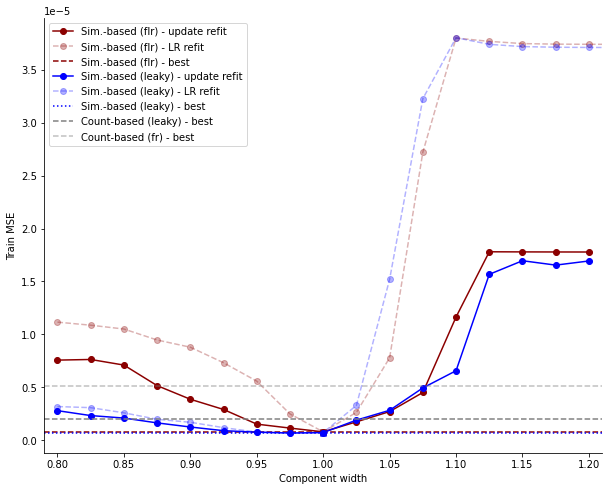

In [ ]:
# Plot robustness grid
k_type_plot = 'triangle'
model_cols = ['darkred', 'blue']
models_dash = ['--',':']

f, ax = plt.subplots(1, 1, figsize=(10, 8))
for i in range(len(grid)):

    best_params[i]['ksig'] = 1.0

    # Get best params for each ksig, for model i (using train MSE after refitting LR)
    grid_i = grid[i].loc[grid[i]['k_type']==k_type_plot]
    grid_i = pd.concat([grid_i, pd.DataFrame(best_params[i], index=[0])], ignore_index=True)
    grid_iagg = grid_i[['ksig','train_mse']].groupby(['ksig']).agg(best_train_mse=pd.NamedAgg(column='train_mse', aggfunc='min')) 
    grid_i = grid_i.merge(grid_iagg, on=['ksig'],how='left')
    grid_ibest = grid_i.loc[grid_i['train_mse']==grid_i['best_train_mse']].reset_index(drop=True)
    grid_ibest = grid_ibest.sort_values(by=['ksig'])
    ax.plot(grid_ibest['ksig'], grid_ibest[measure_fit], marker='o', ls='-', c=model_cols[i], label=f'{label_test_model[i]} - update refit')

    # Get best params for each ksig, for model i (using train MSE after refitting novelty update parameters and LR)
    grid2_i = grid2[i].loc[grid2[i]['k_type']==k_type_plot]
    grid2_i = pd.concat([grid2_i, pd.DataFrame(best_params[i], index=[0])], ignore_index=True)
    grid2_i = grid2_i.sort_values(by=['ksig'])
    ax.plot(grid2_i['ksig'], grid2_i[measure_fit], marker='o', ls='--', c=model_cols[i], label=f'{label_test_model[i]} - LR refit', alpha=0.3)

    ax.axhline(y=best_params[i][measure_fit], c=model_cols[i], ls=models_dash[i], label=f'{label_test_model[i]} - best')
    ax.scatter(1,best_params[i][measure_fit], c=model_cols[i], marker='x')

# ax.axvline(x=0.875, c='k', ls='--', label='ksig=0.875')

alph_compare = 1 if len(compare_params)==1 else np.linspace(0.5, 1, len(compare_params))[::-1]
for i in range(len(compare_params)):
    ax.axhline(y=compare_params[i][measure_fit], c='grey', ls='--', alpha=alph_compare[i], label=f'{label_compare_model[i]} - best')
ax.set_xlabel('Component width')
eps_xx= 0.01
ax.set_xlim([0.8-eps_xx,1.2+eps_xx])
ax.set_ylabel(label_opt_meas)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

### test errors

In [44]:
# Specify models 
model_names    = ['snov-complex-fr', 'snov-complex-leaky'] # model whose robustness is tested
set_testmodel = [7 if 'fr' in mn else 9 for mn in model_names] # set of the model whose robustness is tested
type_update   = [mn.split('-')[-1] for mn in model_names]
compare_model = ['cnov_leaky', 'cnov_fr'] # model to compare with

# Set plot labels
label_test_model    = ['Sim.-based (flr)','Sim.-based (leaky)']
label_compare_model = ['Count-based (leaky)', 'Count-based (fr)'] # labels for the models to compare with
label_opt_meas      = 'Train MSE' # label for the optimality measure used in the grid search

# Load fitted model parameters
path_opt = '/Volumes/lcncluster/becker/RL_reward_novelty/data/2025_05_grid_search_new/'
path_compare = '/Users/sbecker/Projects/RL_reward_novelty/data/2025_05_grid_search_new/'

measure_fit       = 'train_mse'
sampling_type_fit = 'normal'
drop_type_fit     = 'none' 
weighting_fit     = 'equal-samples' # 'equal-samples', 'equal-exp', 'none' (not available for bootstrap)

file_opt = f'best_params_{measure_fit}_{sampling_type_fit}'
if 'jackknife' in sampling_type_fit or 'loo' in sampling_type_fit:
    file_opt += f'-drop-{drop_type_fit}'
if weighting_fit!='none':
    file_opt += f'-{weighting_fit}'

best_params_fr      = json.load(open(os.path.join(path_opt, f'data_for_figures/{file_opt}-fr.json')))
best_params_leaky   = json.load(open(os.path.join(path_opt, f'data_for_figures/{file_opt}-leaky.json')))
best_params_raw     = best_params_fr + best_params_leaky
best_params         = [[bp for bp in best_params_raw if bp[0]==mn][0][1] for mn in model_names]
compare_params      = [[bp for bp in best_params_raw if bp[0]==compare_model[i]][0][1] for i in range(len(compare_model))]

# Load train and test error for best models
best_errors = []
for i_mn, mn in enumerate(model_names):
    errors_mn = pd.read_csv(os.path.join(path_opt, f'{mn}_set{set_testmodel[i_mn]}_sep/combined_data/cv_errors_outerjack-cv-drop-sample-{weighting_fit}.csv'))
    best_errors.append(errors_mn)

compare_errors = []
for i_cm, cm in enumerate(compare_model):
    errors_cm = pd.read_csv(os.path.join(path_compare, f'{cm}/cv_errors_outerjack-cv-drop-sample-{weighting_fit}.csv'))
    compare_errors.append(errors_cm)

# For each component shape, load robustness grid (LR refit with partial model refit)
set_names    = [1, 1]
k_types     = ['box','tanh','triangle']
color_comps = ['C0','C1','C2']
sampling_type   = 'normal'
weighting       = 'equal-samples'

pred = []

path_robustness = [f'/Volumes/lcncluster/becker/RL_reward_novelty/data/2025_07_robustness2_width/{mn}_set{sn}_sep/combined_data/'
                   for mn, sn in zip(model_names, set_names)]

grid_files = [os.path.join(pr, f'grid_{sampling_type}-{weighting}.csv') for pr in path_robustness]

grid = [pd.read_csv(gf) for gf in grid_files]

for i in range(len(grid)):
    if not 'k_type' in grid[i].columns:
        grid[i]['k_type'] = 'triangle'
    grid[i] = grid[i].sort_values(by=['k_type', 'ksig'])

# For each component shape, load robustness grid (only LR refit)
set_names2    = [8, 8]
k_types2     = ['box','tanh','triangle']
color_comps2 = ['C0','C1','C2']
sampling_type2  = 'normal'
weighting2       = 'equal-samples'

pred2 = []

path_robustness2 = [f'/Volumes/lcncluster/becker/RL_reward_novelty/data/2025_07_robustness_shape_width/{mn}_set{sn}_sep/combined_data/'
                   for mn, sn in zip(model_names, set_names2)]

grid_files2 = [os.path.join(pr, f'grid_{sampling_type2}-{weighting2}.csv') for pr in path_robustness2]

grid2= [pd.read_csv(gf) for gf in grid_files2]

for i in range(len(grid2)):
    if not 'k_type' in grid2[i].columns:
        grid2[i]['k_type'] = 'triangle'
    grid2[i] = grid2[i].sort_values(by=['k_type', 'ksig'])



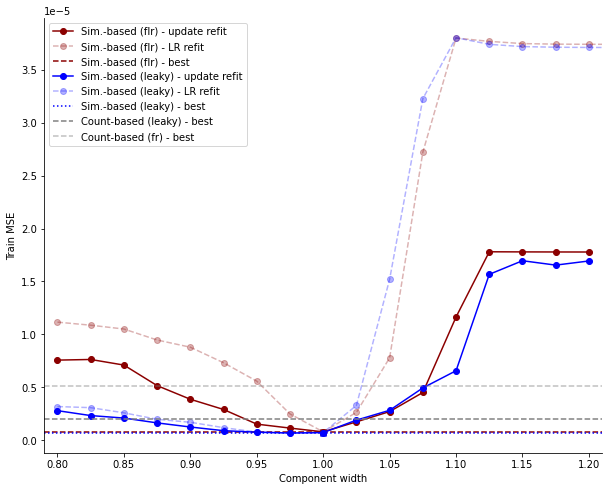

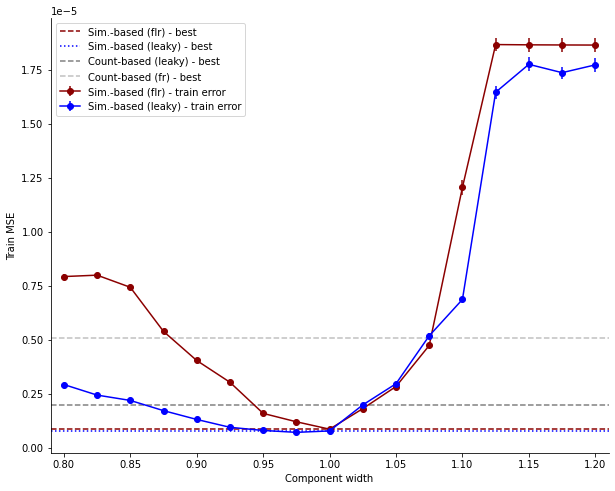

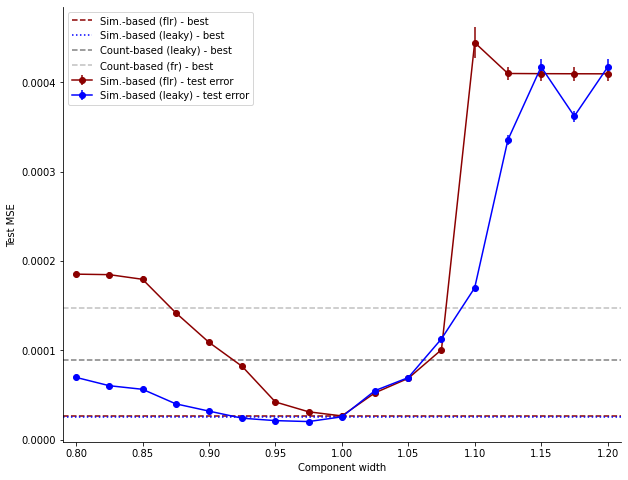

In [45]:
# Plot robustness grid
k_type_plot = 'triangle'
model_cols = ['darkred', 'blue']
models_dash = ['--',':']

f, ax = plt.subplots(1, 1, figsize=(10, 8))
f_train, ax_train = plt.subplots(1, 1, figsize=(10, 8))
f_test, ax_test = plt.subplots(1, 1, figsize=(10, 8))
for i in range(len(grid)):

    best_params[i]['ksig'] = 1.0

    # Get best params for each ksig, for model i (using train MSE after refitting LR)
    grid_i = grid[i].loc[grid[i]['k_type']==k_type_plot]
    grid_i = pd.concat([grid_i, pd.DataFrame(best_params[i], index=[0])], ignore_index=True)
    grid_iagg = grid_i[['ksig',measure_fit]].groupby(['ksig']).agg(best_train_mse=pd.NamedAgg(column=measure_fit, aggfunc='min')) 
    grid_i = grid_i.merge(grid_iagg, on=['ksig'],how='left')
    grid_ibest = grid_i.loc[grid_i[measure_fit]==grid_i['best_train_mse']].reset_index(drop=True)
    grid_ibest = grid_ibest.sort_values(by=['ksig'])

    # Get best params for each ksig, for model i (using train MSE after refitting novelty update parameters andLR)
    grid2_i = grid2[i].loc[grid2[i]['k_type']==k_type_plot]
    grid2_i = pd.concat([grid2_i, pd.DataFrame(best_params[i], index=[0])], ignore_index=True)
    grid2_i = grid2_i.sort_values(by=['ksig'])

    # Plot
    ax.plot(grid_ibest['ksig'], grid_ibest[measure_fit], marker='o', ls='-', c=model_cols[i], label=f'{label_test_model[i]} - update refit')
    ax.plot(grid2_i['ksig'], grid2_i[measure_fit], marker='o', ls='--', c=model_cols[i], label=f'{label_test_model[i]} - LR refit', alpha=0.3)
    ax.axhline(y=best_params[i][measure_fit], c=model_cols[i], ls=models_dash[i], label=f'{label_test_model[i]} - best')
    ax.scatter(1,best_params[i][measure_fit], c=model_cols[i], marker='x')
    
    # Load + plot train and test errors (with errorsbars) for best params for each ksig, for model i
    train_mean_i = []
    test_mean_i  = []
    train_se_i   = []
    test_se_i    = []
    for j, ksig_j in enumerate(grid_ibest['ksig'].values):
        if ksig_j==1.0:
            train_mean_i.append(best_errors[i]['train_error'].values[0])
            train_se_i.append(best_errors[i]['train_error_se'].values[0])
            test_mean_i.append(best_errors[i]['test_error'].values[0])
            test_se_i.append(best_errors[i]['test_error_se'].values[0])

        else:
            grid_train_ij = pd.read_csv(os.path.join(path_robustness[i], f'grid_{int(grid_ibest.loc[grid_ibest.ksig==ksig_j,"grid_id"].values[0])}/train_metrics_{weighting}__jackknife-loo_drop-sample.csv'))
            train_mean_ij = grid_train_ij['train_mse'].mean()
            train_std_ij  = grid_train_ij['train_mse'].std()
            train_se_ij   = train_std_ij / np.sqrt(len(grid_train_ij))
            train_mean_i.append(train_mean_ij)
            train_se_i.append(train_se_ij)

            grid_test_ij = pd.read_csv(os.path.join(path_robustness[i], f'grid_{int(grid_ibest.loc[grid_ibest.ksig==ksig_j,"grid_id"].values[0])}/test_metrics_{weighting}__outerjack-cv_drop-sample.csv'))
            grid_test_mean_ij = grid_test_ij.groupby('outer_resampling_id').agg(test_mse_mean=pd.NamedAgg(column='test_mse', aggfunc='mean'))
            test_mean_ij = grid_test_mean_ij['test_mse_mean'].mean()
            test_std_ij  = grid_test_mean_ij['test_mse_mean'].std()
            test_se_ij   = test_std_ij / np.sqrt(len(grid_test_mean_ij))
            test_mean_i.append(test_mean_ij)
            test_se_i.append(test_se_ij)

    ax_train.errorbar(grid_ibest['ksig'].values, train_mean_i, yerr=train_se_i, fmt='o-', color=model_cols[i], label=f'{label_test_model[i]} - train error')    
    ax_train.axhline(y=best_errors[i]['train_error'].values[0], c=model_cols[i], ls=models_dash[i], label=f'{label_test_model[i]} - best')
    # ax_train.errorbar(1,best_errors[i]['train_error'].values[0], yerr=best_errors[i]['train_error_se'].values[0], c=model_cols[i], marker='x')

    ax_test.errorbar(grid_ibest['ksig'].values, test_mean_i, yerr=test_se_i, fmt='o-', color=model_cols[i], label=f'{label_test_model[i]} - test error')
    ax_test.axhline(y=best_errors[i]['test_error'].values[0], c=model_cols[i], ls=models_dash[i], label=f'{label_test_model[i]} - best')
    # ax_test.errorbar(1,best_errors[i]['test_error'].values[0], yerr=best_errors[i]['test_error_se'].values[0], c=model_cols[i], marker='x')

alph_compare = 1 if len(compare_params)==1 else np.linspace(0.5, 1, len(compare_params))[::-1]
for axi, yi in zip([ax_train, ax_test, ax],['Train MSE', 'Test MSE', 'Train MSE']):
    if yi=='Test MSE':
        for i in range(len(compare_params)):
            axi.axhline(y=compare_errors[i]['test_error'].values[0], c='grey', ls='--', alpha=alph_compare[i], label=f'{label_compare_model[i]} - best')
    else:
        for i in range(len(compare_params)):
            axi.axhline(y=compare_params[i][measure_fit], c='grey', ls='--', alpha=alph_compare[i], label=f'{label_compare_model[i]} - best')
    axi.set_xlabel('Component width')
    eps_xx= 0.01
    axi.set_xlim([0.8-eps_xx,1.2+eps_xx])
    axi.set_ylabel(yi)
    axi.legend()
    axi.spines[['top', 'right']].set_visible(False)

# Code for Figure S3 F

In [34]:
plt.style.use('/Users/sbecker/Projects/RL_reward_novelty/src/scripts/Figures_Paper/paper.mplstyle')
path_save = os.path.join(sl.get_datapath().replace('data','output'),f'Figures_Paper_Revised/Fig_neural_pred/')
sl.make_long_dir(path_save)

## Panel 1: Visualize width variation (plot components)

/var/folders/wv/411_cg655539_0t6mhrytx1w0000gp/T/ipykernel_18724/554221557.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_p = plt.cm.get_cmap('Reds')


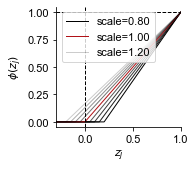

In [24]:
x = np.linspace(-1,1,1000)

loc = 1

scale1 = [0.8, 0.85, 0.9, 0.95]
scale2 = [1.05, 1.1, 1.15, 1.2]
scale = scale1 + [1.0] + scale2

vmax   = 4 + 2
cnorm  = colors.Normalize(vmin=0, vmax=vmax)
cmap_p = plt.cm.get_cmap('Reds')
smap_p = cm.ScalarMappable(norm=cnorm, cmap=cmap_p)
myred  = smap_p.to_rgba(vmax-1)
cols   = ['k']*len(scale1) + [myred] + ['k']*len(scale2)

# alphas1 = list(np.linspace(0.2,1,len(scale1)))
# alphas2 = list(np.linspace(0.2,1,len(scale2)))[::-1]
# alphas  = alphas1 + [1.0] + alphas2
alphas1 = list(np.linspace(0.2,1,len(scale1)+len(scale2)))[::-1]
alphas  = alphas1[:len(scale1)] + [1.0] + alphas1[len(scale1):]

f, ax = plt.subplots(1,1,figsize=(8.3/3,2.5),sharey=True)
for i in range(len(scale)):
    if i==0 or i==len(scale)-1 or cols[i]==myred:
        ax.plot(x,k_triangle3(x,loc,scale[i]),alpha=alphas[i],c=cols[i],label=f'scale={scale[i]:.2f}')
    else:
        ax.plot(x,k_triangle3(x,loc,scale[i]),alpha=alphas[i],c=cols[i])

ax.legend()

ax.axvline(0, color='k', linestyle='--')
ax.axhline(1, color='k', linestyle='--')
ax.set_xlim(-1,1)
ax.set_xlabel('$z_j$')
ax.set_ylabel('$\phi(z_j)$')
ax.set_xlim([-0.3,1])
ax.spines[['top', 'right']].set_visible(False)
f.tight_layout()
f.savefig(os.path.join(path_save,'SI_width_variation_components.svg'))


## Panel 2: Get distribution of similarities present in the data set

### Generate stimuli

In [19]:
def gen_images(num_images, seed=98765):
    # Generate test images
    params_input = {'num_gabor': 40,
                    'adj_w':     True,
                    'adj_f':     False,
                    'alph_adj':  3,
                    'n_fam':     [1,3,8,18,38],
                    'n_im':      [3,6,9,12],
                    'dN':        list(np.array([0,22,44,66,88,110,143])/0.3), # number of recovery images presented, computed based read out from Homann graphs #[0,70,140,210,280,360,480]
                    'idx':       True
                    }

    rng = np.random.default_rng(seed)
    dim_ranges = gs.dim_ranges_rad.copy()

    im_params_all = []
    im_all = []
    for i in range(num_images):
        im_params = gs.generate_stim(dim_ranges,params_input['num_gabor'],rng,alph_adj=params_input['alph_adj'],adj_w=params_input['adj_w'],adj_f=params_input['adj_f'],sampling='basic')
        im,_ = gs.comp_gabor(dim_ranges[4],dim_ranges[5],im_params,resolution=100,magn=1)
        im_params_all.append(im_params)
        im_all.append(im)

    im_params_all = np.array(im_params_all)
    im_all = np.array(im_all)

    return im_params_all, im_all


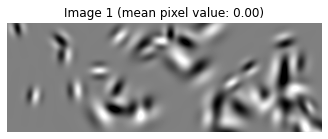

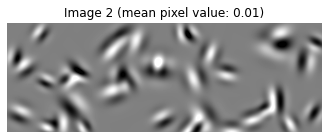

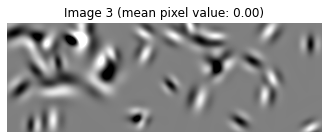

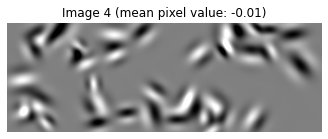

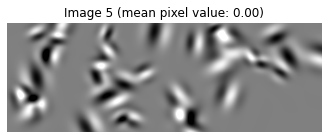

In [20]:
im_params_all, im_all = gen_images(100, seed=98765)

for i in range(min(5,im_all.shape[0])):
    plt.figure(figsize=(2* im_all.shape[2] / im_all.shape[1],2))
    plt.imshow(im_all[i,:,:], cmap='gray', vmin=-1, vmax=1)
    plt.title(f'Image {i+1} (mean pixel value: {np.mean(im_all[i,:,:]):.2f})')
    plt.axis('off')
    plt.show()  # Display each image one by one

In [21]:
# Compute component activation vectors for each model
def make_model(k_params_ext={}, kwargs_ext={}, input_params_ext={}, save_path_i=None):
    k_params = {'knum':             4,
                'type_complex':     8,
                'ratio_complex':    1/3,
                'num_complex':      8/3,
                'k_type':           'triangle',
                'cdens':            4,
                'k_alph':           0.1,
                'alph_leak':        0.1,
                'eps':              1e-6,
                'ksig':             1,
                'kcenter':          1,
                'conv':             True,
                'gabor_seed':       12345,
                'gabor_sampling':   'equidist_fixed'
                }
    
    kwargs = {'no_simple_cells':    False,
                'no_complex_cells': False,
                'mode_complex':     'sum', # 'sum' or 'mean'
                'debug':            False,
                'append_mode':      False,
                'start_id':         0,
                'savepath_sim_data': save_path_i,
                'savename_sim_data': 'sim_data_all',
                'record':           'all'
                }

    if 'type_complex' in k_params:
        kwargs['type_complex'] = [k_params['type_complex']]

    input_params = {'adj_w': True,
                    'adj_f': False,
                    'alph_adj': 3}

    # Update parameters
    k_params.update(k_params_ext)
    kwargs.update(kwargs_ext)
    input_params.update(input_params_ext)

    # Initialize Gabor kernel novelty model 
    k_params_components = gknovc.init_gabor_knov(gnum_complex=k_params['knum'],       # complex cells: number of different preferred orientations  
                                                    ctype=kwargs['type_complex'],       # complex cells: how many simple cells are pooled
                                                    dfreq=1.5,                           # complex cells: factor between simple cell frequencies (fixed at default)
                                                    cvar='frequency',                    # complex cells: feature of simple cells to be varied (fixed at default)
                                                    k_type=k_params['k_type'],           # simple cells: component shape
                                                    ksig=k_params['ksig'],               # simple cells: component width
                                                    kcenter=k_params['kcenter'],         # simple cells: component center (in similarity space)
                                                    seed=k_params['gabor_seed'],         # simple cells: seed for component generation 
                                                    rng=None,
                                                    mask=False,                          # simple cells: Gaussian mask if True (fixed at default False)
                                                    sampling=k_params['gabor_sampling'], # simple cells: sampling of preferred features (e.g. equidistant, random, ...)
                                                    adj_w=input_params['adj_w'],
                                                    adj_f=input_params['adj_f'],
                                                    alph_adj=input_params['alph_adj'],
                                                    conv=k_params['conv'],               # simple cells: convolutional simple cells if True
                                                    cdens=k_params['cdens'],             # simple cells: convolutional stride length 
                                                    parallel=False,                      # simple cells: parallel computation of activation matrix if True   
                                                    debug=kwargs['debug'] if 'debug' in kwargs else False
                                                )

    k_params.update(k_params_components)

    return k_params, kwargs

In [22]:
def get_model_activations(k_params, kwargs, stim_unique):

    # Initialize novelty model & extract kmat_seq
    k                   = k_params['k']
    kfun_idx            = k_params['kfun_idx']
    kfun_complex_idx    = k_params['kfun_complex_idx']
    ksig0               = k_params['ksig']
    cdens               = k_params['cdens'] if 'cdens' in k_params.keys() else None
    conv                = True if 'cdens' in k_params.keys() else False

    if conv:
        num_conv = stim_unique[0,::cdens,::cdens].size
        _, _, kmat_seq, _, klen = gknovc.init_nov_conv(k,kfun_idx,kfun_complex_idx,ksig0,num_conv,seq=stim_unique,kwargs=kwargs)
    else:
        _, _, kmat_seq, _, klen = gknovc.init_nov(k,kfun_idx,kfun_complex_idx,ksig0,seq=stim_unique,kwargs=kwargs)

    return kmat_seq, klen


In [23]:
kmat_id_all = []
klen_id_all = []
klim_id_all = []
klim_simple_id_all = []
for i in range(im_all.shape[0]):
    model_id = make_model(k_params_ext={'k_type': 'id', 'ksig':1}, kwargs_ext={}, input_params_ext={}, save_path_i=None)
    kmat_id, klen_id = get_model_activations(model_id[0], model_id[1], im_all[i,:,:][None,:,:])
    klim_id = [np.min(kmat_id), np.max(kmat_id)]
    klim_simple_id = [np.min(kmat_id[:klen_id[0]*klen_id[2]]), np.max(kmat_id[:klen_id[0]*klen_id[2]])]
    kmat_id_all.append(kmat_id)
    klen_id_all.append(klen_id)
    klim_id_all.append(klim_id)
    klim_simple_id_all.append(klim_simple_id)

klim_id_all = np.array(klim_id_all)
klim_simple_id_all = np.array(klim_simple_id_all)

### Plot panel

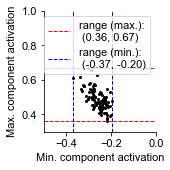

In [35]:
f,ax = plt.subplots(1,1, figsize=(2.5,2.5))
ax.axhline(y=np.min(klim_id_all[:,1]), color='r', linestyle='--', lw=1)
ax.axhline(y=np.max(klim_id_all[:,1]), color='r', linestyle='--', lw=1, label=f'range (max.):\n ({np.min(klim_id_all[:,1]):.2f}, {np.max(klim_id_all[:,1]):.2f})')
ax.axvline(x=np.max(klim_id_all[:,0]), color='b', linestyle='--', lw=1)
ax.axvline(x=np.min(klim_id_all[:,0]), color='b', linestyle='--', lw=1, label=f'range (min.):\n ({np.min(klim_id_all[:,0]):.2f}, {np.max(klim_id_all[:,0]):.2f})')

# ax.axhline(y=np.mean(klim_id_all[:,1]), color='r', linestyle=':', lw=1.5, label=f'mean(max act) = {np.mean(klim_id_all[:,1]):.2f}')
# ax.axvline(x=np.mean(klim_id_all[:,0]), color='b', linestyle=':', lw=1.5, label=f'mean(min act) = {np.mean(klim_id_all[:,0]):.2f}')
ax.scatter(klim_id_all[:,0],klim_id_all[:,1], c='k', s=4)
ax.set_xlabel('Min. component activation')
ax.set_ylabel('Max. component activation')
ax.legend(loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
eps = 0.2
ax.set_xlim([-0.5, 0])
ax.set_ylim([0.3, 1])
# ax.set_xlim([klim_id_all[:,0].min()-eps, klim_id_all[:,0].max()+eps])
# ax.set_ylim([klim_id_all[:,1].min()-eps, klim_id_all[:,1].max()+eps])
f.tight_layout()
f.savefig(os.path.join(path_save,'SI_width_variation_activation-range.svg'))

## Panel 3: Robustness fit

In [48]:
# Specify models 
# model_names    = ['snov-complex-fr'] # model whose robustness is tested
# compare_model  = ['cnov_fr'] # model to compare with

model_names   = ['snov-complex-leaky'] # model whose robustness is tested
compare_model = ['cnov_leaky'] # model to compare with

set_testmodel = [7 if 'fr' in mn else 5 for mn in model_names] # set of the model whose robustness is tested
type_update   = [mn.split('-')[-1] for mn in model_names]
    
# Set plot labels
# label_test_model    = ['Sim.-based (flr)']
# label_compare_model = ['Count-based (fr)'] 
label_test_model    = ['Sim.']
label_compare_model = ['Counts'] # labels for the models to compare with
label_opt_meas      = 'Train MSE' # label for the optimality measure used in the grid search

# Load fitted model parameters
path_opt = '/Volumes/lcncluster/becker/RL_reward_novelty/data/2025_05_grid_search_new/'

measure_fit       = 'train_mse'
sampling_type_fit = 'normal'
drop_type_fit     = 'none' 
weighting_fit     = 'equal-samples' # 'equal-samples', 'equal-exp', 'none' (not available for bootstrap)

file_opt = f'best_params_{measure_fit}_{sampling_type_fit}'
if 'jackknife' in sampling_type_fit or 'loo' in sampling_type_fit:
    file_opt += f'-drop-{drop_type_fit}'
if weighting_fit!='none':
    file_opt += f'-{weighting_fit}'

best_params_fr      = json.load(open(os.path.join(path_opt, f'data_for_figures/{file_opt}-fr.json')))
best_params_leaky   = json.load(open(os.path.join(path_opt, f'data_for_figures/{file_opt}-leaky.json')))
best_params_raw     = best_params_fr + best_params_leaky
best_params         = [[bp for bp in best_params_raw if bp[0]==mn][0][1] for mn in model_names]
compare_params      = [[bp for bp in best_params_raw if bp[0]==compare_model[i]][0][1] for i in range(len(compare_model))]

# For each component shape, load robustness grid (LR refit with partial model refit)
k_types         = ['triangle']
color_comps     = ['C2']
sampling_type   = 'normal'
weighting       = 'equal-samples'
set_names       = [1]

pred = []

path_robustness = [f'/Volumes/lcncluster/becker/RL_reward_novelty/data/2025_07_robustness2_width/{mn}_set{sn}_sep/combined_data/'
                   for mn, sn in zip(model_names, set_names)]

grid_files = [os.path.join(pr, f'grid_{sampling_type}-{weighting}.csv') for pr in path_robustness]

grid = [pd.read_csv(gf) for gf in grid_files]

for i in range(len(grid)):
    if not 'k_type' in grid[i].columns:
        grid[i]['k_type'] = 'triangle'
    grid[i] = grid[i].sort_values(by=['k_type', 'ksig'])

# For each component shape, load robustness grid (only LR refit)
set_names2      = [8]
k_types2        = ['triangle']
color_comps2    = ['C2']
sampling_type2  = 'normal'
weighting2      = 'equal-samples'

pred2 = []

path_robustness2 = [f'/Volumes/lcncluster/becker/RL_reward_novelty/data/2025_07_robustness_shape_width/{mn}_set{sn}_sep/combined_data/'
                   for mn, sn in zip(model_names, set_names2)]

grid_files2 = [os.path.join(pr, f'grid_{sampling_type2}-{weighting2}.csv') for pr in path_robustness2]

grid2= [pd.read_csv(gf) for gf in grid_files2]

for i in range(len(grid2)):
    if not 'k_type' in grid2[i].columns:
        grid2[i]['k_type'] = 'triangle'
    grid2[i] = grid2[i].sort_values(by=['k_type', 'ksig'])

/var/folders/wv/411_cg655539_0t6mhrytx1w0000gp/T/ipykernel_1392/1700650753.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_p = plt.cm.get_cmap('Reds')


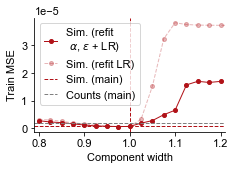

In [81]:
# Plot robustness grid
k_type_plot = 'triangle'
vmax   = 4 + 2
cnorm  = colors.Normalize(vmin=0, vmax=vmax)
cmap_p = plt.cm.get_cmap('Reds')
smap_p = cm.ScalarMappable(norm=cnorm, cmap=cmap_p)
myred  = smap_p.to_rgba(vmax-1)
model_cols = [myred]
models_dash = ['--']

f, ax = plt.subplots(1, 1, figsize=(3.4, 2.5))
for i in range(len(grid)):

    best_params[i]['ksig'] = 1.0

    # Get best params for each ksig, for model i (using train MSE after refitting LR)
    grid_i = grid[i].loc[grid[i]['k_type']==k_type_plot]
    grid_i = pd.concat([grid_i, pd.DataFrame(best_params[i], index=[0])], ignore_index=True)
    grid_iagg = grid_i[['ksig','train_mse']].groupby(['ksig']).agg(best_train_mse=pd.NamedAgg(column='train_mse', aggfunc='min')) 
    grid_i = grid_i.merge(grid_iagg, on=['ksig'],how='left')
    grid_ibest = grid_i.loc[grid_i['train_mse']==grid_i['best_train_mse']].reset_index(drop=True)
    grid_ibest = grid_ibest.sort_values(by=['ksig'])
    ax.plot(grid_ibest['ksig'], grid_ibest[measure_fit], marker='o', markersize=4, ls='-', c=model_cols[i], label=f'{label_test_model[i]} (refit\n $\\alpha$, $\\epsilon$ + LR)')

    # Get best params for each ksig, for model i (using train MSE after refitting novelty update parameters and LR)
    grid2_i = grid2[i].loc[grid2[i]['k_type']==k_type_plot]
    grid2_i = pd.concat([grid2_i, pd.DataFrame(best_params[i], index=[0])], ignore_index=True)
    grid2_i = grid2_i.sort_values(by=['ksig'])
    ax.plot(grid2_i['ksig'], grid2_i[measure_fit], marker='o', markersize=4, ls='--', c=model_cols[i], label=f'{label_test_model[i]} (refit LR)', alpha=0.3)

    ax.axhline(y=best_params[i][measure_fit], c=model_cols[i], ls=models_dash[i], label=f'{label_test_model[i]} (main)')
    # ax.scatter(1,best_params[i][measure_fit], c=model_cols[i], marker='x',s=50)
    ax.axvline(x=1.0, c=model_cols[i], ls='--')

# ax.axvline(x=0.875, c='k', ls='--', label='ksig=0.875')

alph_compare = [1] if len(compare_params)==1 else np.linspace(0.5, 1, len(compare_params))[::-1]
for i in range(len(compare_params)):
    ax.axhline(y=compare_params[i][measure_fit], c='grey', ls='--', alpha=alph_compare[i], label=f'{label_compare_model[i]} (main)')
ax.set_xlabel('Component width')
eps_xx= 0.01
ax.set_xlim([0.8-eps_xx,1.2+eps_xx])
ax.set_ylabel(label_opt_meas)
ax.legend(loc='upper left', handlelength=1.2)
ax.spines[['top', 'right']].set_visible(False)
f.tight_layout()
f.savefig(os.path.join(path_save,'SI_width_variation_fit.svg'))

## Panel 4: Robustness CV (optional)